#
# <center> Retail-Weather Dataset Data Mining Project Phase 2 - Spring 2026
## <center> Created By: Saba Berenji & Sierra Erb

# Business Problem

Retail purchasing behaviour can change over time, making it difficult for retailers to anticipate customer purchasing patterns and make decisions about product availability, promotions, and sales strategies. Weather forecasts are readily available and may provide retailers with additional information that can support these decisions. Therefore, the goal of this analysis is to determine whether different weather conditions are associated with meaningful differences in retail purchasing behaviour. By identifying these relationships, retailers may be able to use weather information as an additional signal when making short-term business decisions.

# Descriptive Summary

Two datasets are used in this project. Dataset 1 is a real online retailer transactions from multiple countries from Dec 2009 - Dec 2011 (https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) with 1,067,371 records and 8 columns. The eight columns include features such as invoice, stock code, description, quantity, invoice date, price, customer, and country. These datasets were cleaned and combined and used in this notebook for further analysis. In this phase, correlation and feature analysis were conducted, as well as clustering by K-Medoids and Agglomerative Hierarchical Clustering to identify purchasing and weather profiles. A decision tree was developed and pruned to predict purchasing quantity levels. Additionally, Naïve Bayes, K-Nearest Neighbour, and AdaBoost classifiers were trained and evaluated using 5-fold cross-validation to predict transaction sales levels from weather and temporal characteristics. Association-rule mining was also conducted to find relationships among products, weather conditions, transaction sales, basket size, and temporal characteristics using support, confidence, and lift to identify interesting rules.  


# Install & Import Required Libraries

In [ ]:
# Installing the required libraries
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn-extra
!pip install networkx
!pip install squarify

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score)
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import fpgrowth
import squarify
import warnings
from matplotlib import MatplotlibDeprecationWarning
import textwrap

In [ ]:
# Load the retail weather dataset into a dataframe
retail_weather_dataset = pd.read_csv("weather_retail_data4.csv")

C:\Users\Saba\AppData\Local\Temp\ipykernel_29372\2275074096.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  retail_weather_dataset = pd.read_csv("weather_retail_data4.csv")


In [ ]:
# Display the shape of the dataset
print("Dataset shape:", retail_weather_dataset.shape)
display(retail_weather_dataset)

Dataset shape: (904182, 33)


,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,...,hour,time_bin,unit_price_bin,avg_min_temp_c_bin,avg_max_temp_c_bin,avg_rain_bin,avg_humidity_bin,avg_cloud_cover_bin,avg_wind_speed_bin,avg_temp_bin
0,1,489434,85048,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.95,83.40,83.40,...,7,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp
1,2,489434,79323P,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.00,81.00,...,7,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp
2,3,489434,79323W,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.00,81.00,...,7,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp
3,4,489434,22041,United Kingdom,2009-12-01,1900-01-01 07:45:00,48,2.10,100.80,100.80,...,7,Morning,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp
4,5,489434,21232,United Kingdom,2009-12-01,1900-01-01 07:45:00,24,1.25,30.00,30.00,...,7,Morning,Low Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904177,1048571,580501,23284,United Kingdom,2011-12-04,1900-01-01 13:00:00,2,8.25,16.50,16.50,...,13,Afternoon,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,Medium Rainfall,Low Humidity,Medium Cloud Cover,Medium Wind Speed,Medium Avg Temp
904178,1048572,580501,22507,United Kingdom,2011-12-04,1900-01-01 13:00:00,3,4.95,14.85,14.85,...,13,Afternoon,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,Medium Rainfall,Low Humidity,Medium Cloud Cover,Medium Wind Speed,Medium Avg Temp
904179,1048573,580502,22469,United Kingdom,2011-12-04,1900-01-01 13:15:00,3,1.65,4.95,4.95,...,13,Afternoon,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,Medium Rainfall,Low Humidity,Medium Cloud Cover,Medium Wind Speed,Medium Avg Temp
904180,1048574,580502,23489,United Kingdom,2011-12-04,1900-01-01 13:15:00,2,2.89,5.78,5.78,...,13,Afternoon,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,Medium Rainfall,Low Humidity,Medium Cloud Cover,Medium Wind Speed,Medium Avg Temp


In [ ]:
# Display the column datatypes and if there are any missing values
print("Dataset information:")
retail_weather_dataset.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904182 entries, 0 to 904181
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   sales_record_id      904182 non-null  int64  
 1   invoice_id           904182 non-null  object 
 2   product_code         904182 non-null  object 
 3   country              904182 non-null  object 
 4   invoice_date         904182 non-null  object 
 5   invoice_time         904182 non-null  object 
 6   quantity             904182 non-null  int64  
 7   unit_price           904182 non-null  float64
 8   total_amount         904182 non-null  float64
 9   line_sales_amount    904182 non-null  float64
 10  product_description  904182 non-null  object 
 11  avg_min_temp_c       904182 non-null  float64
 12  avg_max_temp_c       904182 non-null  float64
 13  avg_rain_mm          904182 non-null  float64
 14  avg_humidity_pct     904182 non-null  float64
 

# Cluster Analysis

## Correlation Analysis

In [ ]:
# List the meaningful numeric features
numeric_features = [
    "quantity",
    "unit_price",
    "total_amount",
    "line_sales_amount",
    "hour",
    "avg_min_temp_c",
    "avg_max_temp_c",
    "avg_rain_mm",
    "avg_humidity_pct",
    "avg_cloud_cover_pct",
    "avg_wind_speed_kmh",
    "locations_reporting",
    "avg_temp_c",
    "temp_range_c"
]

# Select these features from the dataset
correlation_matrix = retail_weather_dataset[numeric_features].corr()

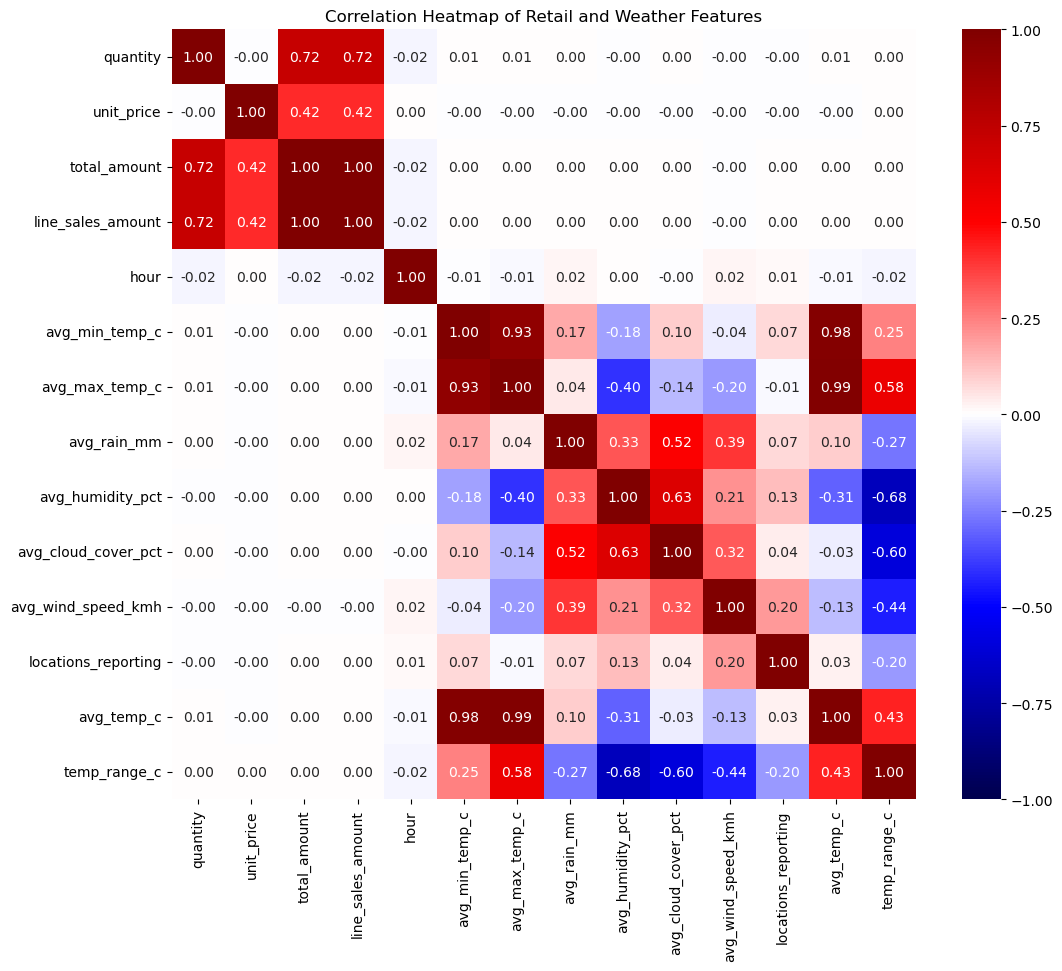

In [ ]:
# Plot headmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='seismic', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Retail and Weather Features')
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The correlation analysis identified several strong relationships among variables, indicating redundancy in the dataset. For example, the total amount and the line sales amount have a perfect correlation of 1.00, indicating that these variables provide the same information and are therefore not both needed for analysis. Average minimum temperature and average maximum temperature are also extremely highly correlated with average temperature, with correlations of 0.98 and 0.99, respectively, while average minimum and maximum temperature are highly correlated with each other at 0.93. Quantity is moderately positively correlated with both line sales amount and total amount at approximately 0.72. Between the weather variables, temperature range has a moderate negative correlation with average humidity (-0.68) and average cloud cover (-0.60). This means that larger temperature ranges tend to occur under less humid and less cloudy conditions. The hour does not show a meaningful correlation with any of the retail or weather variables. Additionally, the retail variables show little to no linear correlation with the weather variables. However, correlation measures linear relationships, so this does not necessarily mean that relationships between weather conditions and purchasing behaviour do not exist.
</div>

## Feature Analysis

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Based on the correlation analysis results, several features were found to be highly correlated with each other and, therefore, are not necessary to include in the cluster analysis to be performed later. However, the correlation value is not the only thing used to select features. Feature meanings and the information they represent will also be used to select features. The sales_record_id, invoice_id, and country will not be included, as they are identifiers or contain the same value. The binned variables will not be used in cluster analysis, as they do not preserve the distances between values and therefore would decrease the effectiveness of cluster detection. Instead of the invoice date and time, the hour will be used for cluster analysis. The product_description, which includes high-cardinality data, will not be used. The quantity and unit_price will be used. Since quantity and line_sales_amount have a strong positive correlation, only quantity will be kept. The total amount will not be used because it is highly correlated with line_sales_amount, which would introduce redundancy. Regarding the weather features, the avg_temp_c, avg_rain_mm, avg_humidity_pct, avg_cloud_cover_pct, avg_wind_speed_kmh, and temp_range_c will be used. The avg_min_temp_c and avg_max_temp_c were highly correlated with each other and with avg_temp_c, and provided very similar information; therefore, they are not necessary. </div>

## Feature Selection

In [ ]:
# Sample the dataset to improve efficiency
cluster_sample = retail_weather_dataset.sample(n=10000, random_state=42)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Since the dataset is very large, with around 904,182 rows, it will be sampled for cluster analysis to improve time and space efficiency. A sample size of 10,000 was selected, as it is approximately 1.1% of the dataset, but still represents a large enough portion of the data to yield meaningful clustering information. A random state of 42 was used to ensure the generated sample is reproducible. </div>

In [ ]:
# Encode the day type
cluster_sample["day_type"] = (cluster_sample["day_type"]
    .map({
        "Weekday": 0,
        "Weekend": 1
    }))

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The day type feature need to be encoded because they are string datatypes. The clustering methods require numerical values for processing. The variables are encoded using mapping as there are minimal categories, and it will make the clustering results easier to understand. </div>

In [ ]:
# Selected Features for Cluster Analysis
cluster_features = [
    "quantity",
    "unit_price",
    "hour",
    "day_type",
    "avg_temp_c",
    "temp_range_c",
    "avg_rain_mm",
    "avg_humidity_pct",
    "avg_cloud_cover_pct",
    "avg_wind_speed_kmh"
]

In [ ]:
X_cluster = cluster_sample[cluster_features]

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The variables identified as important by the feature analysis will be used for the cluster analysis, and are selected to be scaled.  </div>

In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The sampled data was also scaled using the Standard Scaler because the selected features to be clustered have varying units and ranges. This will ensure that variables with large values do not influence the data more than those with small values, so that each feature can contribute equally to the cluster analysis.</div>

In [ ]:
# Perform PCA on the sampled data
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

cluster_sample["PC1"] = X_pca[:, 0]
cluster_sample["PC2"] = X_pca[:, 1]

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Principal Component Analysis will be used to display the generated clusters. This method reduces the 10 selected features to 2 principal components, which capture the greatest variation in the data. </div>

## Agglomerative Hierarchical Clustering

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The first clustering method to be analyzed is Agglomerative Hierarchical clustering. This bottom-up method begins with each data point in its own cluster, and, through iteration, these clusters are merged based on similarity. The ward method is used to join clusters with the goal of minimizing the variance of the merged clusters. </div>

In [ ]:
# Perform hierarchical clustering
linkage_matrix = linkage(X_scaled, method='ward')

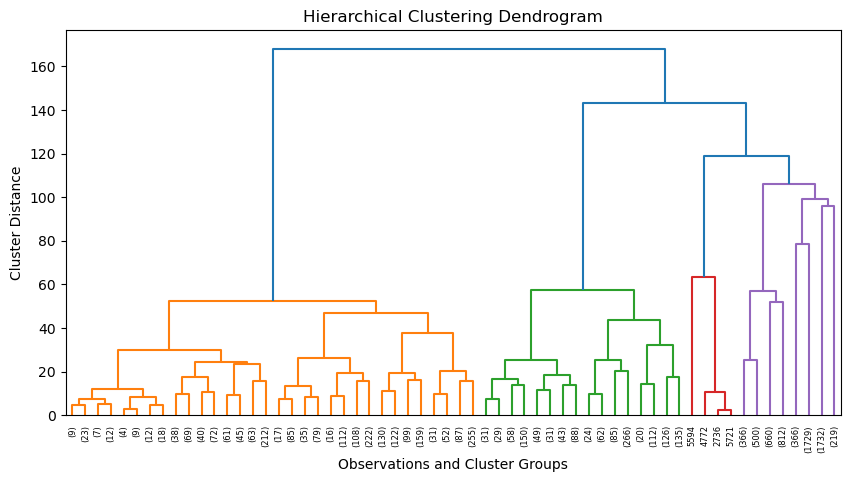

In [ ]:
# Plot dendrogram of hierarchial clusters
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations and Cluster Groups')
plt.ylabel('Cluster Distance')
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Hierarchical Clustering Dendrogram displays the generated hierarchical clusters in orange, green, red and purple. The dendrogram clearly suggests that this approach identifies four major clusters. To inform the choice of the number of clusters, silhouette scores will be calculated.</div>

In [ ]:
# Calculate the silhouette scores for hierarchial clustering
silhouette_scores = []

for k in range(2, 11):
    agg_clustering = AgglomerativeClustering(n_clusters=k, linkage="ward")

    agg_labels = agg_clustering.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,agg_labels)

    silhouette_scores.append(score)

    print(f"k={k}: Silhouette Score={score:.4f}")

k=2: Silhouette Score=0.1511
k=3: Silhouette Score=0.1951
k=4: Silhouette Score=0.1978
k=5: Silhouette Score=0.1563
k=6: Silhouette Score=0.1587
k=7: Silhouette Score=0.1451
k=8: Silhouette Score=0.1524
k=9: Silhouette Score=0.1550
k=10: Silhouette Score=0.1551


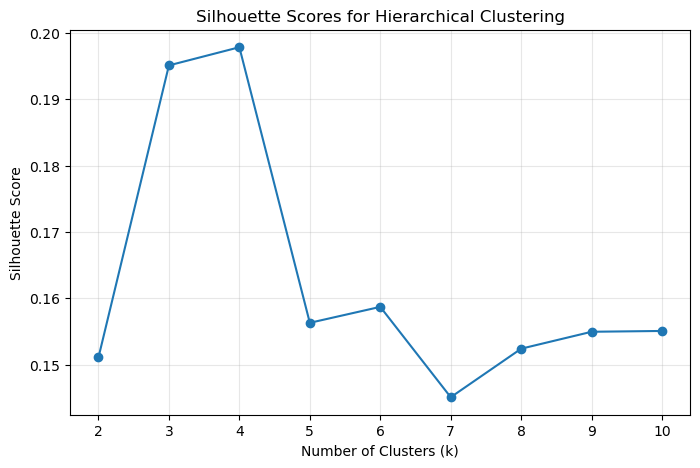

In [ ]:
# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11),silhouette_scores,marker="o")
plt.title("Silhouette Scores for Hierarchical Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After calculating and plotting the silhouette scores for hierarchical clustering with 2-11 clusters, four clusters had the highest silhouette scores, with three as the close second-best. The agglomerative clustering model with four clusters will be evaluated.   </div>

In [ ]:
# Fit Agglomerative Clustering model
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage="ward")

agg_labels = agg_clustering.fit_predict(X_scaled)

cluster_sample["hierarchical_cluster"] = agg_labels

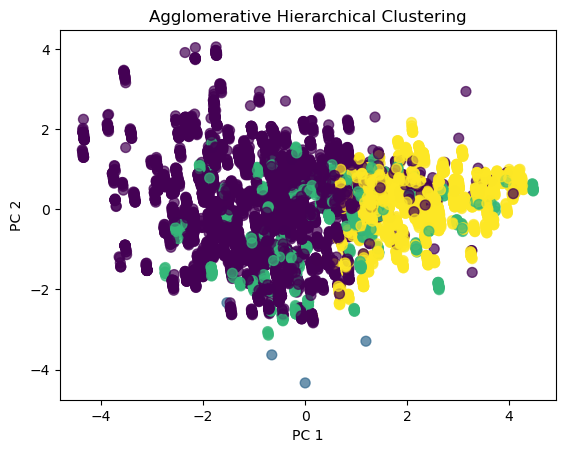

In [ ]:
# Plot the data points colored by their respective clusters
plt.scatter(cluster_sample["PC1"],cluster_sample["PC2"],c=cluster_sample["hierarchical_cluster"],cmap="viridis", s=50, alpha=0.7)
plt.title('Agglomerative Hierarchical Clustering')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the PCA data, the clusters are displayed in the Agglomerative Hierarchical Clustering figure. The purple cluster appears to make up PC 1 points below 0, as well as all the data points above 5 for PC 2. The yellow cluster consists of points above 0 on PC 1 and below 5 on PC 2. </div>

In [ ]:
# Check number of observations in each cluster
cluster_sample["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    6384
1       4
2    1309
3    2303
Name: count, dtype: int64

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After counting the number of data points in each cluster, we can see that cluster 0 contains 6384 data points, cluster 1 has 4 data points, cluster 2 has 1309 data points, and cluster 3 has 2303. Cluster 1 only contains 4 data points compared to the thousands in the other clusters, suggesting that this cluster could potentially represent extreme values. This is why a three cluster solution will be evaluated next.</div>

In [ ]:
# Fit Agglomerative Clustering model
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage="ward")

agg_labels = agg_clustering.fit_predict(X_scaled)

cluster_sample["hierarchical_cluster"] = agg_labels

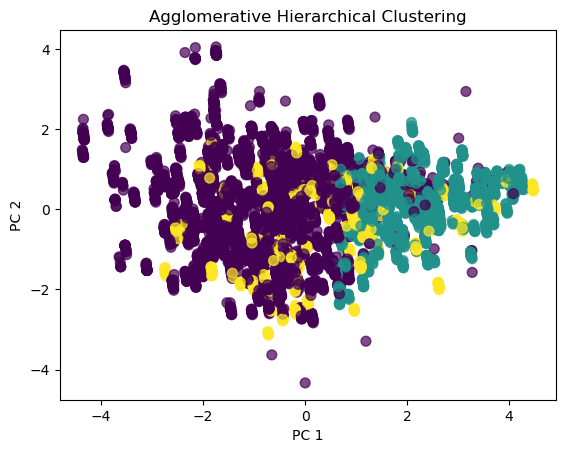

In [ ]:
# Plot the data points colored by their respective clusters
plt.scatter(cluster_sample["PC1"],cluster_sample["PC2"],c=cluster_sample["hierarchical_cluster"],cmap="viridis", s=50, alpha=0.7)
plt.title('Agglomerative Hierarchical Clustering')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the PCA data, the clusters are displayed in the Agglomerative Hierarchical Clustering figure. The purple cluster is the largest and is concentrated mainly on the negative side of PC 1, although it overlaps with the other clusters near the center. The teal cluster is more concentrated on the positive side of PC 1 and appears more tightly grouped than the purple cluster. The yellow cluster is smaller and more scattered across both sides of PC 1 and PC 2, with considerable overlap with the purple and teal clusters. Overall, the figure shows some separation between the purple and teal clusters along PC 1, but the overlap between all three clusters indicates that they are not completely distinct when reduced to two principal components. </div>

In [ ]:
# Check number of observations in each cluster
cluster_sample["hierarchical_cluster"].value_counts().sort_index()

hierarchical_cluster
0    6388
1    2303
2    1309
Name: count, dtype: int64

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The three clusters produce more even samples, with cluster 0 having 6388, cluster 1 having 2303, and cluster 2 having 1309. Although these clusters are not very even, they still represent a meaninful number of observations. </div>

In [ ]:
# Compare average feature values between clusters
hierarchical_profile = (cluster_sample.groupby("hierarchical_cluster")[cluster_features].mean().round(2))

hierarchical_profile

,quantity,unit_price,hour,day_type,avg_temp_c,temp_range_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh
hierarchical_cluster,,,,,,,,,,
0,11.27,4.53,13.31,0.01,8.55,5.10,2.69,88.35,62.16,16.59
1,6.80,3.46,12.82,0.00,11.31,8.24,0.61,80.12,36.36,12.09
2,5.77,2.85,12.96,1.00,9.30,5.93,1.55,85.94,51.90,14.95


In [ ]:
# Display the day_name distribution for each cluster
day_distribution = pd.crosstab(
    cluster_sample["hierarchical_cluster"],
    cluster_sample["day_name"],
    normalize="index"
) * 100

day_distribution.round(1)

day_name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
hierarchical_cluster,,,,,,,
0,15.7,19.2,0.1,0.8,22.9,21.5,19.8
1,15.8,23.1,0.0,0.0,19.5,21.3,20.4
2,0.0,0.0,0.0,100.0,0.0,0.0,0.0


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Based on the differences in the average values for each variable, several insights can be gleaned from the created clusters. First, cluster 0 had the highest results for quantity, unit price, rain, humidity, cloud cover, and wind. Purchases in this cluster also occurred mostly on weekdays. Cluster 1 displays medium quantities and priced purchases that occurred entirely on weekdays, with the warmest temperatures, the largest temperature range, and the lowest amounts of rain, humidity, cloud cover, and wind. The last cluster, cluster 2, has the lowest quantities and unit prices, with purchases occurring entirely on Sunday, due to the low proportion of Saturday purchases. This cluster is associated with moderate weather conditions. The three clusters can be summarized into their main findings. This cluster can be summarized as higher quantities and unit-priced items purchased in wetter, poorer weather conditions. This cluster can be summarized as moderate weekday purchases on warm, dry, clear, and calm weather conditions. This cluster, therefore, represents low-quantity, low-priced weekend purchases that occur in moderate weather.</div>

## K-Medoids clustering

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
K-Medoids Clustering is a medoid-based clustering approach. Clusters are represented by a central value that represents the medoid of all the data points in the cluster. Initial arbitrary points are chosen to represent the cluster. Through iterations, the other data points are assigned to a cluster. Then the cost of swapping the medoid with another random point is evaluated; only if the cost is reduced will the medoid be reassigned. This is repeated until convergence.</div>

In [ ]:
# Calculate the silhouette scores
silhouette_scores = []

for k in range(2, 11):
    kmedoids = KMedoids(n_clusters= k, random_state= 42, method= "alternate")

    labels = kmedoids.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,labels)

    silhouette_scores.append(score)

    print(f"k={k}: Silhouette Score={score:.4f}")

k=2: Silhouette Score=0.1097
k=3: Silhouette Score=0.1567
k=4: Silhouette Score=0.1062
k=5: Silhouette Score=0.1454
k=6: Silhouette Score=0.0994
k=7: Silhouette Score=0.1086


C:\Users\Saba\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 7 is empty! self.labels_[self.medoid_indices_[7]] may not be labeled with its corresponding cluster (7).
  warnings.warn(


k=8: Silhouette Score=0.1110


C:\Users\Saba\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 6 is empty! self.labels_[self.medoid_indices_[6]] may not be labeled with its corresponding cluster (6).
  warnings.warn(


k=9: Silhouette Score=0.1032


C:\Users\Saba\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 6 is empty! self.labels_[self.medoid_indices_[6]] may not be labeled with its corresponding cluster (6).
  warnings.warn(


k=10: Silhouette Score=0.0908


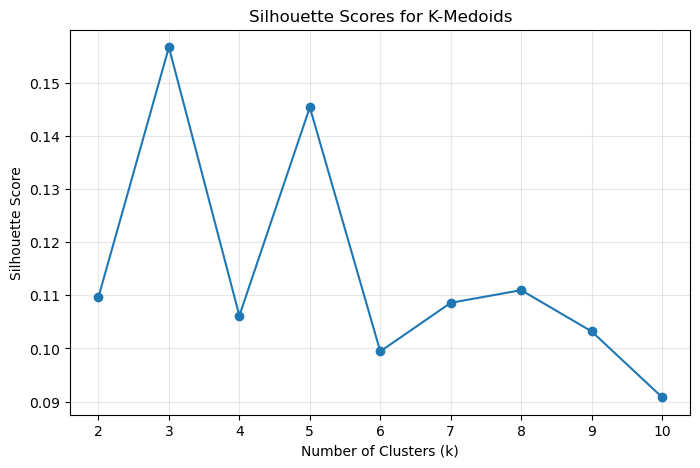

In [ ]:
# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11),silhouette_scores,marker="o")
plt.title("Silhouette Scores for K-Medoids")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Silhouette Scores of K-medoids figure shows that the highest silhouette score was found for three clusters. Five clusters also had high silhouette scores. This means that the silhouette method identified three clusters as the optimal number for this scaled data. </div>

In [ ]:
# Fit final K-Medoid model using the optimal K
kmedoid_final = KMedoids(n_clusters=3,random_state=42,method="alternate")

# Fit and predict using the scaled data
kmedoid_labels = kmedoid_final.fit_predict(X_scaled)

# Add cluster labels to the sampled dataset
cluster_sample["kmedoid_cluster"] = kmedoid_labels

# Display cluster sizes
print("\nClusters found:")
print(cluster_sample["kmedoid_cluster"].value_counts().sort_index())


Clusters found:
kmedoid_cluster
0    2620
1    3803
2    3577
Name: count, dtype: int64


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After fitting and predicting the three k-medoid clusters, it was found that clusters 0, 1, and 2 have 2620, 3803, and 3577 data points, respectively. These clusters have a relatively well-distributed number of data points.</div>

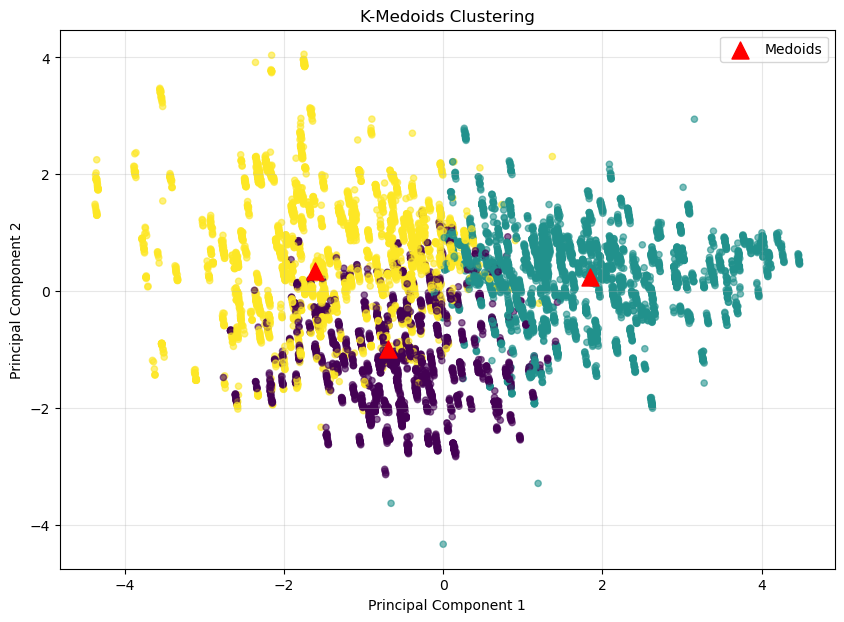

In [ ]:
# Transform K-Medoid medoids into PCA space
medoids_pca = pca.transform(kmedoid_final.cluster_centers_)

# Plot K-Medoids clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0],X_pca[:, 1],c=kmedoid_labels,cmap="viridis",s=20,alpha=0.6)
plt.scatter( medoids_pca[:, 0], medoids_pca[:, 1], marker="^", c="red", s=150, label="Medoids")
plt.title("K-Medoids Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the PCA data, the three clusters are displayed in the K-Medoids Clustering figure, with the red triangles representing the medoids at the centre of each cluster. The teal cluster is concentrated mainly on the positive side of PC 1, while the yellow cluster is concentrated primarily on the negative side of PC 1 and higher values of PC 2. The purple cluster is concentrated around the centre and negative values of PC 2. Although these patterns show some separation between the three clusters, there is considerable overlap near the centre of the figure. This is consistent with the relatively low silhouette score, indicating that the clusters are not strongly separated. However, the differences in the average feature values between the clusters show that K-Medoids was still able to identify different purchasing and weather patterns within the data. </div>

In [ ]:
# Compare average feature values between clusters
kmedoid_profile = (cluster_sample.groupby("kmedoid_cluster")[cluster_features].mean().round(2))

kmedoid_profile

,quantity,unit_price,hour,day_type,avg_temp_c,temp_range_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh
kmedoid_cluster,,,,,,,,,,
0,6.74,3.61,14.13,0.15,4.24,4.74,1.15,88.74,53.71,14.87
1,8.94,4.79,12.93,0.15,12.05,7.88,0.92,81.56,42.30,12.17
2,12.19,3.62,12.67,0.11,10.05,4.73,3.95,89.11,69.09,19.05


In [ ]:
# Display the day_name distribution for each cluster
day_distribution = pd.crosstab(
    cluster_sample["kmedoid_cluster"],
    cluster_sample["day_name"],
    normalize="index"
) * 100

day_distribution.round(1)

day_name,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
kmedoid_cluster,,,,,,,
0,11.9,18.4,0.0,15.3,18.0,19.4,17.0
1,12.9,17.7,0.0,15.1,20.1,18.2,16.0
2,15.8,16.8,0.1,10.8,18.9,18.5,19.0


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Based on the differences in the average values for each variable, several insights can be gleaned from the resulting k-medoids. Cluster 0 has the lowest quantities and the lowest or coldest average temperatures, with other moderate weather conditions, like humidity, rain, cloud, and wind. Cluster 1 has the highest unit price, with moderate quantity, the warmest temperature, and the lowest rain, humidity, cloud and wind. Cluster 2 has the highest quantities and the highest levels of rain, humidity, cloud cover, and wind. To summarize these clusters, cluster 0 represents cold weather and lower-quantity purchases. Cluster 1 represents warmer, drier weather and high-priced purchases. Finally, cluster 2 represents poor weather and higher-quantity purchases. The day-name distribution across all days and clusters is fairly even, meaning that day of week does not distinguish the resulting K-Medoids clusters.</div>

## Clustering Results

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Both clustering methods identified meaningful differences in purchasing behaviour under different weather and temporal conditions. Agglomerative Hierarchical Clustering produced three distinct purchasing profiles. Cluster 0 had the highest average quantity and unit price and was associated with wetter, more humid, cloudier, and windier conditions. Cluster 1 had lower purchasing activity and was associated with the warmest, driest, clearest, and least windy conditions. Cluster 2 had the lowest average quantity and unit price and consisted almost entirely of Sunday transactions. This suggests that both weather conditions and day of the week may be associated with differences in purchasing behaviour. However, because Saturday transactions were extremely underrepresented in the dataset, Cluster 2 is more representative of Sunday purchasing behaviour than weekends in general.
    
K-Medoids produced three different purchasing and weather profiles. Cluster 0 represented the coldest conditions and had the lowest average purchasing quantity. Cluster 1 represented the warmest, driest, clearest, and least windy conditions and had the highest average unit price. Cluster 2 had the highest average purchasing quantity and was associated with the rainiest, most humid, cloudiest, and windiest conditions. Unlike the hierarchical clustering results, the days of the week were relatively evenly distributed across the three K-Medoids clusters, with no individual day strongly dominating a cluster. This suggests that the K-Medoids clusters were distinguished more strongly by weather and purchasing characteristics than by day of the week.

Overall, K-Medoids provided the more useful clustering result for knowledge discovery because it revealed three interpretable purchasing and weather patterns without strongly separating transactions based on a particular day of the week. The results suggest that poorer weather conditions were associated with higher purchasing quantities, while warmer and more favourable conditions were associated with purchases of higher-priced products. However, the relatively low silhouette score indicates that the clusters have considerable overlap and are not strongly separated. Therefore, weather appears to be associated with purchasing behaviour, but it does not fully explain the differences between transactions, suggesting that other factors such as product characteristics, pricing, promotions, or customer behaviour may also contribute to purchasing patterns.
</div>

# Decision Tree Analysis

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
A decision tree will be created using the CART algorithm and evaluated for predicting the quantity of items purchased. This will be useful for informing the online store about purchasing patterns associated with weather conditions that lead to low, medium, and high purchase quantities. This will help the store to make informed decisions on inventory planning, product availability, and demand under different weather and time conditions. This decision tree will use weather and time variables to classify quantities as low, medium, or high. </div>

In [ ]:
# Divide the dataset
tree_features = [
    "unit_price",
    "hour",
    "avg_temp_c",
    "temp_range_c",
    "avg_rain_mm",
    "avg_humidity_pct",
    "avg_cloud_cover_pct",
    "avg_wind_speed_kmh"
]

X = retail_weather_dataset[tree_features]

y = retail_weather_dataset["quantity_bin"]

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The decision tree X and y datasets are curated. The tree features to be analyzed are the continuous variables: hour, unit_price, average temp, temp range, average rain, average humidity, average cloud cover, and average wind speed. The y dataset only includes the quantity_bin variable. This will provide the necessary information to inform the online store about the time of day and weather conditions with the highest purchase volume. </div>

In [ ]:
# Divide the data into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# Divide training data into training and validation sets
X_train, X_validation, y_train, y_validation = train_test_split(X_train_full,y_train_full,test_size=0.20,random_state=42,stratify=y_train_full)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The X and y datasets are divided into training, validation, and test sets, comprising 64%, 16%, and 20% of the data, respectively. These sets will be used to build the decision tree, validate its performance, and ensure it does not overfit.   </div>

In [ ]:
# Train decision trees at each depth and validate accuracy, precision macro,
# recall macro and f1 macro
depth_results = []

for depth in range(1, 41):
    tree = DecisionTreeClassifier(max_depth=depth,random_state=42)

    tree.fit(X_train, y_train)

    training_predictions = tree.predict(X_train)
    validation_predictions = tree.predict(X_validation)

    depth_results.append({
        "max_depth": depth,
        "training_accuracy": accuracy_score(y_train,training_predictions),
        "validation_accuracy": accuracy_score(y_validation,validation_predictions),
        "validation_precision_macro": precision_score( y_validation, validation_predictions, average="macro", zero_division=0),
        "validation_recall_macro": recall_score(y_validation,validation_predictions,average="macro",zero_division=0),
        "validation_f1_macro": f1_score(y_validation, validation_predictions,average="macro",zero_division=0)
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,max_depth,training_accuracy,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro
0,1,0.538419,0.535657,0.359199,0.484945,0.406319
1,2,0.538419,0.535657,0.359199,0.484945,0.406319
2,3,0.538419,0.535657,0.359199,0.484945,0.406319
3,4,0.546216,0.543959,0.361772,0.488049,0.412304
4,5,0.562702,0.562311,0.528471,0.514439,0.486698
5,6,0.565814,0.565069,0.532452,0.519046,0.491746
6,7,0.570450,0.569562,0.535568,0.513271,0.496105
7,8,0.574762,0.572832,0.537316,0.524818,0.497557
8,9,0.580897,0.577947,0.542008,0.527972,0.499342
9,10,0.586788,0.582965,0.552034,0.525863,0.507168


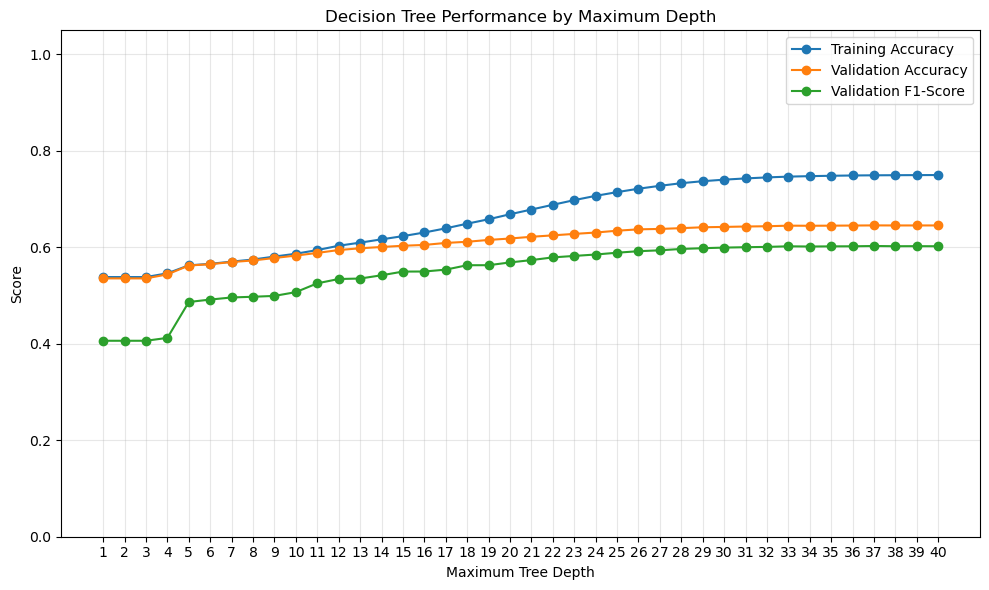

In [ ]:
# Plot the decision tree performance at each depth
plt.figure(figsize=(10, 6))

plt.plot(depth_results_df["max_depth"],depth_results_df["training_accuracy"],marker="o",label="Training Accuracy")
plt.plot(depth_results_df["max_depth"],depth_results_df["validation_accuracy"],marker="o",label="Validation Accuracy")
plt.plot(depth_results_df["max_depth"],depth_results_df["validation_f1_macro"],marker="o",label="Validation F1-Score")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Score")
plt.title("Decision Tree Performance by Maximum Depth")
plt.xticks(range(1, 41))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Print the best desicision tree results
best_row = depth_results_df.loc[depth_results_df["validation_f1_macro"].idxmax()]

best_depth = int(best_row["max_depth"])

print(f"Selected maximum depth: {best_depth}")
print(f"Validation accuracy: {best_row['validation_accuracy']:.4f}")
print(f"Macro precision: {best_row['validation_precision_macro']:.4f}")
print(f"Macro recall: {best_row['validation_recall_macro']:.4f}")
print(f"Macro F1-score: {best_row['validation_f1_macro']:.4f}")

Selected maximum depth: 37
Validation accuracy: 0.6455
Macro precision: 0.6152
Macro recall: 0.6039
Macro F1-score: 0.6028


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After calculating the decision tree accuracy, precision, recall, and F1 score for different max depths from 1 to 40, it was found that a tree with a max depth of 37 had the best F1 score of 0.6028. The final decision tree will be created with this optimal max depth. </div>

In [ ]:
# Create the final tree model
final_tree = DecisionTreeClassifier(max_depth=best_depth,random_state=42)

# Fit the final decision tree
final_tree.fit(X_train_full,y_train_full)

# Test the decision tree on X_test
test_predictions = final_tree.predict(X_test)

                 precision    recall  f1-score   support

 Lower Quantity     0.6720    0.7005    0.6860     54568
Medium Quantity     0.6851    0.7855    0.7319     82193
Higher Quantity     0.5113    0.3448    0.4119     44076

       accuracy                         0.6524    180837
      macro avg     0.6228    0.6103    0.6099    180837
   weighted avg     0.6388    0.6524    0.6400    180837



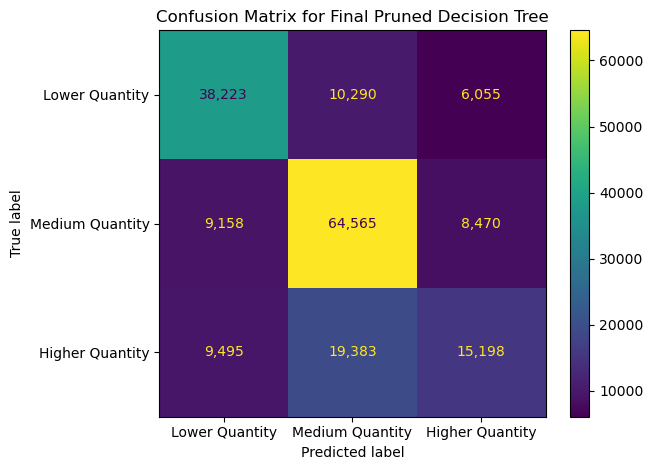

In [ ]:
# Print the results of the classification report
print(classification_report(y_test,test_predictions,target_names=[
        "Lower Quantity",
        "Medium Quantity",
        "Higher Quantity"
        ],digits=4))

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions,display_labels=[
        "Lower Quantity",
        "Medium Quantity",
        "Higher Quantity"
    ], values_format=",")
plt.title("Confusion Matrix for Final Pruned Decision Tree")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The optimal-depth decision tree was found to be a maximum depth of 37 and reached a validation accuracy of 64.55% and a macro F1-score of 60.28%. The final pruned decision tree achieved a similar overall test accuracy of 65.24%, with a macro F1-score of 60.99%. The best model performance occurred when predicting Medium Quantity purchases, achieving an F1-score of 73.19%, followed by Lower Quantity purchases with an F1-score of 68.60%. Higher Quantity purchases were more difficult to predict, with an F1-score of 41.19% and recall of 34.48%. The consistency between the validation and test results indicates that the pruned decision tree generalizes reasonably well to unseen data and does not show clear evidence of overfitting. Overall, the model demonstrates moderate predictive ability, which is reasonable given that purchasing behaviour is likely influenced by additional factors beyond the price, weather, and temporal attributes included in the model. Since plotting the complete decision tree with a maximum depth of 37 would be extremely difficult to interpret, only the first four levels will be displayed.</div>

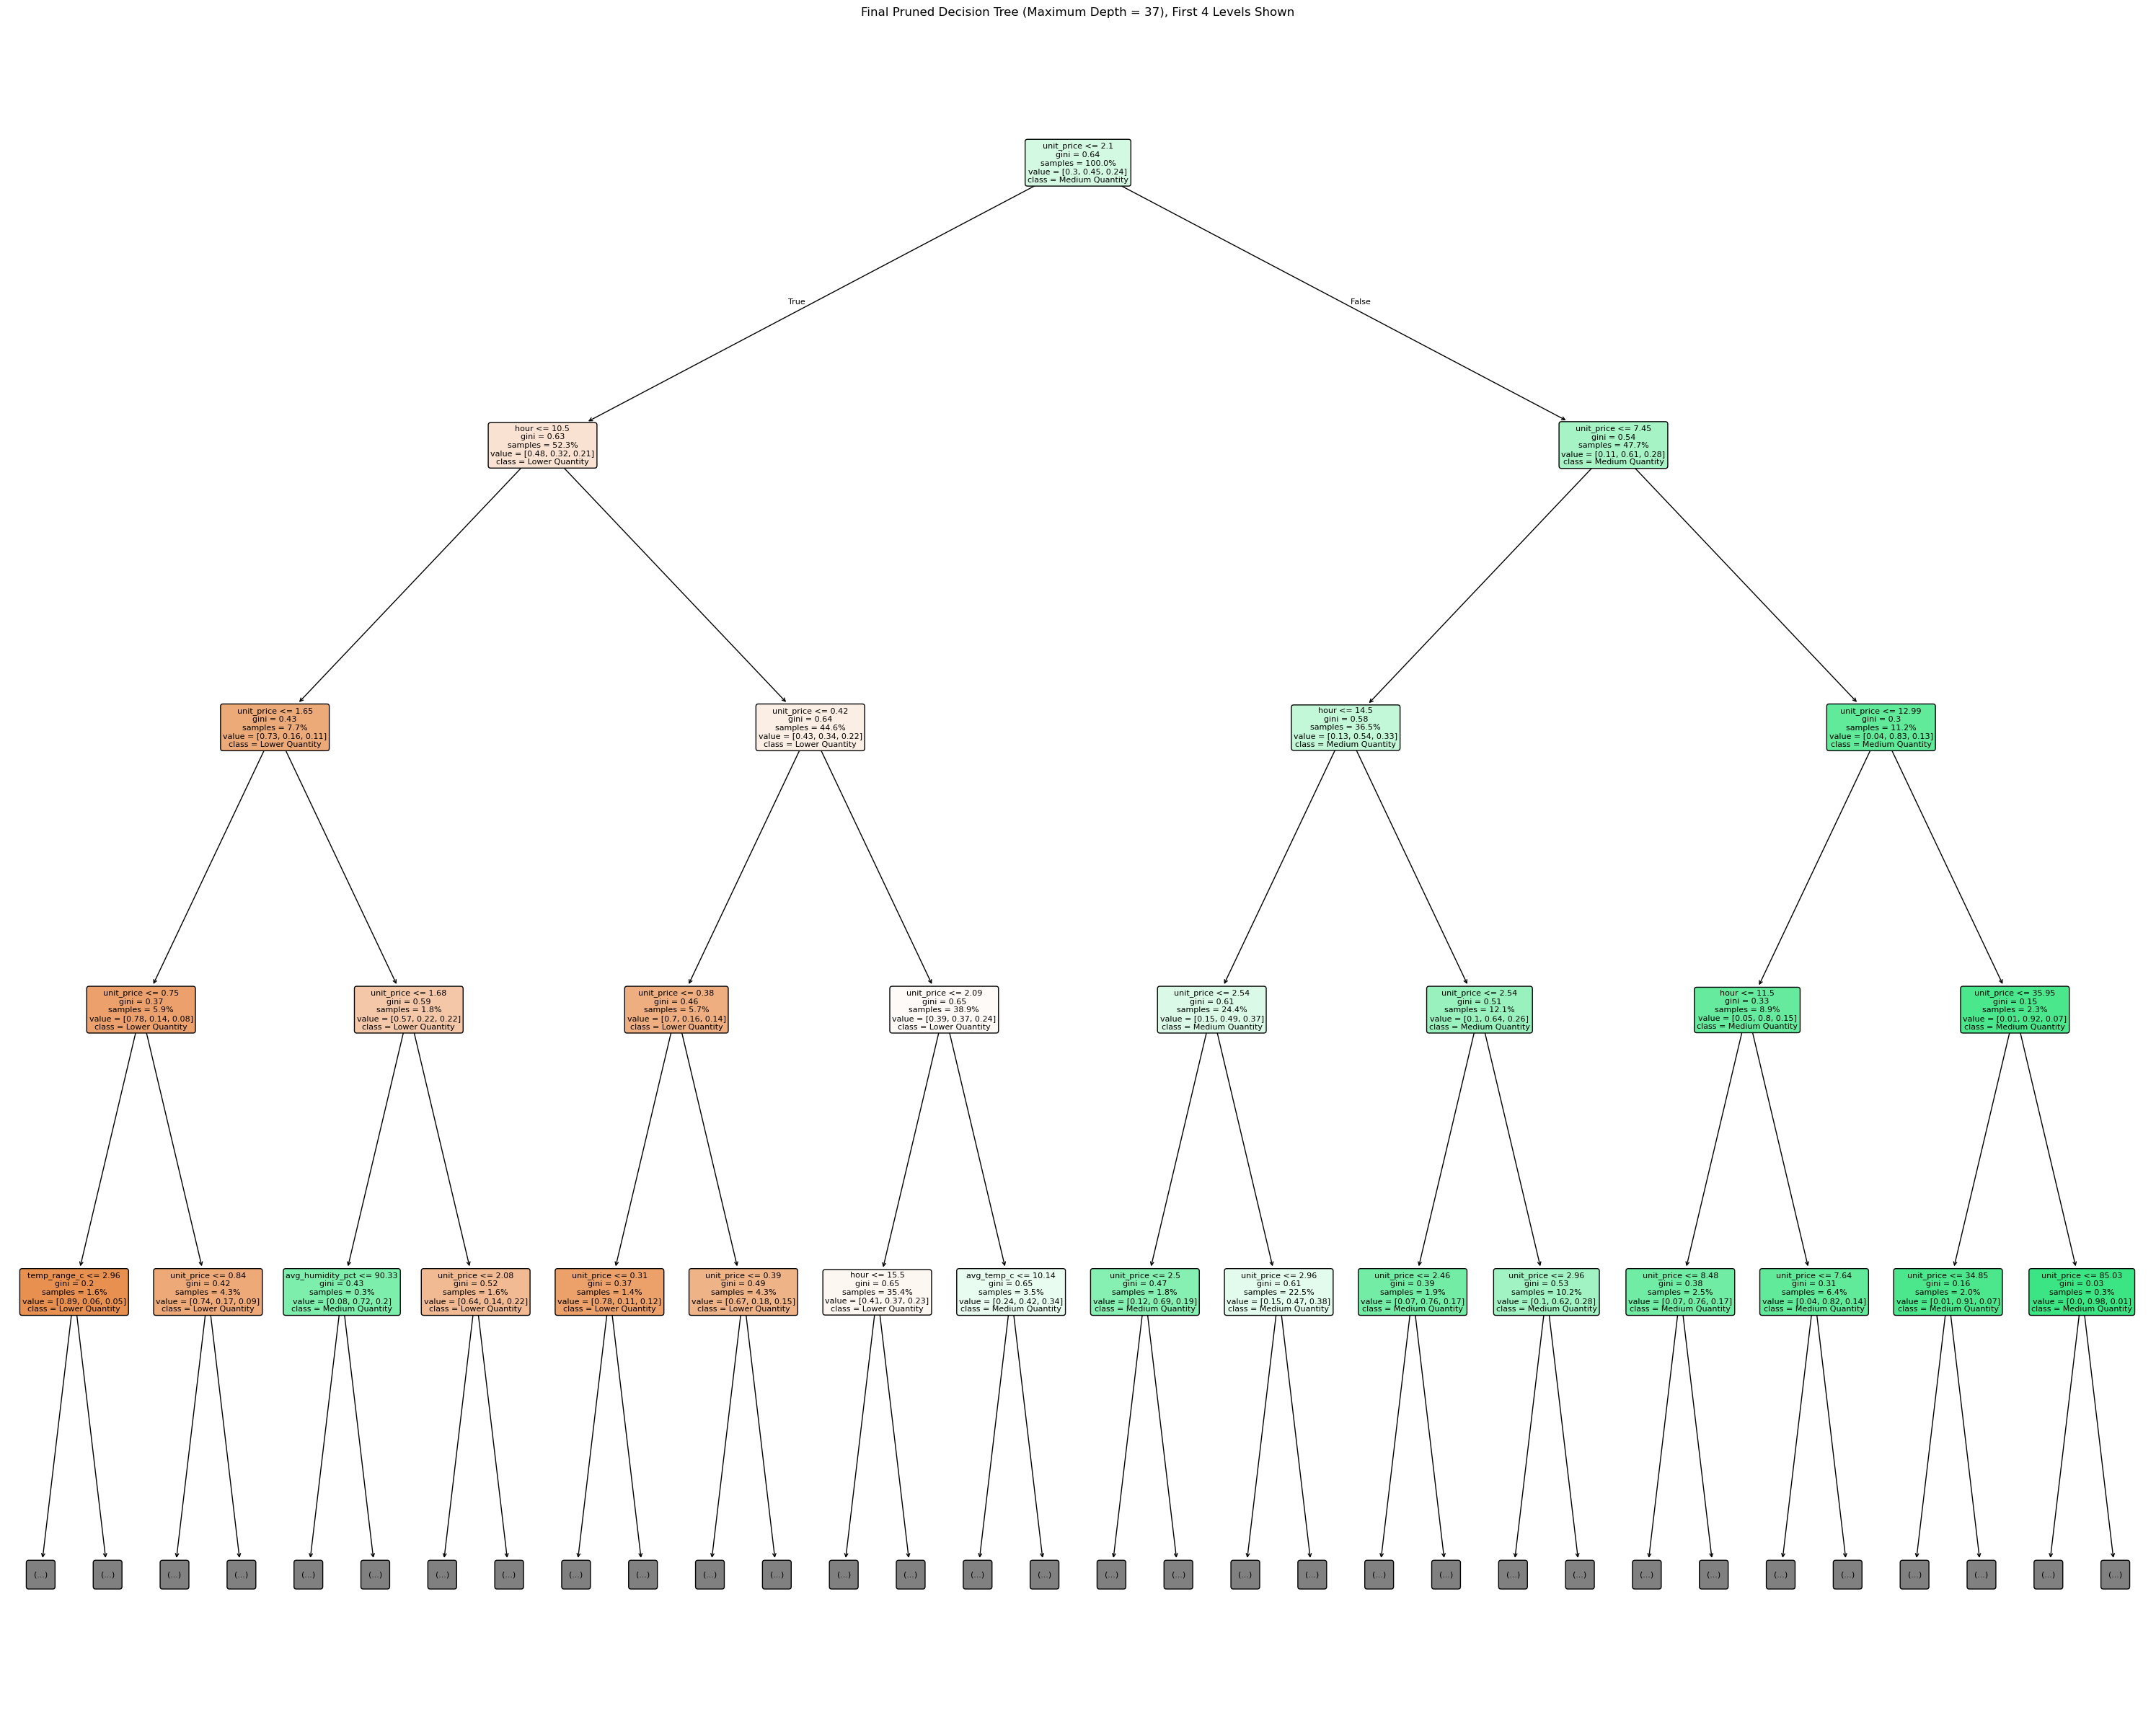

In [ ]:
# Plot the final decision tree
plt.figure(figsize=(30, 24))
plot_tree(final_tree, feature_names=tree_features,
class_names=[
        "Lower Quantity",
        "Medium Quantity",
        "Higher Quantity"
    ], filled=True,rounded=True,proportion=True,precision=2,fontsize=8, max_depth=4)

plt.title(f"Final Pruned Decision Tree (Maximum Depth = {best_depth}), First 4 Levels Shown")
plt.tight_layout()
plt.show()

# Association Rules

##  Show frequency counts for different items

In [ ]:
# Printing the number of unique transactions
print("Number of Records", retail_weather_dataset.shape[0])
print("Number of Unique Transactions:", retail_weather_dataset["invoice_id"].nunique())

Number of Records 904182
Number of Unique Transactions: 36038


In [ ]:
product_frequency = (retail_weather_dataset[["invoice_id", "product_code", "product_description"]]
    .drop_duplicates(subset=["invoice_id", "product_code"]) #counting each product once in each invoicec
    .groupby(["product_code", "product_description"])
    .size()
    .reset_index(name="transaction_frequency")
    .sort_values("transaction_frequency", ascending=False)) #have the highest frequency at the toPp

product_frequency.head()

,product_code,product_description,transaction_frequency
4141,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5119
4119,85099B,JUMBO BAG RED RETROSPOT,3677
1625,22423,REGENCY CAKESTAND 3 TIER,3405
250,20725,LUNCH BAG RED RETROSPOT,2722
607,21212,PACK OF 72 RETROSPOT CAKE CASES,2688


In [ ]:
print("Number of unique products: ", product_frequency.shape[0])

Number of unique products:  4732


In [ ]:
product_frequency.tail(10)

,product_code,product_description,transaction_frequency
2873,35822B,"ACRYLIC BEAD CHAIN, BLUE",1
4180,85157,SET OF 2 CHESTS CHOCOLAT AU LAIT,1
2867,35818C,"ACRYLIC JEWEL ICICLE, CLEAR",1
4191,85164b,BLACK BAROQUE CUCKOO CLOCK,1
2852,35751C,PURPLE CURRENT CANDLE RING,1
4207,85171,S/2 HYACINTH BULB CANDLES,1
2785,30086C,ASSORTED FRUIT STRAWS,1
2780,23692,WRAP A PRETTY THANK YOU,1
2777,23664,FLOWER SHOP DESIGN MUG,1
4731,gift_0001_80,Dotcomgiftshop Gift Voucher Â£80.00,1


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen from 904,182 number of records that we have in this dataset, we have 36,038 invoices/unique transactions.
A table is created to show how many times products have appeared in transactions, in other words the frequency counts for all the different itmes in all transactions. One thing to note though is that each product has been counted once per invoice even if several of them were bought at the same time. This reveals that 'WHITE HANGING HEART T-LIGHT HOLDER' is the most frequent-bought item in the store, appearing 5,119 times in invoices. This was followed by 'JUMBO BAG RED RETROSPOT' and 'REGENCY CAKESTAND 3 TIER', respectively with 3,677 and 3,405 counts. Overall there is 4732 number of unique products and from the second table we can see that most of these products were just bought once.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Even though the Line Sales Amount variable was not discretized during phase 1 data-preparation stage as we concluded that since it was derived from quantity and unit price, it would have provided redundant information that is record-level (for each record and not per invoice); that is why a transaction-level sales category will be added to the dataset specifically for association rule mining. This variable represents the total value of each transaction, while the Line Sales Amount represents the value of one product line. This variable will be categorized into Low, Medium, and High Sales.
</div>

In [ ]:
# Calculate the total sales amount for each transaction
transaction_sales = (retail_weather_dataset.groupby("invoice_id")["line_sales_amount"].sum())

# Map the total sales to the corresponding invoice and add the variable to the dataset
retail_weather_dataset["transaction_sales_amount"] = (retail_weather_dataset["invoice_id"].map(transaction_sales))
retail_weather_dataset.head()

,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,...,time_bin,unit_price_bin,avg_min_temp_c_bin,avg_max_temp_c_bin,avg_rain_bin,avg_humidity_bin,avg_cloud_cover_bin,avg_wind_speed_bin,avg_temp_bin,transaction_sales_amount
0,1,489434,85048,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.95,83.4,83.4,...,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3
1,2,489434,79323P,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3
2,3,489434,79323W,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,Morning,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3
3,4,489434,22041,United Kingdom,2009-12-01,1900-01-01 07:45:00,48,2.10,100.8,100.8,...,Morning,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3
4,5,489434,21232,United Kingdom,2009-12-01,1900-01-01 07:45:00,24,1.25,30.0,30.0,...,Morning,Low Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3


In [ ]:
retail_weather_dataset["transaction_sales_amount"].describe()

count    904182.000000
mean       1137.120750
std        1982.987868
min           0.190000
25%         279.800000
50%         479.100000
75%        1240.490000
max       77183.600000
Name: transaction_sales_amount, dtype: float64

In [ ]:
retail_weather_dataset_skew = retail_weather_dataset["transaction_sales_amount"].skew()
print("Transaction sales amount skewnewss: ", retail_weather_dataset_skew)

Transaction sales amount skewnewss:  9.585296329550719


In [ ]:
# Create one row per transaction with its transaction sales amount

transaction_sales = (retail_weather_dataset[["invoice_id", "transaction_sales_amount"]].drop_duplicates(subset="invoice_id").copy())


# Discretize transaction sales into three equal-frequency categories
transaction_sales["transaction_sales_bin"] = pd.qcut(transaction_sales["transaction_sales_amount"],q=3,
    labels=[
        "Low Transaction Sales",
        "Medium Transaction Sales",
        "High Transaction Sales"])

# Map the correctly calculated sales category back to the original dataset
sales_bin_mapping = transaction_sales.set_index("invoice_id")["transaction_sales_bin"]

retail_weather_dataset["transaction_sales_bin"] = (retail_weather_dataset["invoice_id"].map(sales_bin_mapping))

In [ ]:
# Making sure it was discretized correctly
retail_weather_dataset.head()

,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,...,unit_price_bin,avg_min_temp_c_bin,avg_max_temp_c_bin,avg_rain_bin,avg_humidity_bin,avg_cloud_cover_bin,avg_wind_speed_bin,avg_temp_bin,transaction_sales_amount,transaction_sales_bin
0,1,489434,85048,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.95,83.4,83.4,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
1,2,489434,79323P,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
2,3,489434,79323W,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
3,4,489434,22041,United Kingdom,2009-12-01,1900-01-01 07:45:00,48,2.10,100.8,100.8,...,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
4,5,489434,21232,United Kingdom,2009-12-01,1900-01-01 07:45:00,24,1.25,30.0,30.0,...,Low Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales


In [ ]:
# Show the transaction sales ranges in for the three categories to make sure the distribution was close for each cateogy
retail_weather_dataset[["invoice_id", "transaction_sales_amount", "transaction_sales_bin"]].drop_duplicates("invoice_id").groupby("transaction_sales_bin", observed=True)[
    "transaction_sales_amount"].agg(["min", "max", "count"])

,min,max,count
transaction_sales_bin,,,
Low Transaction Sales,0.19,186.05,12015
Medium Transaction Sales,186.06,376.95,12010
High Transaction Sales,377.00,77183.60,12013


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
For discretizing this variable, equal-frequency binning was used and therefore the resulting categories (low, medium, large) have approximately the same number of transactions with around 12,000 transaction in each group. As can be seen from the distribution of this variable as well as the skewness value (9.58), the distribution is highly right-skewed. That is why equal-frequency binning was used as it created more balanced categories for analysis (as can be seen from the categorical distribution table as well).  
</div>

In [ ]:
# Calculate the total sales amount for each transaction
transaction_sales = (retail_weather_dataset.groupby("invoice_id")["line_sales_amount"].sum())

# Map the total sales to the corresponding invoice and add the variable to the dataset
retail_weather_dataset["transaction_sales_amount"] = (retail_weather_dataset["invoice_id"].map(transaction_sales))
retail_weather_dataset.head()




,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,...,unit_price_bin,avg_min_temp_c_bin,avg_max_temp_c_bin,avg_rain_bin,avg_humidity_bin,avg_cloud_cover_bin,avg_wind_speed_bin,avg_temp_bin,transaction_sales_amount,transaction_sales_bin
0,1,489434,85048,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.95,83.4,83.4,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
1,2,489434,79323P,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
2,3,489434,79323W,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,High Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
3,4,489434,22041,United Kingdom,2009-12-01,1900-01-01 07:45:00,48,2.10,100.8,100.8,...,Medium Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales
4,5,489434,21232,United Kingdom,2009-12-01,1900-01-01 07:45:00,24,1.25,30.0,30.0,...,Low Unit Price,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales


In [ ]:
# Calculate the total basket size for each transaction
transaction_quantity = retail_weather_dataset.groupby("invoice_id")["quantity"].sum()

transaction_quantity.head()

invoice_id
489434    166
489435     60
489436    193
489437    145
489438    826
Name: quantity, dtype: int64

In [ ]:
# Calculate the skewness of transaction basket size

basket_size_skewness = transaction_quantity.skew()

print(f"Basket size skewness: {basket_size_skewness:.4f}")

Basket size skewness: 64.1050


In [ ]:
transaction_quantity.describe()

count    36038.000000
mean       247.996781
std        799.981994
min          1.000000
25%         62.000000
50%        140.000000
75%        273.750000
max      87167.000000
Name: quantity, dtype: float64

In [ ]:
# Creating Low, Medium, and High basket size categories using equal-frequency binning
transaction_quantity_bin = pd.qcut(transaction_quantity,q=3,labels=["Low Basket Size", "Medium Basket Size", "High Basket Size"])

transaction_quantity_bin.value_counts()

quantity
Low Basket Size       12122
High Basket Size      11991
Medium Basket Size    11925
Name: count, dtype: int64

In [ ]:
# Add the transaction-level basket size category back to the original dataframe
retail_weather_dataset["basket_size_bin"] = retail_weather_dataset["invoice_id"].map(transaction_quantity_bin)

In [ ]:
retail_weather_dataset.head()

,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,...,avg_min_temp_c_bin,avg_max_temp_c_bin,avg_rain_bin,avg_humidity_bin,avg_cloud_cover_bin,avg_wind_speed_bin,avg_temp_bin,transaction_sales_amount,transaction_sales_bin,basket_size_bin
0,1,489434,85048,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.95,83.4,83.4,...,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales,Medium Basket Size
1,2,489434,79323P,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales,Medium Basket Size
2,3,489434,79323W,United Kingdom,2009-12-01,1900-01-01 07:45:00,12,6.75,81.0,81.0,...,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales,Medium Basket Size
3,4,489434,22041,United Kingdom,2009-12-01,1900-01-01 07:45:00,48,2.10,100.8,100.8,...,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales,Medium Basket Size
4,5,489434,21232,United Kingdom,2009-12-01,1900-01-01 07:45:00,24,1.25,30.0,30.0,...,Low Average Minimum Temperature,Low Average Maximum Temperature,High Rainfall,Medium Humidity,Medium Cloud Cover,Medium Wind Speed,Low Avg Temp,505.3,High Transaction Sales,Medium Basket Size


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
In order to find association rules for weather -> basket size, the quantity attribute was aggregated and then disreticized using the same equal-frequency binning method since this attribute is also skewed (with a skewness of 64.1050).
</div>

## Convert One-hot encoding

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Before mining for association rules we need to convert the transaction baskets into a one-hot encoded format where each column represents the presence or absense of an item or other transaction features. This format allows the FP-Growth algorithm to identify combinations that frequently occur with the same transaction.
</div>

In [ ]:
# Group by Transaction and collect all features into a single basket
basket_df = retail_weather_dataset.groupby("invoice_id").apply(
    lambda x: list(set(
        ["PRODUCT_" + str(p) for p in x["product_description"].tolist()] +   # added prefixes to make reading the rules easier
        ["TIME_" + str(x["time_bin"].iloc[0])] +
        ["DAY_" + str(x["day_type"].iloc[0])] +
        ["TEMP_" + str(x["avg_temp_bin"].iloc[0])] +
        ["RAIN_" + str(x["avg_rain_bin"].iloc[0])]+
        ["SALES_" + str(x["transaction_sales_bin"].iloc[0])]+
        ["BASKET_" + str(x["basket_size_bin"].iloc[0])]
    )),include_groups=False)

# Convert to list of lists for TransactionEncoder
transactions = basket_df.tolist()

In [ ]:
# Initialize TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert boolean array into a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Transaction Table:\n")
df_encoded.head()

Transaction Table:



,BASKET_High Basket Size,BASKET_Low Basket Size,BASKET_Medium Basket Size,DAY_Weekday,DAY_Weekend,PRODUCT_*Boombox Ipod Classic,PRODUCT_*USB Office Glitter Lamp,PRODUCT_*USB Office Mirror Ball,PRODUCT_10 COLOUR SPACEBOY PEN,PRODUCT_12 ASS ZINC CHRISTMAS DECORATIONS,...,RAIN_Medium Rainfall,SALES_High Transaction Sales,SALES_Low Transaction Sales,SALES_Medium Transaction Sales,TEMP_High Avg Temp,TEMP_Low Avg Temp,TEMP_Medium Avg Temp,TIME_Afternoon,TIME_Evening,TIME_Morning
0,False,False,True,True,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
1,False,True,False,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
2,False,False,True,True,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
3,False,False,True,True,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
4,True,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True


## Find Frequent Itemsets and Raw Rules

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
For minimum threshold, we chose 0.01, which is a suitable value for finding general rules. Since there is a large number of transactions and products in the dataset, FP-Growth was used instead of Apriori for efficiency purposes. Unike Apriori, FP-Growth does not repeatedly generate candidate itemsets which makes it more suitable for large datasets. Both algorithms would identify the same frequent itemsets, but FP-Growth does this more efficiently.
</div>

In [ ]:
# Find frequent itemsets
frequent_itemsets = fpgrowth(df_encoded,min_support=0.01,use_colnames=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")

Frequent itemsets found: 11601


In [ ]:
# Printing the first n itemsets
frequent_itemsets.head(10)

,support,itemsets
0,0.872967,(DAY_Weekday)
1,0.333343,(SALES_High Transaction Sales)
2,0.330901,(BASKET_Medium Basket Size)
3,0.328847,(RAIN_High Rainfall)
4,0.325684,(TIME_Morning)
5,0.144958,(TEMP_Low Avg Temp)
6,0.062268,(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX)
7,0.028498,(PRODUCT_DOORMAT FANCY FONT HOME SWEET HOME)
8,0.019757,(PRODUCT_SAVE THE PLANET MUG)
9,0.017509,(PRODUCT_PINK DOUGHNUT TRINKET POT)


In [ ]:
# Generate Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.10)

print(f"Association rules generated: {len(rules)}")

Association rules generated: 57597


In [ ]:
# Printing the first 5 rules
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(DAY_Weekday),(SALES_High Transaction Sales),0.872967,0.333343,0.295910,0.338970,1.016882,1.0,0.004913,1.008513,0.130690,0.325033,0.008441,0.613338
1,(SALES_High Transaction Sales),(DAY_Weekday),0.333343,0.872967,0.295910,0.887705,1.016882,1.0,0.004913,1.131240,0.024903,0.325033,0.116014,0.613338
2,(SALES_High Transaction Sales),(TIME_Afternoon),0.333343,0.616488,0.200538,0.601598,0.975847,1.0,-0.004963,0.962626,-0.035797,0.267637,-0.038825,0.463445
3,(TIME_Afternoon),(SALES_High Transaction Sales),0.616488,0.333343,0.200538,0.325291,0.975847,1.0,-0.004963,0.988067,-0.060624,0.267637,-0.012077,0.463445
4,(TEMP_Medium Avg Temp),(SALES_High Transaction Sales),0.407986,0.333343,0.135607,0.332381,0.997116,1.0,-0.000392,0.998560,-0.004862,0.223876,-0.001442,0.369595


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Using the minimum support threshold given, the FP-Growth algorithm mined a total of 11,601 frequent itemsets across the dataset.
From these frequent itemsets, 57,597 raw association rules were initially generated using a broad confidence baseline of 10% (min_threshold = 0.10). As can be seen in the frequent itemsets sample, support varios across different trasaction features, with 'DAY_Weekday' appearing in about 87% of transactions and 'PRODUCT_STRAWBERRY CERAMIC TRINKET BOX' APPEARING IN ABOUT 6.2%.
</div>

## Find Rules for Each Category

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Based on our problem statement, we want to understand six types of relationships from our data which is why we will be filtering for these rules from the raw rules we just mined. These six types of relationships are as follows:
    <br>1. Product -> Product
    <br>2. Weather -> Product
    <br>3. Weather -> Transaction Sales
    <br>4. Weather + Time/Day -> Transaction Sales
    <br>5. Weather + Time/Day -> Product
    <br>6. Weather -> Basket Size
</div>

In [ ]:
# Creating three helper functions for this purpose

# Defining a helper function that would check whether every item in an itemset belongs to a category
def all_items_start_with(itemset, prefix):
    return all(str(item).startswith(prefix) for item in itemset)

def is_weather_time_day_rule(itemset):
    items = [str(item) for item in itemset]

    # Every antecedent item must be weather, time, or day
    allowed = all(item.startswith(("TEMP_", "RAIN_", "TIME_", "DAY_"))for item in items)

    # Must contain weather
    has_weather = any(item.startswith(("TEMP_", "RAIN_"))for item in items)

    # Must contain time or day
    has_time_day = any(item.startswith(("TIME_", "DAY_"))for item in items)
    return allowed and has_weather and has_time_day

### Product -> Product rules categories

In [ ]:
# increasing the width of the tables that are going to be displayed so all items are shown fully in each cell as it was being cut.
# this should be done once and then it will work for all tables from this point onward
pd.set_option("display.max_colwidth", None)

In [ ]:
# Only filtering for rules that have 'PRODUCT' in their antecedent and consequent
product_product_rules = rules[rules["antecedents"].apply(
        lambda x: all_items_start_with(x, "PRODUCT_")) &
    rules["consequents"].apply(
        lambda x: all_items_start_with(x, "PRODUCT_"))].copy()

print("Product → Product Rules:", len(product_product_rules))

product_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Product → Product Rules: 1904


,antecedents,consequents,support,confidence,lift
6944,(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX),(PRODUCT_PACK OF 72 RETROSPOT CAKE CASES),0.016705,0.268271,3.596707
6945,(PRODUCT_PACK OF 72 RETROSPOT CAKE CASES),(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX),0.016705,0.223958,3.596707
6948,(PRODUCT_JUMBO BAG RED RETROSPOT),(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX),0.015123,0.148219,2.380349
6949,(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX),(PRODUCT_JUMBO BAG RED RETROSPOT),0.015123,0.242870,2.380349
6950,(PRODUCT_STRAWBERRY CERAMIC TRINKET BOX),(PRODUCT_LUNCH BAG RED RETROSPOT),0.013375,0.214795,2.843785


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, 1,904 rules were identified that showed a product -> product relationship. Sorting these rules by their support, confidence and lift values will help have a better understanding of these rules.
</div>

#### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = product_product_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
50666,(PRODUCT_JUMBO BAG RED RETROSPOT),(PRODUCT_JUMBO BAG PINK POLKADOT),0.037155,0.364156,6.243310
50667,(PRODUCT_JUMBO BAG PINK POLKADOT),(PRODUCT_JUMBO BAG RED RETROSPOT),0.037155,0.637012,6.243310
29308,(PRODUCT_JUMBO BAG RED RETROSPOT),(PRODUCT_JUMBO STORAGE BAG SUKI),0.035074,0.343758,5.623408
29309,(PRODUCT_JUMBO STORAGE BAG SUKI),(PRODUCT_JUMBO BAG RED RETROSPOT),0.035074,0.573763,5.623408
19831,(PRODUCT_RED HANGING HEART T-LIGHT HOLDER),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.032022,0.698547,4.917805
19830,(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),(PRODUCT_RED HANGING HEART T-LIGHT HOLDER),0.032022,0.225435,4.917805
38880,(PRODUCT_JUMBO BAG STRAWBERRY),(PRODUCT_JUMBO BAG RED RETROSPOT),0.031606,0.651229,6.382649
38879,(PRODUCT_JUMBO BAG RED RETROSPOT),(PRODUCT_JUMBO BAG STRAWBERRY),0.031606,0.309763,6.382649
32704,(PRODUCT_LUNCH BAG BLACK SKULL.),(PRODUCT_LUNCH BAG RED RETROSPOT),0.031550,0.511471,6.771635
32705,(PRODUCT_LUNCH BAG RED RETROSPOT),(PRODUCT_LUNCH BAG BLACK SKULL.),0.031550,0.417708,6.771635


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The raw rules were sorted based on the order of their support value. This metric represents how many times transactions had both the antecendent and the consequent appeared together in the dataset. The formula for this metric is: support = (number of transactions containing the itemset) / (Total number of transactions). The highest rule in the table is (PRODUCT_JUMBO BAG RED RETROSPOT) -> (PRODUCT_JUMBO BAG PINK POLKADOT) which has a support value of 0.037 which is generally low and means that they two items don't appear very frequently together.
</div>

#### Sort by Confidence

In [ ]:
# Sorting rules by the highest confidence
confidence_rules = product_product_rules.sort_values(by="confidence",ascending=False)


confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
55982,"(PRODUCT_REGENCY CAKESTAND 3 TIER, PRODUCT_ROSES REGENCY TEACUP AND SAUCER, PRODUCT_PINK REGENCY TEACUP AND SAUCER)",(PRODUCT_GREEN REGENCY TEACUP AND SAUCER),0.010267,0.918114,27.098278
28972,"(PRODUCT_STRAWBERRY CHARLOTTE BAG, PRODUCT_WOODLAND CHARLOTTE BAG, PRODUCT_CHARLOTTE BAG PINK POLKADOT)",(PRODUCT_RED RETROSPOT CHARLOTTE BAG),0.010850,0.907193,18.821765
55612,"(PRODUCT_ROSES REGENCY TEACUP AND SAUCER, PRODUCT_PINK REGENCY TEACUP AND SAUCER)",(PRODUCT_GREEN REGENCY TEACUP AND SAUCER),0.018064,0.904167,26.686616
43316,"(PRODUCT_STRAWBERRY CHARLOTTE BAG, PRODUCT_CHARLOTTE BAG PINK POLKADOT, PRODUCT_CHARLOTTE BAG SUKI DESIGN)",(PRODUCT_RED RETROSPOT CHARLOTTE BAG),0.011654,0.891720,18.500746
55956,"(PRODUCT_REGENCY CAKESTAND 3 TIER, PRODUCT_PINK REGENCY TEACUP AND SAUCER)",(PRODUCT_GREEN REGENCY TEACUP AND SAUCER),0.011821,0.887500,26.194697
55981,"(PRODUCT_REGENCY CAKESTAND 3 TIER, PRODUCT_GREEN REGENCY TEACUP AND SAUCER, PRODUCT_PINK REGENCY TEACUP AND SAUCER)",(PRODUCT_ROSES REGENCY TEACUP AND SAUCER),0.010267,0.868545,24.920868
28835,"(PRODUCT_STRAWBERRY CHARLOTTE BAG, PRODUCT_WOODLAND CHARLOTTE BAG, PRODUCT_CHARLOTTE BAG SUKI DESIGN)",(PRODUCT_RED RETROSPOT CHARLOTTE BAG),0.011127,0.855011,17.739133
27958,"(PRODUCT_WOODLAND CHARLOTTE BAG, PRODUCT_CHARLOTTE BAG PINK POLKADOT, PRODUCT_CHARLOTTE BAG SUKI DESIGN)",(PRODUCT_RED RETROSPOT CHARLOTTE BAG),0.011516,0.852156,17.679908
32266,"(PRODUCT_SET/20 RED RETROSPOT PAPER NAPKINS, PRODUCT_SET/6 RED SPOTTY PAPER CUPS)",(PRODUCT_SET/6 RED SPOTTY PAPER PLATES),0.010322,0.849315,38.307405
43033,"(PRODUCT_STRAWBERRY CHARLOTTE BAG, PRODUCT_CHARLOTTE BAG PINK POLKADOT)",(PRODUCT_RED RETROSPOT CHARLOTTE BAG),0.016011,0.848529,17.604665


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were then sorted based on the order of their confidence value. This metric represents how often the consequent appears when the antecedent appears. The formula for this metric is: Confidence = Support(antecedent -> consequent)/Support (antecedent). The highest rule in this table has a confidence of about 0.92 and represents the following rule: (PRODUCT_REGENCY CAKESTAND 3 TIER, PRODUCT_PINK REGENCY TEACUP AND SAUCER, PRODUCT_ROSES REGENCY TEACUP AND SAUCER)-> (PRODUCT_GREEN REGENCY TEACUP AND SAUCER). This means that about 92% of transactions that have all these three prdocuts in antecedent also contained GREEN REGENCY TEACUP AND SAUCER. The high confidence shows that these products (consequents) is very consistently purchased alongside that particular combination of products (antecedents).
<br>


#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = product_product_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
56821,(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),0.010961,0.651815,48.234323
56820,(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),0.010961,0.811088,48.234323
56818,(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),0.011349,0.634109,46.924031
56819,(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),0.011349,0.839836,46.924031
27411,(PRODUCT_COFFEE MUG CAT + BIRD DESIGN),(PRODUCT_COFFEE MUG DOG + BALL DESIGN),0.010211,0.634483,46.286416
27410,(PRODUCT_COFFEE MUG DOG + BALL DESIGN),(PRODUCT_COFFEE MUG CAT + BIRD DESIGN),0.010211,0.744939,46.286416
56807,(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),0.013292,0.790429,44.163538
56806,(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),0.013292,0.742636,44.163538
32375,(PRODUCT_SET/10 PINK POLKADOT PARTY CANDLES),(PRODUCT_SET/10 BLUE SPOTTY PARTY CANDLES),0.010961,0.588674,41.679018
32374,(PRODUCT_SET/10 BLUE SPOTTY PARTY CANDLES),(PRODUCT_SET/10 PINK POLKADOT PARTY CANDLES),0.010961,0.776031,41.679018


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The rules were sorted based on the order of their lift value, which measures how much more likely the antecedent and consequent are to happen together compared to a random chance. The formula for lift is: Lift = Confidence (anticedent -> consequent) / Support(consequent). The highest rule here is the pattern (PRODUCT_POPPY'S PLAYHOUSE BEDROOM)	-> (PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM), which has a lift of around 48 which is a very high value and shows a much stronger association than expected.

</div>

### Weather -> Product rules categories

In [ ]:
weather_product_rules = rules[rules["antecedents"].apply(lambda x: all(str(item).startswith(("TEMP_", "RAIN_"))for item in x))
    & rules["consequents"].apply(lambda x: all_items_start_with(x, "PRODUCT_"))].copy()

print("Weather → Product Rules:", len(weather_product_rules))

weather_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Weather → Product Rules: 25


,antecedents,consequents,support,confidence,lift
11896,(RAIN_High Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046423,0.141170,0.993840
11900,(TEMP_Low Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024974,0.172282,1.212872
11909,(TEMP_Medium Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.057911,0.141944,0.999291
11912,(RAIN_Medium Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046090,0.136259,0.959271
11914,(RAIN_Low Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.049531,0.148787,1.047469


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, 25 rules were identified that showed a weather -> product relationship. Sorting these rules by their support, confidence and lift values will help have a better understanding of them.
</div>

#### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = weather_product_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
11916,(TEMP_High Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.059160,0.132332,0.931623
11909,(TEMP_Medium Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.057911,0.141944,0.999291
14898,(TEMP_High Avg Temp),(PRODUCT_JUMBO BAG RED RETROSPOT),0.049587,0.110918,1.087099
11914,(RAIN_Low Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.049531,0.148787,1.047469
52399,(TEMP_High Avg Temp),(PRODUCT_REGENCY CAKESTAND 3 TIER),0.048255,0.107939,1.142406
11896,(RAIN_High Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046423,0.141170,0.993840
11912,(RAIN_Medium Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046090,0.136259,0.959271
14880,(RAIN_High Rainfall),(PRODUCT_JUMBO BAG RED RETROSPOT),0.034269,0.104211,1.021360
14894,(RAIN_Medium Rainfall),(PRODUCT_JUMBO BAG RED RETROSPOT),0.033936,0.100328,0.983309
14896,(RAIN_Low Rainfall),(PRODUCT_JUMBO BAG RED RETROSPOT),0.033825,0.101609,0.995860


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in the table is (TEMP_High Avg Temp) -> 	(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER) which has a support value of 0.059 which is not a very high number in general but shows that these two items appear more frequenctly together compared to other itemsets in this category.
</div>

#### Sort by Confidence

In [ ]:
# Sorting rules by the highest confidence
confidence_rules = weather_product_rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
12525,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.010683,0.182205,1.282735
11900,(TEMP_Low Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024974,0.172282,1.212872
11914,(RAIN_Low Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.049531,0.148787,1.047469
13294,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.020229,0.146739,1.033050
12038,"(TEMP_Medium Avg Temp, RAIN_High Rainfall)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.017232,0.146635,1.032319
11909,(TEMP_Medium Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.057911,0.141944,0.999291
11896,(RAIN_High Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046423,0.141170,0.993840
13312,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.018619,0.136493,0.960918
11912,(RAIN_Medium Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.046090,0.136259,0.959271
13061,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.020451,0.134000,0.943366


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in this table has a confidence of 0.18 and represents the following rule:(TEMP_Low Avg Temp, RAIN_Low Rainfall) -> ((PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER) which shows that when the average temp and the rainfall are low, the chance of PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER being bought is higher than other products.
</div>

#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = weather_product_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
12525,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.010683,0.182205,1.282735
11900,(TEMP_Low Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024974,0.172282,1.212872
53319,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.020145,0.112593,1.191668
52526,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.014818,0.108625,1.149669
52399,(TEMP_High Avg Temp),(PRODUCT_REGENCY CAKESTAND 3 TIER),0.048255,0.107939,1.142406
52514,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.014512,0.105274,1.114201
16025,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.015373,0.112693,1.104498
15856,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.014651,0.111228,1.090139
14898,(TEMP_High Avg Temp),(PRODUCT_JUMBO BAG RED RETROSPOT),0.049587,0.110918,1.087099
15014,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.019563,0.109336,1.071596


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule here in the table is (TEMP_Low Avg Temp, RAIN_Low Rainfall) -> (PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER) which has a lift of about 1.28 which means that the product is about 28% more likely than expected to be bought under that weather condition as this is a posisitve association.
</div>

### Weather -> Transaction Sales rules categories

In [ ]:
weather_sales_rules = rules[rules["antecedents"].apply(lambda x: all(str(item).startswith(("TEMP_", "RAIN_"))for item in x))
    & rules["consequents"].apply(lambda x: all_items_start_with(x, "SALES_"))].copy()

print("Weather → Transaction Sales Rules:", len(weather_sales_rules))

weather_sales_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Weather → Transaction Sales Rules: 44


,antecedents,consequents,support,confidence,lift
4,(TEMP_Medium Avg Temp),(SALES_High Transaction Sales),0.135607,0.332381,0.997116
6,(RAIN_Medium Rainfall),(SALES_High Transaction Sales),0.108358,0.320345,0.961007
9,(TEMP_High Avg Temp),(SALES_High Transaction Sales),0.151729,0.339395,1.018158
48,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(SALES_High Transaction Sales),0.049337,0.323273,0.969791
61,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.042511,0.322730,0.968164


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, 44 rules were identified that showed a weather -> transaction sales relationship. Sorting these rules by their support, confidence and lift values will help have a better understanding of them.
</div>

#### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = weather_sales_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
9,(TEMP_High Avg Temp),(SALES_High Transaction Sales),0.151729,0.339395,1.018158
7919,(TEMP_High Avg Temp),(SALES_Low Transaction Sales),0.148288,0.331699,0.994903
9765,(TEMP_High Avg Temp),(SALES_Medium Transaction Sales),0.147039,0.328906,0.986936
9760,(TEMP_Medium Avg Temp),(SALES_Medium Transaction Sales),0.137327,0.336598,1.010018
4,(TEMP_Medium Avg Temp),(SALES_High Transaction Sales),0.135607,0.332381,0.997116
7914,(TEMP_Medium Avg Temp),(SALES_Low Transaction Sales),0.135052,0.331021,0.992870
7917,(RAIN_Medium Rainfall),(SALES_Low Transaction Sales),0.116238,0.343642,1.030727
9763,(RAIN_Medium Rainfall),(SALES_Medium Transaction Sales),0.113658,0.336013,1.008263
45334,(RAIN_Low Rainfall),(SALES_High Transaction Sales),0.113103,0.339752,1.019227
1419,(RAIN_High Rainfall),(SALES_High Transaction Sales),0.111882,0.340224,1.020645


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in the table is (TEMP_High Avg Temp) -> (SALES_High Transaction Sales)	 which has a support value of 	0.15 which is somewhat low and shows that having a high transaction sales when the the average temperature is high is the most common rule among the other rules in this category but generally it's not very common.
</div>

#### Sort by Confidence

In [ ]:
# Sorting rules by the highest confidence
confidence_rules = weather_sales_rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
6281,"(RAIN_High Rainfall, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011904,0.367295,1.101853
6395,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.019646,0.364385,1.092943
6399,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.020950,0.357312,1.071727
45390,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.048282,0.353946,1.061809
5986,(TEMP_Low Avg Temp),(SALES_Low Transaction Sales),0.050058,0.345329,1.035787
8065,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(SALES_Low Transaction Sales),0.045480,0.345271,1.035611
7917,(RAIN_Medium Rainfall),(SALES_Low Transaction Sales),0.116238,0.343642,1.030727
6641,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Medium Transaction Sales),0.020090,0.342641,1.028151
45377,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.047228,0.342593,1.027749
9913,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(SALES_Medium Transaction Sales),0.052167,0.341818,1.025682


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in this table has a confidence of 0.36 and represents the following rule: (TEMP_Low Avg Temp, RAIN_High Rainfall)	 -> (SALES_High Transaction Sales) which shows that when there is high rainfall and low average temp, the chance of the overall sales amount being high, is higher than other combinations in this table.
</div>

#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = weather_sales_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
6281,"(RAIN_High Rainfall, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011904,0.367295,1.101853
6395,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.019646,0.364385,1.092943
6399,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.020950,0.357312,1.071727
45390,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.048282,0.353946,1.061809
5986,(TEMP_Low Avg Temp),(SALES_Low Transaction Sales),0.050058,0.345329,1.035787
8065,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(SALES_Low Transaction Sales),0.045480,0.345271,1.035611
7917,(RAIN_Medium Rainfall),(SALES_Low Transaction Sales),0.116238,0.343642,1.030727
6641,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Medium Transaction Sales),0.020090,0.342641,1.028151
45377,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.047228,0.342593,1.027749
9913,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(SALES_Medium Transaction Sales),0.052167,0.341818,1.025682


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule here is the pattern is (TEMP_Low Avg Temp, RAIN_High Rainfall)	 -> (SALES_High Transaction Sales) which has a lift of 1.11 which shows a much stronger association than expected for this itemset.
</div>

### Weather + Time/Day → Transaction Sales categories

In [ ]:
# We want the antecedent to specifically contain both weather and either time or day
weather_time_sales_rules = rules[
    rules["antecedents"].apply(is_weather_time_day_rule) &
    rules["consequents"].apply(
        lambda x: all_items_start_with(x, "SALES_"))].copy()

print("Weather + Time/Day → Transaction Sales Rules:", len(weather_time_sales_rules))

weather_time_sales_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Weather + Time/Day → Transaction Sales Rules: 223


,antecedents,consequents,support,confidence,lift
17,"(TEMP_Medium Avg Temp, DAY_Weekday)",(SALES_High Transaction Sales),0.119873,0.337447,1.012314
24,"(TEMP_Medium Avg Temp, TIME_Afternoon)",(SALES_High Transaction Sales),0.081275,0.322116,0.966321
30,"(TEMP_Medium Avg Temp, DAY_Weekday, TIME_Afternoon)",(SALES_High Transaction Sales),0.069871,0.324945,0.974808
42,"(RAIN_Medium Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.095927,0.323447,0.970314
55,"(RAIN_Medium Rainfall, TIME_Afternoon)",(SALES_High Transaction Sales),0.065792,0.316682,0.950020


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, 223 rules were identified that showed a weather + time/day -> transaction sales relationship. Sorting these rules by their support, confidence and lift values will help have a better understanding of them.
</div>

#### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = weather_time_sales_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
161,"(DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.134941,0.344722,1.034139
8436,"(DAY_Weekday, TEMP_High Avg Temp)",(SALES_Low Transaction Sales),0.128947,0.329411,0.988041
10026,"(DAY_Weekday, TEMP_High Avg Temp)",(SALES_Medium Transaction Sales),0.127560,0.325867,0.977817
17,"(TEMP_Medium Avg Temp, DAY_Weekday)",(SALES_High Transaction Sales),0.119873,0.337447,1.012314
9882,"(TEMP_Medium Avg Temp, DAY_Weekday)",(SALES_Medium Transaction Sales),0.118264,0.332917,0.998972
7953,"(TEMP_Medium Avg Temp, DAY_Weekday)",(SALES_Low Transaction Sales),0.117099,0.329636,0.988716
8041,"(RAIN_Medium Rainfall, DAY_Weekday)",(SALES_Low Transaction Sales),0.101587,0.342534,1.027401
1437,"(RAIN_High Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.101282,0.346925,1.040747
9908,"(RAIN_Medium Rainfall, DAY_Weekday)",(SALES_Medium Transaction Sales),0.099062,0.334019,1.002281
45371,"(RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.098701,0.346991,1.040943


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in the table is (TEMP_High Avg Temp, DAY_Weekday) -> (SALES_High Transaction Sales) which has a support value of about 0.13 which is somewhat low.
</div>

#### Sort by Confidence

In [ ]:
# Sorting rules by the highest confidence
confidence_rules = weather_time_sales_rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
43855,"(TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010877,0.414376,1.242888
43859,"(DAY_Weekday, TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010822,0.413136,1.239166
5617,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.015262,0.396825,1.190443
5597,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.017398,0.384427,1.153248
6299,"(RAIN_High Rainfall, DAY_Weekday, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011377,0.378578,1.135703
6507,"(RAIN_Medium Rainfall, DAY_Weekday, TIME_Afternoon, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.010683,0.378564,1.135473
5638,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.015928,0.378378,1.135104
5584,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.036073,0.377030,1.131059
5608,"(TIME_Morning, RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.017398,0.372771,1.118281
3748,"(TIME_Morning, RAIN_High Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.018564,0.372494,1.117452


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in this table has a confidence of 0.41 and represents the following rule: (TEMP_High Avg Temp, TIME_Evening)-> (SALES_Low Transaction Sales) which shows that when there is high average temp in the evening, the chance of the overall sales amount being low, is higher than other combinations in this table.
</div>

#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = weather_time_sales_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
43855,"(TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010877,0.414376,1.242888
43859,"(DAY_Weekday, TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010822,0.413136,1.239166
5617,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.015262,0.396825,1.190443
5597,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.017398,0.384427,1.153248
6299,"(RAIN_High Rainfall, DAY_Weekday, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011377,0.378578,1.135703
6507,"(RAIN_Medium Rainfall, DAY_Weekday, TIME_Afternoon, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.010683,0.378564,1.135473
5638,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.015928,0.378378,1.135104
5584,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.036073,0.377030,1.131059
5608,"(TIME_Morning, RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.017398,0.372771,1.118281
3748,"(TIME_Morning, RAIN_High Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.018564,0.372494,1.117452


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule here in the table is (TEMP_High Avg Temp, TIME_Evening) -> (SALES_Low Transaction Sales)	which has a lift of 1.2.

</div>

### Weather + Time/Day → Products categories

In [ ]:
weather_time_product_rules = rules[rules["antecedents"].apply(
        lambda x:any(str(item).startswith(("TEMP_", "RAIN_")) for item in x)
            and any(str(item).startswith(("TIME_", "DAY_")) for item in x)
            and all( str(item).startswith(("TEMP_", "RAIN_", "TIME_", "DAY_"))for item in x))
    & rules["consequents"].apply(lambda x: all_items_start_with(x, "PRODUCT_"))].copy()

print("Weather + Time/Day → Product Rules:",len(weather_time_product_rules))

weather_time_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Weather + Time/Day → Product Rules: 77


,antecedents,consequents,support,confidence,lift
12015,"(RAIN_High Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.039875,0.136584,0.961558
12036,"(RAIN_High Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.029108,0.142508,1.003262
12280,"(RAIN_High Rainfall, DAY_Weekday, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024169,0.136285,0.959456
12286,"(TEMP_Medium Avg Temp, RAIN_High Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.015178,0.143306,1.008883
12295,"(TEMP_Medium Avg Temp, RAIN_High Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.010406,0.143788,1.012277


#### Sort by Support

In [ ]:
# Sorting rules by the highest support

support_rules = weather_time_product_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
13518,"(DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.049170,0.125611,0.884310
12867,"(TEMP_Medium Avg Temp, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.048726,0.137166,0.965656
16175,"(DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.044509,0.113702,1.114389
53446,"(DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.042871,0.109520,1.159144
13283,"(RAIN_Low Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.040235,0.141450,0.995812
12015,"(RAIN_High Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.039875,0.136584,0.961558
13054,"(RAIN_Medium Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.038987,0.131456,0.925455
13531,"(TIME_Afternoon, TEMP_High Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.037877,0.138256,0.973328
12880,"(TEMP_Medium Avg Temp, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.036212,0.143517,1.010366
16187,"(TIME_Afternoon, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.031606,0.115365,1.130685


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in the table is (TEMP_High Avg Temp, DAY_Weekday) -> 	(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER) which has a support value of 0.049 which is low and shows that even though this rules appears the most frequent among the other rules in this cateogy, but there is generally a low frequency of these items appearing together.
</div>

#### Sort by Confidence

In [ ]:
#Sorting rules by the highest confidence

confidence_rules = weather_time_product_rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
12512,"(DAY_Weekday, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.021200,0.167875,1.181849
12520,"(TIME_Afternoon, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.014984,0.166103,1.169371
12536,"(DAY_Weekday, TIME_Afternoon, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.012182,0.158427,1.115330
13304,"(RAIN_Low Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.030884,0.151038,1.063316
13443,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.012848,0.150422,1.058980
12295,"(TEMP_Medium Avg Temp, RAIN_High Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.010406,0.143788,1.012277
12880,"(TEMP_Medium Avg Temp, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.036212,0.143517,1.010366
12286,"(TEMP_Medium Avg Temp, RAIN_High Rainfall, DAY_Weekday)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.015178,0.143306,1.008883
13477,"(RAIN_Low Rainfall, DAY_Weekday, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024280,0.142578,1.003754
12036,"(RAIN_High Rainfall, TIME_Afternoon)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.029108,0.142508,1.003262


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule in this table has a confidence of 0.16 and represents the following rule:(TEMP_Low Avg Temp, DAY_Weekday) -> (PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER) which shows that when the average temp is low during the weekey, the chance of PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER being bought is higher than other products.
</div>

#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = weather_time_product_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
53439,"(RAIN_High Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.017620,0.112969,1.195649
12512,"(DAY_Weekday, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.021200,0.167875,1.181849
52972,"(TIME_Morning, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.014568,0.111111,1.175983
12520,"(TIME_Afternoon, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.014984,0.166103,1.169371
53415,"(RAIN_High Rainfall, TEMP_High Avg Temp, TIME_Afternoon)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.012431,0.110263,1.167010
16362,"(TIME_Afternoon, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.027693,0.118274,1.159199
53446,"(DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.042871,0.109520,1.159144
53421,"(RAIN_High Rainfall, DAY_Weekday, TIME_Afternoon, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.010461,0.109466,1.158569
53495,"(TEMP_High Avg Temp, DAY_Weekday, TIME_Afternoon)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.025529,0.109031,1.153963
52911,"(TIME_Morning, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.015983,0.108844,1.151983


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The highest rule here in the table is (RAIN_High Rainfall, TEMP_High Avg Temp, DAY_Weekday) -> (PRODUCT_REGENCY CAKESTAND 3 TIER) which has a lift of about 1.19 which means that the product is about 19% more likely than expected to be bought under that weather condition as this is a posisitve association.
</div>

### Weather -> Basket Size rules categories

In [ ]:
# Only filtering for rules that have weather in the antecedent and Basket Size in the consequent

weather_basket_rules = rules[rules["antecedents"].apply(
    lambda x: all(str(item).startswith(("TEMP_", "RAIN_")) for item in x))
    & rules["consequents"].apply(lambda x: all_items_start_with(x, "BASKET_"))].copy()

print("Weather → Basket Size Rules:", len(weather_basket_rules))

weather_basket_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head()

Weather → Basket Size Rules: 45


,antecedents,consequents,support,confidence,lift
195,(TEMP_Medium Avg Temp),(BASKET_Medium Basket Size),0.139408,0.341699,1.032633
197,(RAIN_Medium Rainfall),(BASKET_Medium Basket Size),0.113741,0.336259,1.016194
199,(RAIN_Low Rainfall),(BASKET_Medium Basket Size),0.109052,0.327582,0.989970
202,(TEMP_High Avg Temp),(BASKET_Medium Basket Size),0.143321,0.320588,0.968836
636,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(BASKET_Medium Basket Size),0.052583,0.344545,1.041235


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After filtering the raw rules for only the rules that have the weather characteristics as antecedents and basket size and consequents, we can see that we are elft with 45 rules to investigate.
</div>

#### Sort by Support

In [ ]:
# Sorting rules by the highest support
support_rules = weather_basket_rules.sort_values(by="support",ascending=False)

support_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
10414,(TEMP_High Avg Temp),(BASKET_High Basket Size),0.156363,0.349761,1.051179
7732,(TEMP_High Avg Temp),(BASKET_Low Basket Size),0.147372,0.329651,0.980032
202,(TEMP_High Avg Temp),(BASKET_Medium Basket Size),0.143321,0.320588,0.968836
195,(TEMP_Medium Avg Temp),(BASKET_Medium Basket Size),0.139408,0.341699,1.032633
7727,(TEMP_Medium Avg Temp),(BASKET_Low Basket Size),0.134858,0.330545,0.982690
10408,(TEMP_Medium Avg Temp),(BASKET_High Basket Size),0.133720,0.327756,0.985045
7729,(RAIN_Medium Rainfall),(BASKET_Low Basket Size),0.116183,0.343478,1.021141
197,(RAIN_Medium Rainfall),(BASKET_Medium Basket Size),0.113741,0.336259,1.016194
1429,(RAIN_High Rainfall),(BASKET_High Basket Size),0.113519,0.345203,1.037480
45338,(RAIN_Low Rainfall),(BASKET_Low Basket Size),0.112964,0.339335,1.008823


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After sorting the rules based on their support value we can see that the rule with the highest support is ((TEMP_High Avg Temp)) -> (BASKET_High Basket Size) with a support of 0.156363.
</div>

#### Sort by Confidence

In [ ]:
#Sorting rules by the highest confidence
confidence_rules = weather_basket_rules.sort_values(by="confidence",ascending=False)

confidence_rules[["antecedents","consequents","support","confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
6329,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(BASKET_Low Basket Size),0.023114,0.394226,1.172012
6866,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(BASKET_Low Basket Size),0.020728,0.384457,1.142968
5984,(TEMP_Low Avg Temp),(BASKET_Low Basket Size),0.054137,0.373469,1.110300
6293,"(RAIN_High Rainfall, TEMP_Low Avg Temp)",(BASKET_High Basket Size),0.011738,0.362158,1.088436
6011,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(BASKET_Medium Basket Size),0.019091,0.354092,1.070084
11120,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.048144,0.352929,1.060701
3032,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.063017,0.352202,1.058516
10414,(TEMP_High Avg Temp),(BASKET_High Basket Size),0.156363,0.349761,1.051179
1429,(RAIN_High Rainfall),(BASKET_High Basket Size),0.113519,0.345203,1.037480
636,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(BASKET_Medium Basket Size),0.052583,0.344545,1.041235


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After sorting the rules based on their confidence value we can see that the rule with the highest confidence is (RAIN_Low Rainfall, TEMP_Low Avg Temp) -> (BASKET_Low Basket Size) with a confidence of 0.39.
</div>

#### Sort by Lift

In [ ]:
# Sorting rules by the highest lift
lift_rules = weather_basket_rules.sort_values(by="lift",ascending=False)

lift_rules[["antecedents","consequents","support","confidence","lift"]].head(10)

,antecedents,consequents,support,confidence,lift
6329,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(BASKET_Low Basket Size),0.023114,0.394226,1.172012
6866,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(BASKET_Low Basket Size),0.020728,0.384457,1.142968
5984,(TEMP_Low Avg Temp),(BASKET_Low Basket Size),0.054137,0.373469,1.110300
6293,"(RAIN_High Rainfall, TEMP_Low Avg Temp)",(BASKET_High Basket Size),0.011738,0.362158,1.088436
6011,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(BASKET_Medium Basket Size),0.019091,0.354092,1.070084
11120,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.048144,0.352929,1.060701
3032,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.063017,0.352202,1.058516
10414,(TEMP_High Avg Temp),(BASKET_High Basket Size),0.156363,0.349761,1.051179
636,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(BASKET_Medium Basket Size),0.052583,0.344545,1.041235
1429,(RAIN_High Rainfall),(BASKET_High Basket Size),0.113519,0.345203,1.037480


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The table shows that the rule with the highest lift value represents the rule (RAIN_Low Rainfall, TEMP_Low Avg Temp) -> (BASKET_Low Basket Size) with a lift of 1.17 which means that this relationship is 17% more likely to occur.
</div>

## Determinning Intersting Rules

### Threshold Selection for Product -> Product rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
product_product_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,1904.000000,1904.000000,1904.000000
mean,0.013380,0.368373,9.901651
std,0.003796,0.179761,7.224224
min,0.010017,0.100897,1.355811
25%,0.010933,0.220962,5.285459
50%,0.012098,0.324532,8.284286
75%,0.014457,0.506900,11.271860
max,0.037155,0.918114,48.234323


#### Support Threshold

In [ ]:
product_product_support = product_product_rules["support"].quantile(0.25)
print(product_product_support)

0.010932904156723459


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Support measuers how frequently the antecedent and consequent of a rule will occur together across all transactions. A very low support threshold might keep rare product combinations that do not represent meaningful purchasing patterns. On ther other hand, a threshold that is too high may remove useful product relationships. For this analysis, a minimum support threshold of about 0.01 was selected which is the 25th percentile of the support distribution for these rules. The dataset contains 36,038 unique transactions which means that a rule with 1% support must occur in about 360 transaction (36,038 x 0.01 ≈ 360). This provides enough evidence that the product combination happens repeatedly. Additionally, the table sorted by lift for this category shows that the highest lift has a support that is abour 0.01 so if a higher support is chosen we will lose these strong rules.
</div>

#### Confidence Threshold

In [ ]:
product_product_confidence = product_product_rules["confidence"].quantile(0.90)
print(product_product_confidence)

0.6273172454058944


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Confidence measures how often the consequent appears in transactions that contain the antecedent. For instance, a confidence value of 0.30 means that 30% of transactions that contain the antecedent also contain the consequent. The confidence values for Product -> Product rules range from about 10.1% to 91.8%. The 25th percentile is 22.1%, the median is 32.5% and the 75th percentile is about 50.7%. Based on this distribution, the minimum confidence threshold selected is the 90th percentile which is about 0.62 and this means that the consequent appears in more than half of the transactions that contains the antecedent. Additionally, the top 10 rules sorted by confidence for this category had a confidence close to 1 and this new threshold allows weaker rules to be removed while enough number of potentially meaningful product relationhips are kept. The table sorted by lift for this category rules show that 0.634483 is the highest confidence of the top 10 values so choosing the 90th percentile as the confidence value will provide us with the strongest rules.
</div>

#### Lift Threshold

In [ ]:
product_product_lift = 6.2

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Lift measure how much more frequently the antecedent and consequent occur together compared with what would be expected if they were independent. Unlike confidence, lift takes into account how frequently the consequent appears in the dataset and therefore helps prevent popular products to appear important just because they are frequently purchased. This product _. product category rules have very high lift values from about 1.36 to 48.23 with a median of 8.28. Although a lift that is greater than 1 indicates that there is a positive association, if we just use this value alone, it would keep a large number of rules and would not really distinbuish the strongest relationships in this dataset. The Product -> Product rules have a median lift of 8.28 and a 75th percentile of 11.27. Therefore, a minimum lift threshold of the 6.2 was selected to focus on product combinations with very stronger than expected associations. This threshold especially removes the weak associations while keeping several of the highest support product combinations as well as the high-confidence and high-lift rules. With a value lower than this the important support rules will be removed.
</div>

### Threshold Selection for Weather -> Product rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
weather_product_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,25.000000,25.000000,25.000000
mean,0.028963,0.126617,1.050138
std,0.015504,0.022367,0.095916
min,0.010683,0.100328,0.916526
25%,0.017149,0.108625,0.983309
50%,0.020451,0.130187,1.033050
75%,0.046090,0.141170,1.104498
max,0.059160,0.182205,1.282735


#### Support Threshold

In [ ]:
weathert_product_support = 0.01

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
A minimum support of about 0.01 was selected for this category of rules because weather-related product rules are relatively limited (25 rules only) and increasing the support threshold would just remove some of the strong rules based on lift. For instance the highest rule when sorting by lift had a support of about 0.01 which shows that rules with lower support may still have meaningful weather-related associations.
</div>

#### Confidence Threshold

In [ ]:
weathert_product_confidence = weather_product_rules["confidence"].quantile(0.25)
print(weathert_product_confidence)

0.10862489829129374


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The minimum threshold for weather -> product rules was set to about 0.10 which is the 25th percentil. Confidence values for this rule category were overall low and it ranged from 0.1 to 0.18. If we choose high threshold value for this metric, we might eliminate a potentially useful relationship so we kept it as minimum. The table sorted by lift showed that the strongest rule had a confidence of about 0.18 and most of the confidence values for the top 10 sorted by lift are around 0.1 and since the confidence sorted table also showed that the highest confidence rule had a support of 0.01 this metric value will work fine in retaining the useful rules along with the other metrices.
</div>

#### Lift Threshold

In [ ]:
weathert_product_lift = 1.03

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Lift was used as the main measure for identifying the most interesting rules in this category. A minimum lift of around 1.03 was selected. This removes rules with association close to what would be expected by chance while also keeping the relatively stronger weather -> product relationship. The tables sorted by confidence and support for this category show that several of the top rules have a lift of around 1.03 or 1.04 which in order to preseve these rules, 1.03 was selected as the threshold.
</div>

### Threshold Selection for Weather -> Transaction Sales rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
weather_sales_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,44.000000,44.000000,44.000000
mean,0.067967,0.334274,1.002825
std,0.043357,0.012766,0.038283
min,0.011044,0.300047,0.900117
25%,0.041824,0.328033,0.984010
50%,0.049115,0.332927,0.998824
75%,0.110515,0.340616,1.021885
max,0.151729,0.367295,1.101853


#### Support Threshold

In [ ]:
weathert_sales_support = 0.011

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The minimum support threshold was set to 0.011 after looking into the distribution and the highest-lift rules. This value is less than the 25th percentile of the support distribution (0.04) but the lift range is generally small for this category of rules and the highest lift has support of around 0.0119. Increasing the threshold would remove one of the strongest posisitve associations identified in this category. Therefore a threshold of 0.011 was selected to keep that balance.
</div>

#### Confidence Threshold

In [ ]:
weathert_sales_confidence = 0.33

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The confidence threshold was set to be 0.33 which is a little above the 25th percentile. This value was selected since the highest-support rules have a confidence of around 0.33 and since highest-lift and confidence rules have a confidence of around 0.36, then 0.33 as the threshold will still preserve these strong rules.
</div>

#### Lift Threshold

In [ ]:
weathert_sales_lift = weather_sales_rules["lift"].quantile(0.75)
print(weathert_sales_lift)

1.0218846699143818


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Lift was used as the main measure for distinguishins more interesting rules in this category. The lift range for this category is generally small from 0.9 to 1.11. which shows that weather conditions generally have a weak association with transaction sales. The 75th percentile of this metric was selected as the minimum lift threshold in order to retain the strong rules while making sure that the weaker rules such as those that have a lift of less than 1 or close to 1 are removed. The highest-support rules have a lift of around 1.018 therefor any value higher than this would have removed the high-support rules.
</div>

### Threshold Selection for Weather + Time/Day → Transaction Sales rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
weather_time_sales_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,223.000000,223.000000,223.000000
mean,0.036332,0.334906,1.004717
std,0.027502,0.022413,0.067248
min,0.010017,0.282795,0.848220
25%,0.015234,0.323217,0.969747
50%,0.027859,0.334236,1.002923
75%,0.044370,0.348031,1.044195
max,0.134941,0.414376,1.242888


#### Support Threshold

In [ ]:
weather_time_sales_support = 0.0104

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The support threshold was set to 0.0104. Even though this value is low, some of the rules with the highest confidence and lift also have low support around 0.0108 (as can be seen from the sorted tables for this category). Increasing the threshold would remove these potentially interesting rules, so a lower support threshold was kept for this category.
</div>

#### Confidence Threshold

In [ ]:
weather_time_sales_confidence = 0.344

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The confidence threshold was set to  0.344. This value is around the 75th percentile (0.348), however the reason the 75th percefntile was not used is that the highest-support rules has a confidence of 0.3447 which with the 75th percentile this rule would have been removed. Additionally, the highest-lift table shows that the confidence of the highest rule is about 0.41 which with the selected confidence these strong rules will be preserved.

#### Lift Threshold

In [ ]:
weather_time_sales_lift = 1.03

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The lift distribution for this category ranges from 0.84 to 1.24 which is generally a small range and demonstrates that the weather and time of the day or day of the week do not have a strong relationship with total transacton sales of the store. The value selected is 1.03 because the highest-support rule has a similar lift and this number allows us to preseve the strongest support rules while mainting the strongest lift rules.
</div>

### Threshold Selection for Weather + Time/Day → Product rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
weather_time_product_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,77.000000,77.000000,77.000000
mean,0.020486,0.123952,1.022599
std,0.010130,0.016883,0.093992
min,0.010406,0.100282,0.800107
25%,0.012764,0.109031,0.961558
50%,0.015900,0.122285,1.006124
75%,0.027693,0.137166,1.109630
max,0.049170,0.167875,1.195649


#### Support Threshold

In [ ]:
weather_time_products_support = 0.014

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The support threshold was set to 0.014, which is close to the median support for this category. Several of the rules with the highest lift also have low support of around 0.0217 and 0.014 hich is why this value was chosen to retain these rules. A higher threshold would remove some of these potentially interesting rules, so the lower value was kept.
</div>

#### Confidence Threshold

In [ ]:
weather_time_products_confidence = 0.11

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The confidence threshold was set to 0.11. Confidence is generally low for this category, and  even many of the highest-lift rules have confidence values close to 0.11. That is a why a relatively low confidence threshold was used so that these stronger associations would not be removed based on confidence alone.
</div>

#### Lift Threshold

In [ ]:
weather_time_products_lift = weather_time_product_rules["lift"].quantile(0.75)
print(weather_time_products_lift)

1.1096296693945529


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The lift threshold was set to 1.109, which is the 75th percentile of the lift distribution. Most lift values in this category are relatively close to 1 and this indicates weak associations. Since the goal is to keep only the more interesting rules, a threshold of 1.10 was used to focus on the stronger positive relationships.
</div>

### Threshold Selection for Weather → Basket Size rules categories

In [ ]:
# Checking the distribution of support, confidence, and lift
weather_basket_rules[["support", "confidence", "lift"]].describe()

,support,confidence,lift
count,45.000000,45.000000,45.000000
mean,0.066667,0.333333,0.999946
std,0.043793,0.022232,0.065373
min,0.010295,0.261451,0.785771
25%,0.039736,0.323666,0.967678
50%,0.048171,0.331995,0.993496
75%,0.109052,0.343164,1.032292
max,0.156363,0.394226,1.172012


#### Support Threshold

In [ ]:
weather_basket_size_support = 0.023

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The support threshold chosen is 0.023 which is less than 25th percentile as can be seen above. The reason this value was chosen is that the strongest rule of this category based on lift has a support value of 0.023114. This is true about the confidence-sorted rules as well. Therefore in order to preserve these rules, this suport value was selected.
</div>

#### Confidence Threshold

In [ ]:
weather_basket_size_confidence = weather_basket_rules["confidence"].quantile(0.25)
print(weather_basket_size_confidence)

0.32366625310173697


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The confidence threshold was selected to be the 25th percentile. This is because the highest-support rules have rules with confidence around 0.32-0.34. Having this confidence threshold will enable us to keep the important high-support rules while removing the weaker rules.
</div>

#### Lift Threshold

In [ ]:
weather_basket_size_lift = 1.05

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
This value of lift was selected since the highest rule on the support-sorted table has a list of 1.051179. The lift range is generally low for the rules in this category so selecting a low lift will enable us to preserve the important support-related rules.
</div>

### Filtering Interesting Rules

#### Product -> Product interesting rules

In [ ]:
interesting_product_rules = product_product_rules[(product_product_rules["support"] >= product_product_support)
    &(product_product_rules["confidence"] >= product_product_confidence) &(product_product_rules["lift"] >= product_product_lift)].copy()

print("Interesting Product → Product Rules:",len(interesting_product_rules))

Interesting Product → Product Rules: 142


In [ ]:
interesting_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(20)

,antecedents,consequents,support,confidence,lift
56821,(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),0.010961,0.651815,48.234323
56820,(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),0.010961,0.811088,48.234323
56818,(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),0.011349,0.634109,46.924031
56819,(PRODUCT_POPPY'S PLAYHOUSE LIVINGROOM),(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),0.011349,0.839836,46.924031
56807,(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),0.013292,0.790429,44.163538
56806,(PRODUCT_POPPY'S PLAYHOUSE KITCHEN),(PRODUCT_POPPY'S PLAYHOUSE BEDROOM),0.013292,0.742636,44.163538
32374,(PRODUCT_SET/10 BLUE SPOTTY PARTY CANDLES),(PRODUCT_SET/10 PINK POLKADOT PARTY CANDLES),0.010961,0.776031,41.679018
54926,(PRODUCT_WOODEN TREE CHRISTMAS SCANDINAVIAN),(PRODUCT_WOODEN STAR CHRISTMAS SCANDINAVIAN),0.011321,0.798434,41.641072
9742,(PRODUCT_SMALL MARSHMALLOWS PINK BOWL),(PRODUCT_SMALL DOLLY MIX DESIGN ORANGE BOWL),0.011849,0.757092,39.947421
32299,(PRODUCT_BLUE POLKADOT CUP),(PRODUCT_PINK POLKADOT CUP),0.011876,0.676145,39.112240


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After applying the selected support, confidence and lift thresholds we can see that there are 142 interesting product -> product rules left. The strongest rules show clear associations between products that belong to related categories of items. For instance items from the Poppy's Playhouse product (such as POPPY'S PLAYHOUSE BEDROOM or POPPY'S PLAYHOUSE KITCHEN) showed a very strong association with other items of this collection with the Bedroom and Livingroom products having a lift of about 48.23 and the Kitchen and Livingroom products having a lif of around 46.92. These high lift values show that these products were purchases together much more frequently than expected if their purchases were independent. Similar patterns could be seen among other products such as those for christmas decorations, party candles, different polkadot cups, and regency teacup-and-saucer products. The results show that customers frequently buy complementary or matching products together and this shows that there is a meaningful pattern of purchasing bundles within the retail store. It is also good to note that while these rules have very high ligts and confidences, theur support is around 1-2% which means that they show a strong relationships withing a small proportion of all the transactions.
</div>

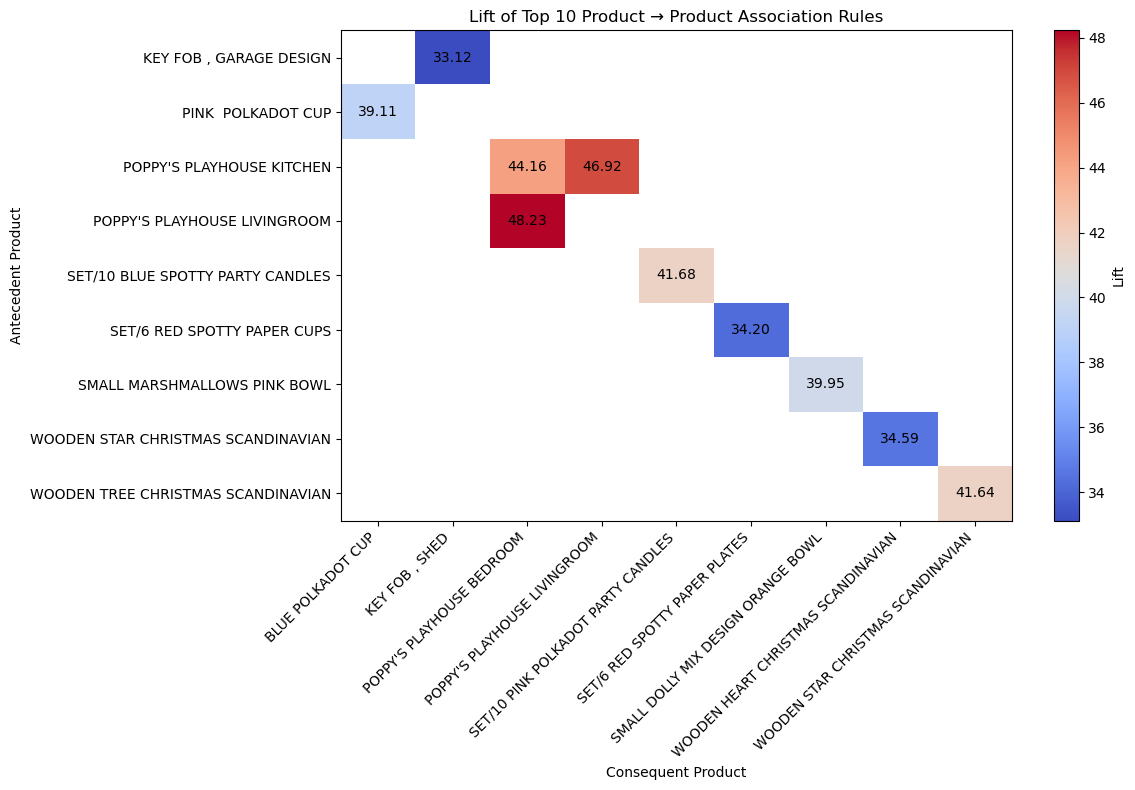

In [ ]:
# Creating a heatmap for these interesting rules:

# Make a copy of the interesting Product -> Product rules
unique_product_rules = interesting_product_rules.copy()

# Create a key that treats reversed rules as the same relationship (A -> B and B -> A will receive the same key)
unique_product_rules["rule_pair"] = unique_product_rules.apply(
    lambda row: tuple(sorted([tuple(sorted(row["antecedents"])),tuple(sorted(row["consequents"]))])),axis=1)

# Remove reversed duplicates
unique_product_rules = unique_product_rules.drop_duplicates(subset="rule_pair")

# Select the top 10 unique relationships by lift
top_product_rules = (unique_product_rules.sort_values(by="lift", ascending=False).head(10))

# Make a copy for the heatmap
heatmap_data = top_product_rules.copy()

heatmap_data["Antecedent"] = heatmap_data["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_", "") for item in x])))

heatmap_data["Consequent"] = heatmap_data["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_", "") for item in x])))

# use lift as the value for matrix
heatmap_matrix = heatmap_data.pivot_table(index="Antecedent",columns="Consequent",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap_matrix, aspect="auto")
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=45,ha="right")

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

# Add lift values inside cells
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i, j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")


# Add coolwarm color scale
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")
cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Consequent Product")
plt.ylabel("Antecedent Product")
plt.title(
    "Lift of Top 10 Product → Product Association Rules"
)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
To keep the heatmap readable, only the top 10 unique Product → Product relationships based on lift were visualized. Reversed rules were treated as the same relationship for this visualization because lift is symmetric and therefore has the same value in both directions. Both directions were kept in the full association-rule analysis because confidence is directional and can differ between two rules that have the same lift and support. The heatmap shows the top 10 unique Product → Product relationships based on lift. The strongest association is between Poppy's Playhouse Bedroom and Livingroom, with a lift of 48.23. Other products from the Poppy's Playhouse collection also have very high lift values. Similar patterns can be seen among the party products and Scandinavian Christmas decorations. Overall, the strongest associations tend to occur between related or complementary products, suggesting that customers often purchase products from the same collection or theme together.
</div>

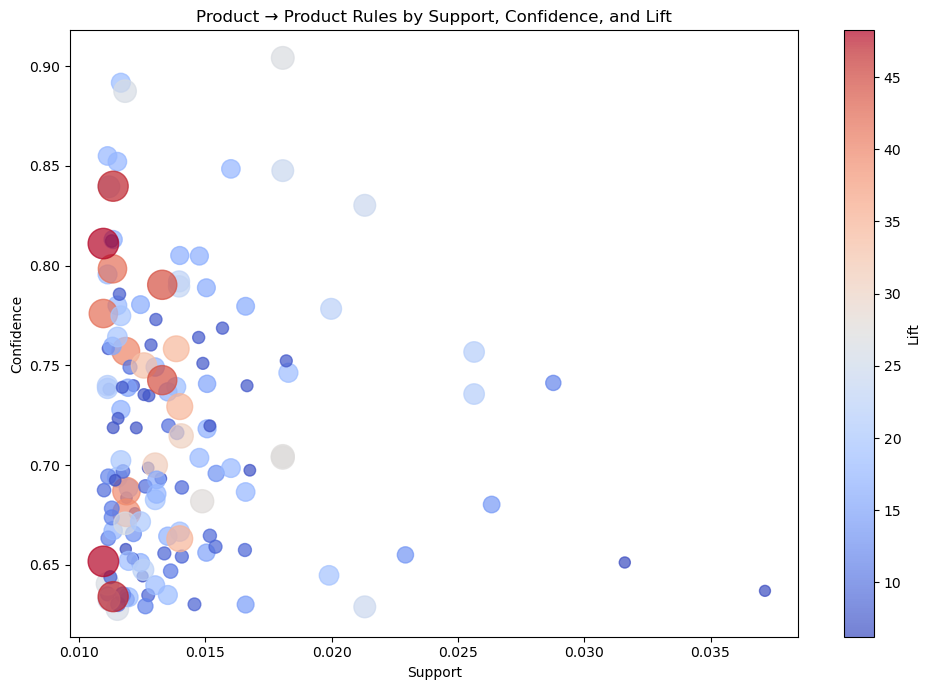

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    interesting_product_rules["support"],
    interesting_product_rules["confidence"],
    s=interesting_product_rules["lift"] * 10,
    c=interesting_product_rules["lift"],
    cmap="coolwarm",
    alpha=0.7
)

# Add colour bar for lift
cbar = plt.colorbar(scatter)
cbar.set_label("Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Product → Product Rules by Support, Confidence, and Lift")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The scatter plot compares the interesting rules found across all three association-rule measures (support, confidence and lift). Support is shown on the x-axis, confidence on the y-axis, and lift is represented by both the size and colour of the bubbles, where the larger and warmer-coloured bubbles show a stronger lift. The plot shows that rules that have the highest lift do not necessarily have the highest support or confidence. This shows why it's important to consider different metrics when considering intersting association rules.
</div>

#### Weather -> Product interesting rules

In [ ]:
interesting_weather_product_rules = weather_product_rules[(weather_product_rules["support"] >= weathert_product_support)
    &(weather_product_rules["confidence"] >= weathert_product_confidence) &(weather_product_rules["lift"] >= weathert_product_lift)].copy()

print("Interesting Weather → Product Rules:",len(interesting_weather_product_rules))

Interesting Weather → Product Rules: 11


In [ ]:
interesting_weather_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(11)

,antecedents,consequents,support,confidence,lift
12525,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.010683,0.182205,1.282735
11900,(TEMP_Low Avg Temp),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.024974,0.172282,1.212872
53319,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.020145,0.112593,1.191668
52526,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.014818,0.108625,1.149669
16025,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.015373,0.112693,1.104498
15856,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.014651,0.111228,1.090139
14898,(TEMP_High Avg Temp),(PRODUCT_JUMBO BAG RED RETROSPOT),0.049587,0.110918,1.087099
15014,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.019563,0.109336,1.071596
11914,(RAIN_Low Rainfall),(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.049531,0.148787,1.047469
13294,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.020229,0.146739,1.033050


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After filtering based on the thresholds defined for the weather -> product category of rules, we are left with 11 rules. The strongest relationship which had a low average temperate and a low rainfall was associated with purchasing WHITE HANGING HEART T-LIGHT HOLDEwith a lift value of 1.28  and a confidence of 18.22%. Low average temperature alone was also associated with this product with a lift of 1.21. Several rules that involved a high average temperate were associated with purchasing JUMBO BAG RED RETROSPOT with a lower lift of 1.07 to 1.19. Rules that involved row rainfall and average temperature were also associated with buying WHITE HANGING HEART T-LIGHT HOLDER. The results show that some products were purchased somewhat more frequently under particular temperature and rainfall conditions than expected. However, the relatively low lift values show that weather has a much weaker association with product purchasing than the Product -> Product relationships that were identified earlier.
</div>

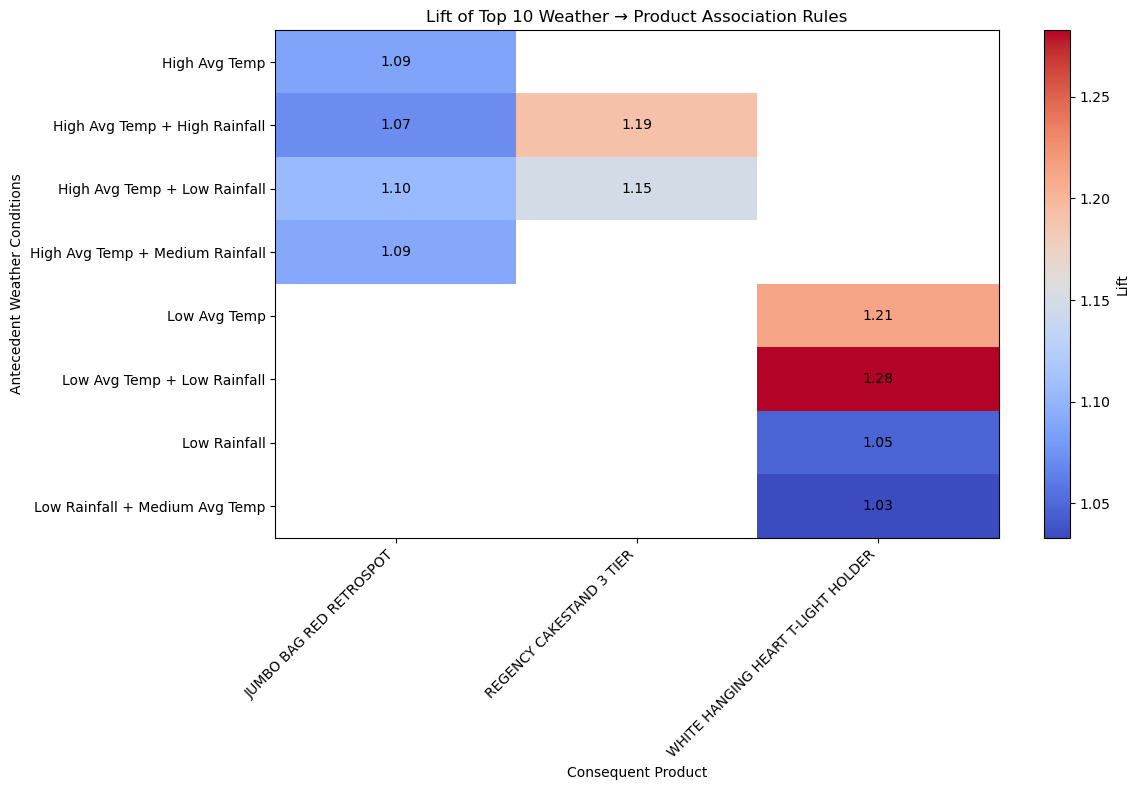

In [ ]:
# Creating a heatmap for the interesting Weather -> Product rules

# Select the top 10 Weather -> Product rules based on lift
top_weather_product_rules = interesting_weather_product_rules.sort_values(by="lift",ascending=False).head(10).copy()

# Convert antecedents and consequents into readable text
top_weather_product_rules["Weather Conditions"] = top_weather_product_rules["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("TEMP_","").replace("RAIN_","") for item in x])))
top_weather_product_rules["Product"] = top_weather_product_rules["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_","") for item in x])))

heatmap_matrix = top_weather_product_rules.pivot_table(index="Weather Conditions",columns="Product",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(12,8))
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=45,ha="right")

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

# Add lift values inside cells
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i,j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")

cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Consequent Product")
plt.ylabel("Antecedent Weather Conditions")
plt.title("Lift of Top 10 Weather → Product Association Rules")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The heatmap shows the strongest associaiton rules for Weather -> Product category based on their lift. The strongest relationships are under low average temperature combined with low rainfall which was associated with the Whilte Hanging Heart T-light Holder with a lift of 1.28. High-temperature conditions show a weaker positive associations with the Jumbo Bad Red Retrospot and Regency Cakestand 3 Tier. Overall, evern though all the displayed lift values are above 1 and there is a positive realtionship among all the rules, their small lift sizes show that weather conditions have only a limited association with product purchasing patterns.
</div>

#### Weather -> Transaction Sales interesting rules

In [ ]:
interesting_weather_sales_rules = weather_sales_rules[(weather_sales_rules["support"] >= weathert_sales_support)
    &(weather_sales_rules["confidence"] >= weathert_sales_confidence) &(weather_sales_rules["lift"] >= weathert_sales_lift)].copy()

print("Interesting Weather → Transaction Sales Rules:",len(interesting_weather_sales_rules))

Interesting Weather → Transaction Sales Rules: 11


In [ ]:
interesting_weather_sales_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(11)

,antecedents,consequents,support,confidence,lift
6281,"(RAIN_High Rainfall, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011904,0.367295,1.101853
6395,"(RAIN_Medium Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.019646,0.364385,1.092943
6399,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.020950,0.357312,1.071727
45390,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.048282,0.353946,1.061809
5986,(TEMP_Low Avg Temp),(SALES_Low Transaction Sales),0.050058,0.345329,1.035787
8065,"(RAIN_Medium Rainfall, TEMP_High Avg Temp)",(SALES_Low Transaction Sales),0.045480,0.345271,1.035611
7917,(RAIN_Medium Rainfall),(SALES_Low Transaction Sales),0.116238,0.343642,1.030727
6641,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(SALES_Medium Transaction Sales),0.020090,0.342641,1.028151
45377,"(TEMP_Medium Avg Temp, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.047228,0.342593,1.027749
9913,"(TEMP_Medium Avg Temp, RAIN_Medium Rainfall)",(SALES_Medium Transaction Sales),0.052167,0.341818,1.025682


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After filtering the rules based on the thresholds defined for the Weather -> Transaction Sales category, we can see that the strongest rule associated low average temperatore and high rainfall with high transaction sales with a lift of 1.1 and confidence of about 36.7%. Other weather combinations were associated with Low or Medium transaction sales, but their lift values were very close to 1 which shows that even though they have a positiev relationship, these rules are not very strong. Overall, the results show that weather conditions have weak associations with transaction sales levels.
</div>

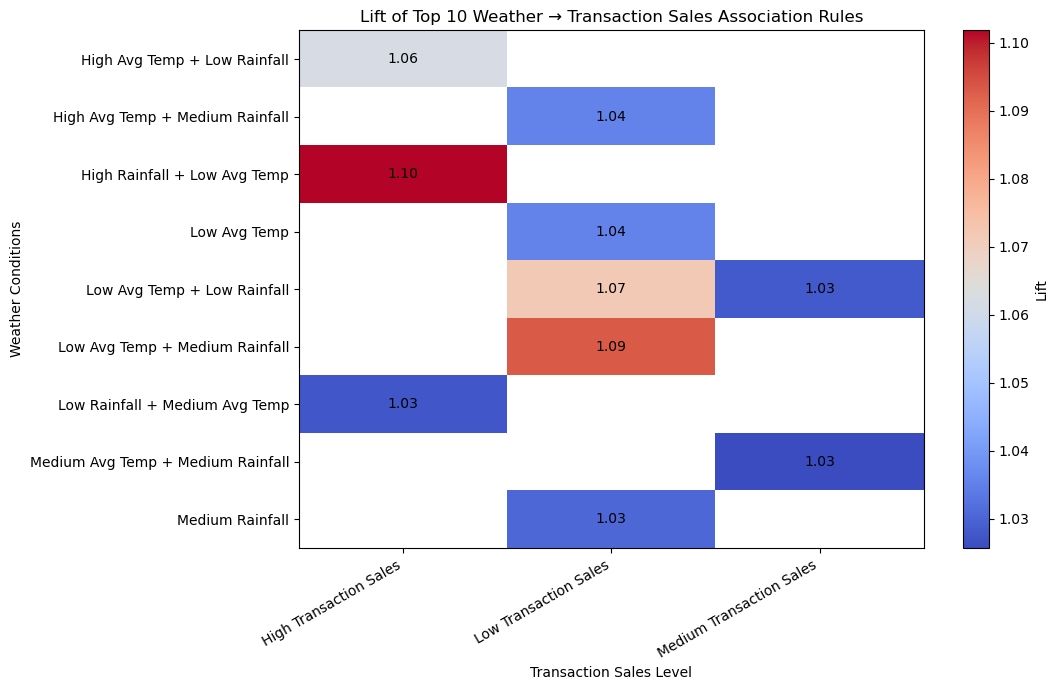

In [ ]:
# Creating a heatmap for the interesting Weather -> Transaction Sales rules

top_weather_sales_rules = interesting_weather_sales_rules.sort_values(by="lift",ascending=False).head(10).copy()

# Convert antecedents and consequents into readable text
top_weather_sales_rules["Weather Conditions"] = top_weather_sales_rules["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("TEMP_","").replace("RAIN_","") for item in x])))
top_weather_sales_rules["Sales Level"] = top_weather_sales_rules["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("SALES_","") for item in x])))

# Use lift as the value for the matrix
heatmap_matrix = top_weather_sales_rules.pivot_table(index="Weather Conditions",columns="Sales Level",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(11,7))
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")

# Add axis labels
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=30,ha="right")

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i,j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")

cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Transaction Sales Level")
plt.ylabel("Weather Conditions")
plt.title("Lift of Top 10 Weather → Transaction Sales Association Rules")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The heatmap shows the strongest Weather → Transaction Sales associations based on their lift value. The strongest relationship is between low average temperature combined with high rainfall and high transaction sales, with a lift of 1.10. Low average temperature combined with medium rainfall also showed a small positive association with Low Transaction Sales (lift = 1.09). However, all lift values are relatively close to 1, which shows that the relationships between weather conditions and transaction sales levels are weak overall and that weather does not appear to have a strong impact in distinguishing between Low, Medium, and High transaction sales.  
</div>

####  Weather + Time/Day → Transaction Sales interesting rules

In [ ]:
interesting_weather_time_sales_rules = weather_time_sales_rules[(weather_time_sales_rules["support"] >= weather_time_sales_support)
    &(weather_time_sales_rules["confidence"] >= weather_time_sales_confidence ) &(weather_time_sales_rules["lift"] >= weather_time_sales_lift)].copy()

print("Interesting Weather + Time/Day → Transaction Sales Rules:",len(interesting_weather_time_sales_rules))

Interesting Weather + Time/Day → Transaction Sales Rules: 71


In [ ]:
interesting_weather_time_sales_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
43855,"(TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010877,0.414376,1.242888
43859,"(DAY_Weekday, TEMP_High Avg Temp, TIME_Evening)",(SALES_Low Transaction Sales),0.010822,0.413136,1.239166
5617,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.015262,0.396825,1.190443
5597,"(TEMP_Medium Avg Temp, TIME_Morning, RAIN_Low Rainfall)",(SALES_High Transaction Sales),0.017398,0.384427,1.153248
6299,"(RAIN_High Rainfall, DAY_Weekday, TEMP_Low Avg Temp)",(SALES_High Transaction Sales),0.011377,0.378578,1.135703
6507,"(RAIN_Medium Rainfall, DAY_Weekday, TIME_Afternoon, TEMP_Low Avg Temp)",(SALES_Low Transaction Sales),0.010683,0.378564,1.135473
5638,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.015928,0.378378,1.135104
5584,"(TIME_Morning, RAIN_Low Rainfall, DAY_Weekday)",(SALES_High Transaction Sales),0.036073,0.377030,1.131059
5608,"(TIME_Morning, RAIN_Low Rainfall, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.017398,0.372771,1.118281
3748,"(TIME_Morning, RAIN_High Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(SALES_High Transaction Sales),0.018564,0.372494,1.117452


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The strongest rule shows that high average temperature during the evening is associated with Low Transaction Sales, with a lift of 1.24 and a confidence of about 41.4%. High average temperature combined with evening purchases on weekdays has a somewhat similar association (lift = 1.239). Several morning conditions were associated with high transaction sales with lift of about 1.13 and 1.15. Overall, these results show that combining weather with temporal conditions provides somewhat stronger associations with transaction sales than weather alone. However, the lift values are relatively close to 1, which shows that these relationships are not very strong.
</div>

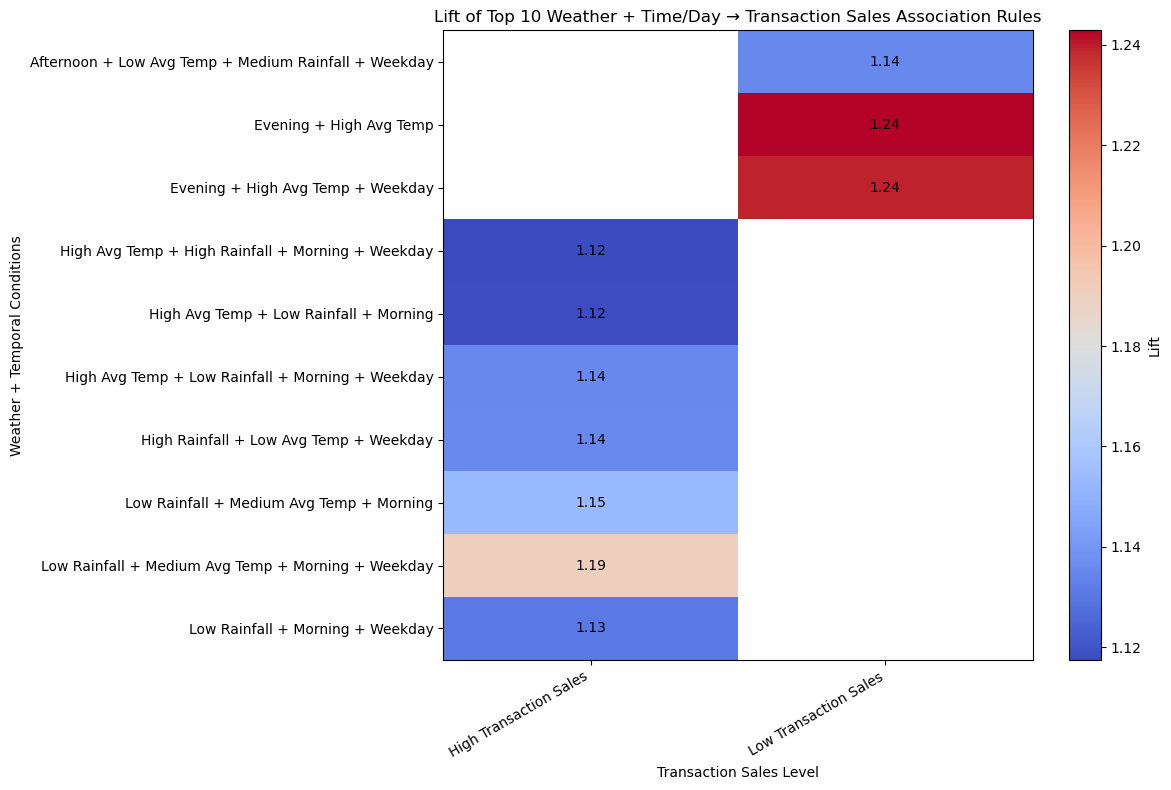

In [ ]:
# Creating a heatmap for the interesting Weather + Time/Day -> Transaction Sales rules

top_weather_time_sales_rules = interesting_weather_time_sales_rules.sort_values(by="lift",ascending=False).head(10).copy()
top_weather_time_sales_rules["Weather + Temporal Conditions"] = top_weather_time_sales_rules["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("TEMP_","").replace("RAIN_","").replace("TIME_","").replace("DAY_","") for item in x])))
top_weather_time_sales_rules["Sales Level"] = top_weather_time_sales_rules["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("SALES_","") for item in x])))
heatmap_matrix = top_weather_time_sales_rules.pivot_table(index="Weather + Temporal Conditions",columns="Sales Level",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(12,8))
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")

ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=30,ha="right")
ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

# Add lift values inside cells
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i,j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")

cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Transaction Sales Level")
plt.ylabel("Weather + Temporal Conditions")
plt.title("Lift of Top 10 Weather + Time/Day → Transaction Sales Association Rules")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The heatmap visually shows the results we got from the previous table, indicating that combining weather and temporal conditions produces somewhat stronger associations with transaction sales than weather alone. The strongest relationships can be seen for high average temperature during the evening, which was associated with low transaction sales with a lift of about 1.24. The two weakest rules indicate that high average temperate in the morning for both low and high rainfall are weakly associated with high transaction sales (life of 1.12). Although these associations are relatively low, the results still shows that that considering the time and day that weather conditions occur provides more information about transaction sales patterns than considering weather conditions alone.
</div>

####  Weather + Time/Day → Products interesting rules

In [ ]:
interesting_weather_time_product_rules = weather_time_product_rules[(weather_time_product_rules["support"] >= weather_time_products_support)
    &(weather_time_product_rules["confidence"] >= weather_time_products_confidence ) &(weather_time_product_rules["lift"] >= weather_time_products_lift)].copy()

print("Interesting Weather + Time/Day → Products Rules:",len(interesting_weather_time_product_rules))

Interesting Weather + Time/Day → Products Rules: 8


In [ ]:
interesting_weather_time_product_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
53439,"(RAIN_High Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.017620,0.112969,1.195649
12512,"(DAY_Weekday, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.021200,0.167875,1.181849
52972,"(TIME_Morning, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_REGENCY CAKESTAND 3 TIER),0.014568,0.111111,1.175983
12520,"(TIME_Afternoon, TEMP_Low Avg Temp)",(PRODUCT_WHITE HANGING HEART T-LIGHT HOLDER),0.014984,0.166103,1.169371
16362,"(TIME_Afternoon, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.027693,0.118274,1.159199
16164,"(RAIN_Low Rainfall, DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.014152,0.116200,1.138863
16187,"(TIME_Afternoon, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.031606,0.115365,1.130685
16175,"(DAY_Weekday, TEMP_High Avg Temp)",(PRODUCT_JUMBO BAG RED RETROSPOT),0.044509,0.113702,1.114389


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The strongest association had high rainfall, high average temperature, and weekdays associated with purchasing Regency Cakestand 3 Tier with a lift of 1.20. Low average temperatures combined with weekdays or afternoon purchases were associated with the White Hanging Heart T-Light Holder and several high-temperature and temporal conditions were associated with the Jumbo Bag Red Retrospot purchasing. These rules show that adding temporal information to weather data shows some specific purchasing patterns, but the relatively low lift values of about 1.11–1.20 range show that these associations are generally not very strong.

</div>

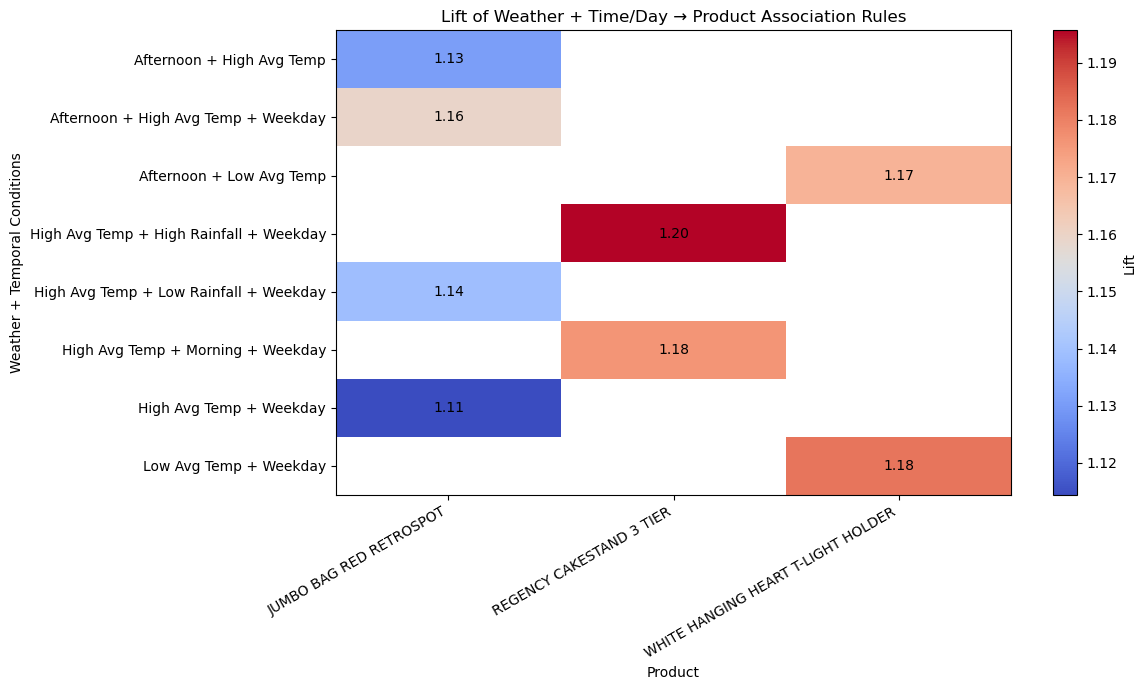

In [ ]:
# Creating a heatmap for the interesting Weather + Time/Day -> Product rules

heatmap_data = interesting_weather_time_product_rules.sort_values(by="lift",ascending=False).copy()

# Convert antecedents and consequents into readable text
heatmap_data["Weather + Temporal Conditions"] = heatmap_data["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("TEMP_","").replace("RAIN_","").replace("TIME_","").replace("DAY_","") for item in x])))
heatmap_data["Product"] = heatmap_data["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_","") for item in x])))
# Use lift as the value for the matrix
heatmap_matrix = heatmap_data.pivot_table(index="Weather + Temporal Conditions",columns="Product",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(12,7))
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")
# Add axis labels
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=30,ha="right")

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

# Add lift values inside cells
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i,j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")

# Add color scale
cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Product")
plt.ylabel("Weather + Temporal Conditions")
plt.title("Lift of Weather + Time/Day → Product Association Rules")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The heatmap also confirms that there are modest associations between weather, time/day conditions, and product purchases. The strongest relationship is high temperature, high rainfall, and weekdays associated with buying Regency Cakestand 3 Tier (lift = 1.20). The lift values are close to 1 which show that these conditions have only a weak influence on product purchasing patterns.
</div>

####  Weather -> Baket size interesting rules

In [ ]:
interesting_weather_basket_rules = weather_basket_rules[(weather_basket_rules["support"] >= weather_basket_size_support)
    &(weather_basket_rules["confidence"] >= weather_basket_size_confidence ) &(weather_basket_rules["lift"] >= weather_basket_size_lift)].copy()

print("Interesting Weather -> Basket size Rules:",len(interesting_weather_basket_rules))

Interesting Weather -> Basket size Rules: 5


In [ ]:
interesting_weather_basket_rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by=["lift", "confidence", "support"],
    ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
6329,"(RAIN_Low Rainfall, TEMP_Low Avg Temp)",(BASKET_Low Basket Size),0.023114,0.394226,1.172012
5984,(TEMP_Low Avg Temp),(BASKET_Low Basket Size),0.054137,0.373469,1.110300
11120,"(RAIN_Low Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.048144,0.352929,1.060701
3032,"(RAIN_High Rainfall, TEMP_High Avg Temp)",(BASKET_High Basket Size),0.063017,0.352202,1.058516
10414,(TEMP_High Avg Temp),(BASKET_High Basket Size),0.156363,0.349761,1.051179


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After filtering the rules based on the thresholds selected, there are 5 interesting rules left. The strongest associated shows that low average temperature and low rainfall is assoiated with a low basket size with a lift of 1.17. While low temperate alone is also associated with low basket size with a lift of 1.11. In contrast, high average temperature is associated with high basket size and similar patterns can be seen when high temperature is combined with either low or high rainfall (lift = 1.05 - 1.06). These results align with the clustering analysis, particularly the K-Mediod result, to some extent where the coldest cluster had the lowest average purchasing quantity. However, clustering also identified that the high purchasing quantity happened under rainy, humid, cloudy, and windy conditions, which some of these attributes are not represented in the association rules which uses only temperature and rainfall. Overall, both methods show that weather conditions are associated with purchasing quantity, although the relationship appears to be more complex than just one single weather factor.
</div>

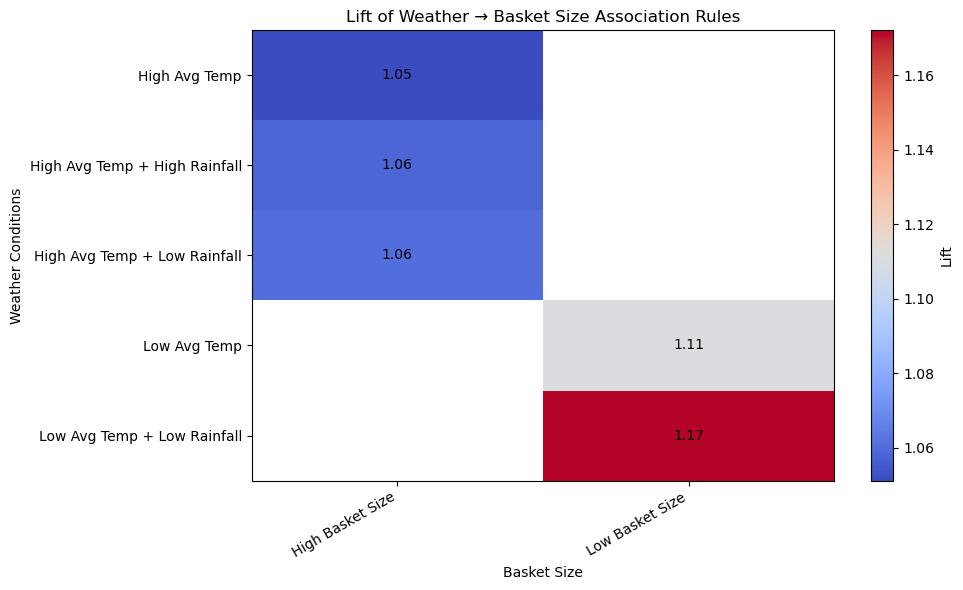

In [ ]:
# Creating a heatmap for the interesting Weather -> Basket Size rules
heatmap_data = interesting_weather_basket_rules.sort_values(by="lift",ascending=False).copy()

# Convert antecedents and consequents into readable text
heatmap_data["Weather Conditions"] = heatmap_data["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("TEMP_","").replace("RAIN_","") for item in x])))
heatmap_data["Basket Size"] = heatmap_data["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("BASKET_","") for item in x])))

heatmap_matrix = heatmap_data.pivot_table(index="Weather Conditions",columns="Basket Size",values="lift",aggfunc="max")

# Create heatmap
fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(heatmap_matrix,aspect="auto",cmap="coolwarm")

# Add axis labels
ax.set_xticks(range(len(heatmap_matrix.columns)))
ax.set_xticklabels(heatmap_matrix.columns,rotation=30,ha="right")
ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

# Add lift values inside cells
for i in range(len(heatmap_matrix.index)):
    for j in range(len(heatmap_matrix.columns)):
        value = heatmap_matrix.iloc[i,j]
        if pd.notna(value):
            ax.text(j,i,f"{value:.2f}",ha="center",va="center")

# Add color scale
cbar = plt.colorbar(im)
cbar.set_label("Lift")
plt.xlabel("Basket Size")
plt.ylabel("Weather Conditions")
plt.title("Lift of Weather → Basket Size Association Rules")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The heatmap shows a clear temperature-related pattern and its association with the basket size. Low average temperatures are associated with low basket size, where the strongest relationship has low temperature and low rainfall (lift = 1.17). In contrast, high average temperatures are associated with high basket size even though these are weaker relationships (lift = 1.05–1.06). The heatmap visually supports the findings from the previous table and shows that there is somewhat a relationship between weather and basket size.
</div>

# Classification Analysis

## Preprocessing

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The classification question to analyze is if the retail sales will be low, medium or high depend on the weather and temporal conditions. For this analysis, variables that directly represent the transaction sales amount were excluded in order to avoid data leakage since the models could calculate the transaction sales amount based on these variables. Additionally, categorical variables were converted to numeric variables using one-hot encoding, but the traget sales categories were label encoded.
</div>

<!-- <div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Before the analysis we need to make sure that the dataframe has the data in the form that we need. Since transaction_sales_bin represents the total sales value of the entire invoice, the classification dataset was aggregated to create one observation per transaction. In the original dataset an invoice can contain multiple product rows, while the same transaction sales category is repeated across those rows. This structure would not work well as the model would attempt to preduct a transaction-level outcom only from a part of the transaction (we had a somewhat similar issue in the association rule mining section which we fixed with aggregating the transactio-level rows). That is why the data is aggregated by invoice_id so that transaction-level characteristics correspond correctly to the same level of analysis as the target variable.
</div> -->

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
    The original dataset contains multiple rows for each transaction since each product that is purchased within an invoice is stored as a reparate rown. However, the target variable for the question we are trying to answer here is transaction_sales_bin which represents the sales category of the entire invoice. That is why the dataset is aggregated by invoice_id in order to create on obesrvation per transaction and therefore avoid counting the same transaction multiple times.
</div>

In [ ]:
# Creating one row per transaction for the classification analysis

classification_df = retail_weather_dataset.groupby("invoice_id").agg(

    # Weather characteristics
    # these values are already identical for all the rows in the same invoice, therefore we just take the first value that appears
    avg_min_temp_c=("avg_min_temp_c", "first"),
    avg_max_temp_c=("avg_max_temp_c", "first"),
    avg_rain_mm=("avg_rain_mm", "first"),
    avg_humidity_pct=("avg_humidity_pct", "first"),
    avg_cloud_cover_pct=("avg_cloud_cover_pct", "first"),
    avg_wind_speed_kmh=("avg_wind_speed_kmh", "first"),
    avg_temp_c=("avg_temp_c", "first"),
    temp_range_c=("temp_range_c", "first"),

    # Temporal characteristics
    day_type=("day_type", "first"),
    time_bin=("time_bin", "first"),

    # Target
    transaction_sales_bin=("transaction_sales_bin", "first")).reset_index()

<!-- trfhgh -->

In [ ]:
# Looking to see if the class is balanced (since we used equal-frequency binning)
classification_df["transaction_sales_bin"].value_counts()

transaction_sales_bin
Low Transaction Sales       12015
High Transaction Sales      12013
Medium Transaction Sales    12010
Name: count, dtype: int64

In [ ]:
# Selecting features from the new dataframe that will be used as attributes to predict the target
features = [
    "avg_min_temp_c",
    "avg_max_temp_c",
    "avg_rain_mm",
    "avg_humidity_pct",
    "avg_cloud_cover_pct",
    "avg_wind_speed_kmh",
    "avg_temp_c",
    "temp_range_c",
    "day_type",
    "time_bin"
]


In [ ]:
# Creating the predictor variables
X = classification_df[features].copy()

# Selecting the target variable
y = classification_df["transaction_sales_bin"].copy()

In [ ]:
# Applying one-hot encoding on the categorical predictor variables
X = pd.get_dummies(X,columns=["day_type", "time_bin"],drop_first=False,dtype=int)

In [ ]:
X.head()

,avg_min_temp_c,avg_max_temp_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh,avg_temp_c,temp_range_c,day_type_Weekday,day_type_Weekend,time_bin_Afternoon,time_bin_Evening,time_bin_Morning
0,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,3.416501,5.727634,1,0,0,0,1
1,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,3.416501,5.727634,1,0,0,0,1
2,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,3.416501,5.727634,1,0,0,0,1
3,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,3.416501,5.727634,1,0,0,0,1
4,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,3.416501,5.727634,1,0,0,0,1


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36038 entries, 0 to 36037
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   avg_min_temp_c       36038 non-null  float64
 1   avg_max_temp_c       36038 non-null  float64
 2   avg_rain_mm          36038 non-null  float64
 3   avg_humidity_pct     36038 non-null  float64
 4   avg_cloud_cover_pct  36038 non-null  float64
 5   avg_wind_speed_kmh   36038 non-null  float64
 6   avg_temp_c           36038 non-null  float64
 7   temp_range_c         36038 non-null  float64
 8   day_type_Weekday     36038 non-null  int64  
 9   day_type_Weekend     36038 non-null  int64  
 10  time_bin_Afternoon   36038 non-null  int64  
 11  time_bin_Evening     36038 non-null  int64  
 12  time_bin_Morning     36038 non-null  int64  
dtypes: float64(8), int64(5)
memory usage: 3.6 MB


In [ ]:
# Converting X and y to NumPy arrays for indexing during cross-validation
X = X.values
y = y.values

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After applying one-hot encoding to the numerical variables of the training dataset, we no have all the predictors in numerical form. Now we will use a 5-fold stratified cross validation with 80% of the data used for training and 20% for testing in each fold. Stratification will also be used to preserve a similar distribution of the three transaction sales amount categories across the folds.
</div>

In [ ]:
# Creating 5 training and testing folds
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## Creating the models

In [ ]:
# Creating a dictionary of the initialized models required along with their names so that the evaluateModel defined is applied to each of them
models = {
    "Naïve Bayes": GaussianNB(),
    "K-Nearest Neighbor": KNeighborsClassifier(n_neighbors=5),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)}

In [ ]:
# Defining the order of the target classes for the confusion matrix
class_labels = ["Low Transaction Sales","Medium Transaction Sales","High Transaction Sales"]

In [ ]:
# Defining a function for training, predicting, and evaluating the models all in one place

def evaluateModel(model, label, x_train, y_train, x_test, y_test):

    # Train the classifier
    model.fit(x_train, y_train)
    # Make predictions on the test set
    y_pred = model.predict(x_test)

    print(f"Performance metrics for {label} model")

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Calculate precision
    precision = precision_score(y_test,y_pred,average="macro",zero_division=0)
    print(f"Precision: {precision:.4f}")

    # Calculate recall
    recall = recall_score(y_test,y_pred,average="macro",zero_division=0)
    print(f"Recall: {recall:.4f}")

    # Calculate F1 score
    f1 = f1_score(y_test,y_pred,average="macro",zero_division=0)
    print(f"F1 Score: {f1:.4f}")

    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)

    # Visualizing the results through a confusion matrix
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix - {label}")
    plt.show()

    # Return evaluation metrics for comparison of the models
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1}

In [ ]:
# Defining a function that runs the 5-fold cross-validation loop for each model

def run_k_fold_for_model(model_key):

    model_name = model_key
    model_obj = models[model_key]
    fold_results = []

    print(f"--- Evaluating Model: {model_name} ---")
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):

        print(f"\n****Fold {fold}****")
        # Create training and testing data
        x_train, x_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Standardizing the variables (We don't standardize earlier to avoid data leakage)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)

        # Train, predict, and evaluate the model
        metrics = evaluateModel(model_obj,model_name,x_train,y_train,x_test,y_test)
        fold_results.append(metrics)

    # Calculate the average performance across the five folds
    mean_accuracy = sum(m["Accuracy"] for m in fold_results) / len(fold_results)
    mean_precision = sum(m["Precision"] for m in fold_results) / len(fold_results)
    mean_recall = sum(m["Recall"] for m in fold_results) / len(fold_results)
    mean_f1 = sum(m["F1-Score"] for m in fold_results) / len(fold_results)
    print(f"\n***** {model_name} Final Cross-Validation Averages *****")
    print(f"Mean Accuracy:  {mean_accuracy:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall:    {mean_recall:.4f}")
    print(f"Mean F1-Score:  {mean_f1:.4f}")

## Naive Bayes

--- Evaluating Model: Naïve Bayes ---

****Fold 1****
Performance metrics for Naïve Bayes model
Accuracy: 0.3536
Precision: 0.3545
Recall: 0.3536
F1 Score: 0.3241


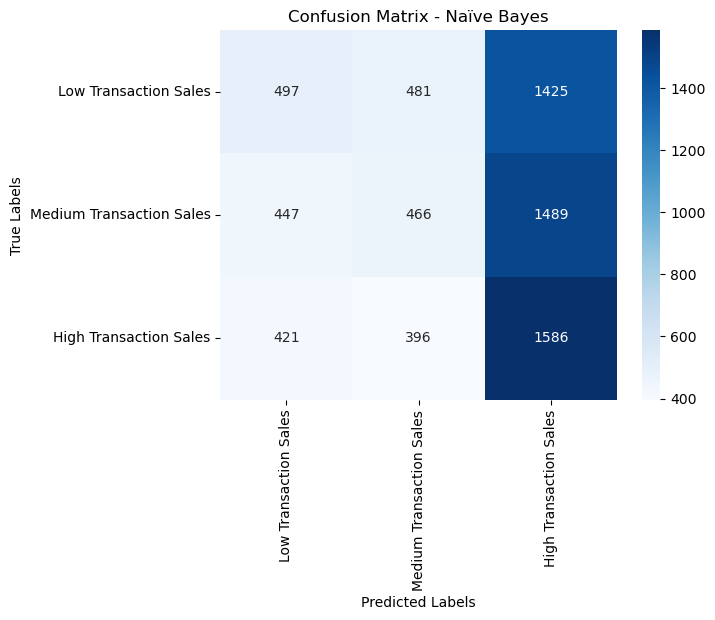


****Fold 2****
Performance metrics for Naïve Bayes model
Accuracy: 0.3518
Precision: 0.3661
Recall: 0.3518
F1 Score: 0.3071


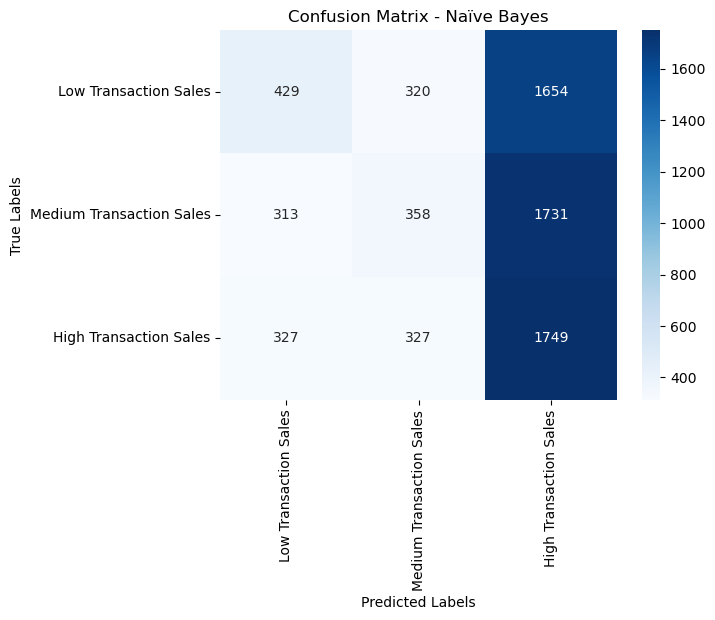


****Fold 3****
Performance metrics for Naïve Bayes model
Accuracy: 0.3511
Precision: 0.3581
Recall: 0.3511
F1 Score: 0.3121


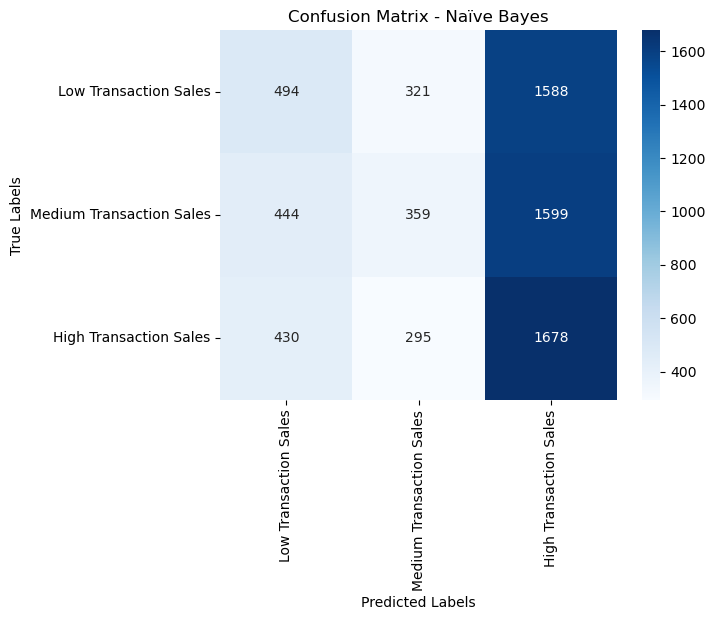


****Fold 4****
Performance metrics for Naïve Bayes model
Accuracy: 0.3497
Precision: 0.3591
Recall: 0.3497
F1 Score: 0.3097


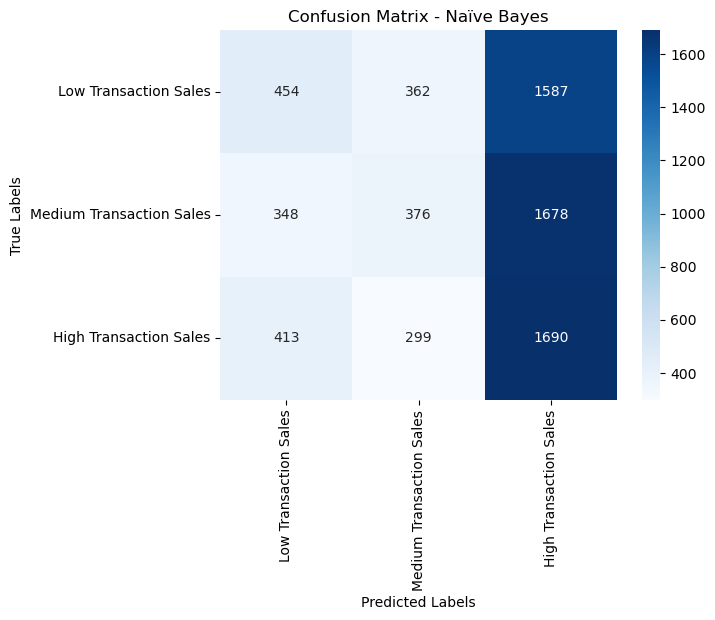


****Fold 5****
Performance metrics for Naïve Bayes model
Accuracy: 0.3462
Precision: 0.3534
Recall: 0.3462
F1 Score: 0.2993


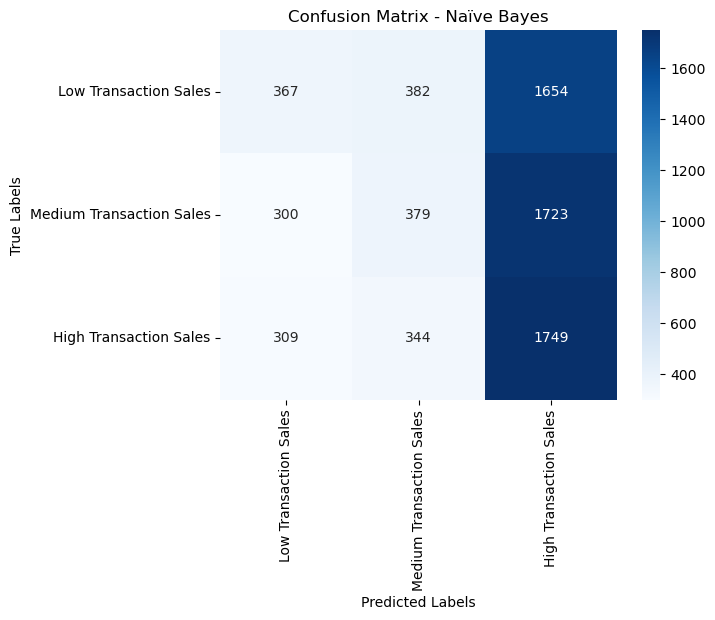


***** Naïve Bayes Final Cross-Validation Averages *****
Mean Accuracy:  0.3505
Mean Precision: 0.3582
Mean Recall:    0.3505
Mean F1-Score:  0.3105


In [ ]:
run_k_fold_for_model("Naïve Bayes")

## K-Nearest Neighbour

--- Evaluating Model: K-Nearest Neighbor ---

****Fold 1****
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.3460
Precision: 0.3452
Recall: 0.3460
F1 Score: 0.3390


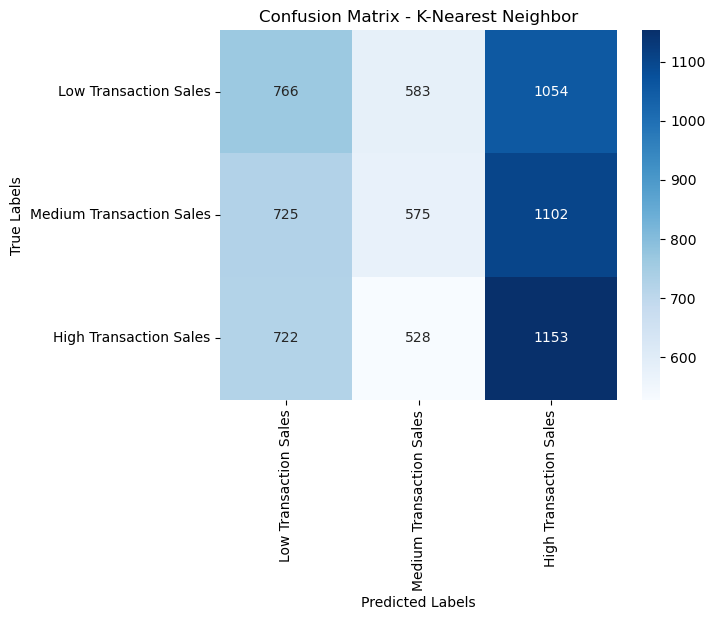


****Fold 2****
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.3496
Precision: 0.3499
Recall: 0.3496
F1 Score: 0.3405


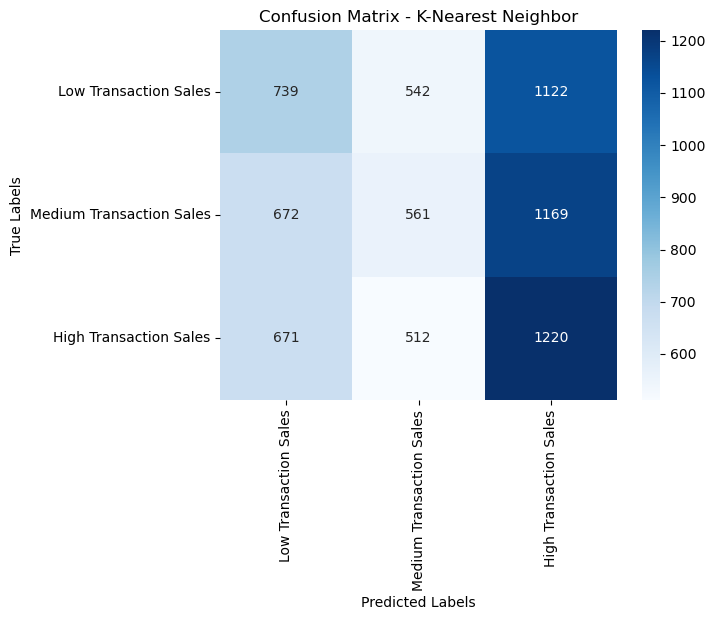


****Fold 3****
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.3432
Precision: 0.3448
Recall: 0.3432
F1 Score: 0.3349


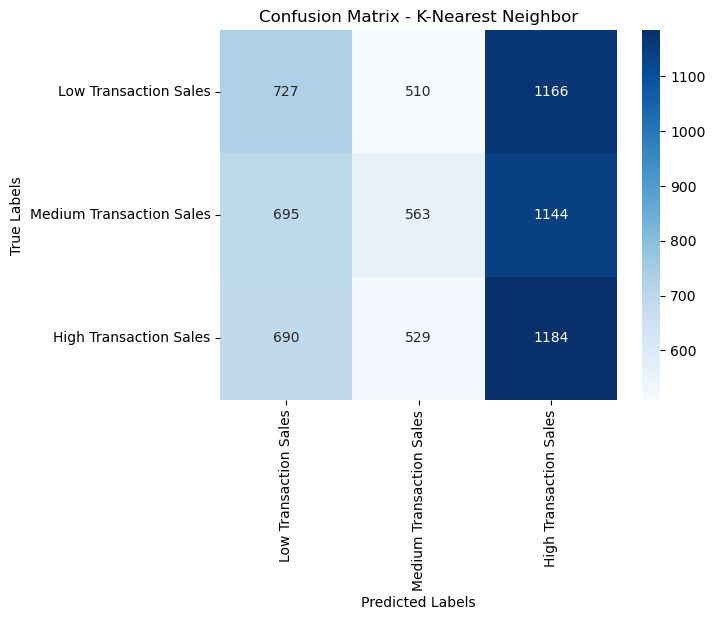


****Fold 4****
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.3558
Precision: 0.3570
Recall: 0.3558
F1 Score: 0.3466


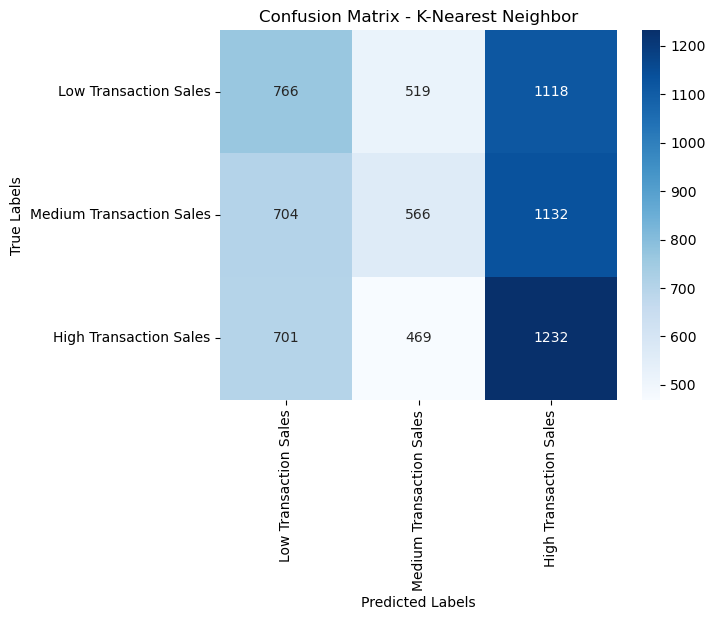


****Fold 5****
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.3465
Precision: 0.3451
Recall: 0.3465
F1 Score: 0.3387


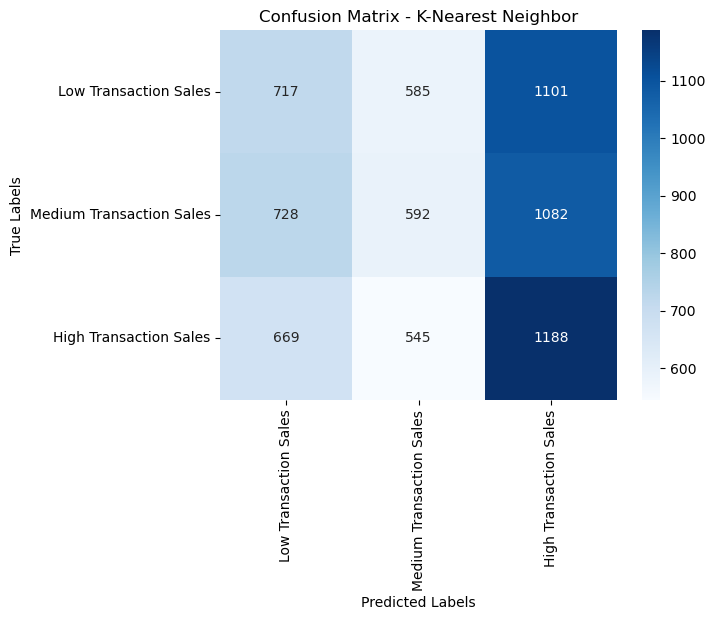


***** K-Nearest Neighbor Final Cross-Validation Averages *****
Mean Accuracy:  0.3482
Mean Precision: 0.3484
Mean Recall:    0.3482
Mean F1-Score:  0.3399


In [ ]:
run_k_fold_for_model("K-Nearest Neighbor")

## AdaBoost

--- Evaluating Model: AdaBoost ---

****Fold 1****
Performance metrics for AdaBoost model
Accuracy: 0.3561
Precision: 0.3558
Recall: 0.3561
F1 Score: 0.3513


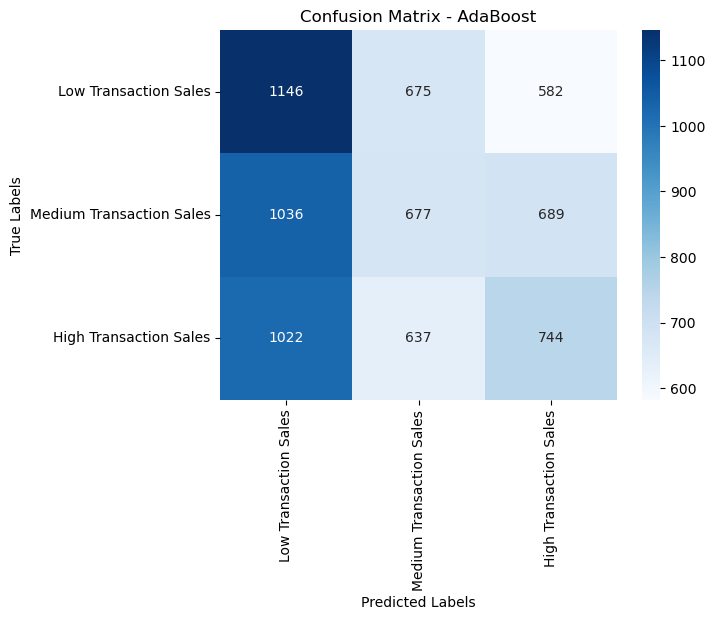


****Fold 2****
Performance metrics for AdaBoost model
Accuracy: 0.3511
Precision: 0.3526
Recall: 0.3511
F1 Score: 0.3258


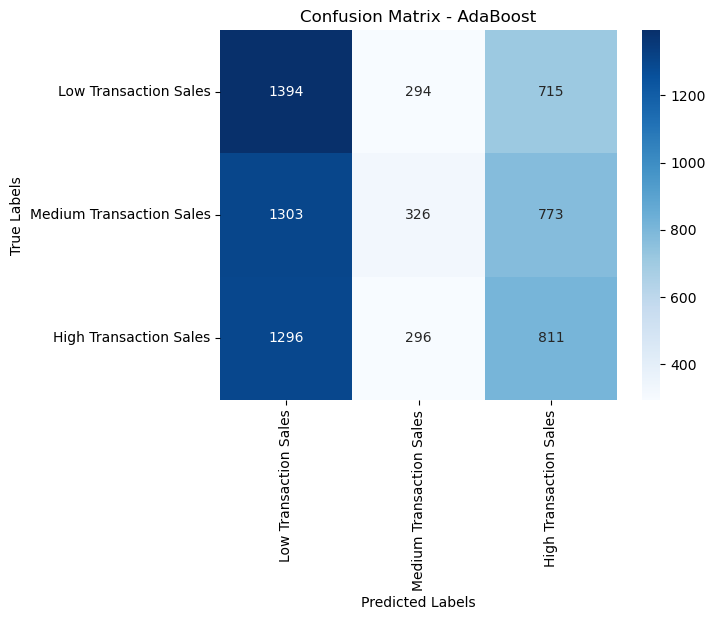


****Fold 3****
Performance metrics for AdaBoost model
Accuracy: 0.3570
Precision: 0.3576
Recall: 0.3570
F1 Score: 0.3523


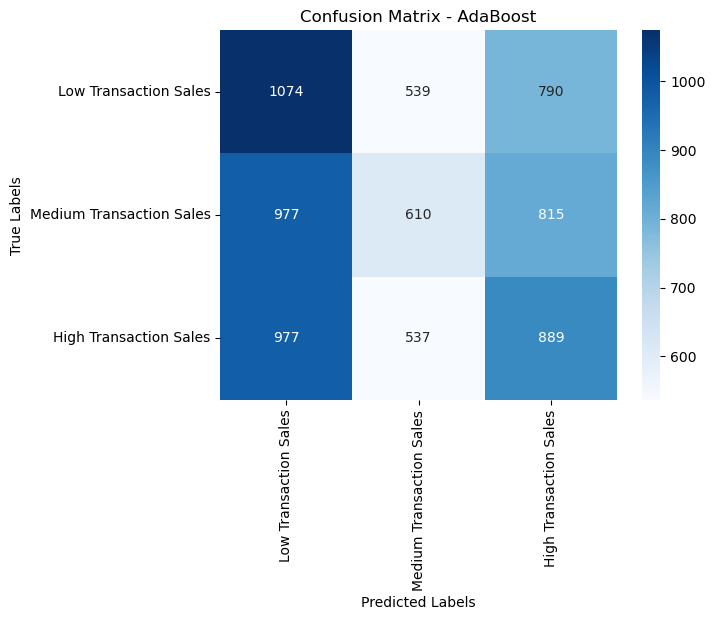


****Fold 4****
Performance metrics for AdaBoost model
Accuracy: 0.3486
Precision: 0.3476
Recall: 0.3485
F1 Score: 0.3433


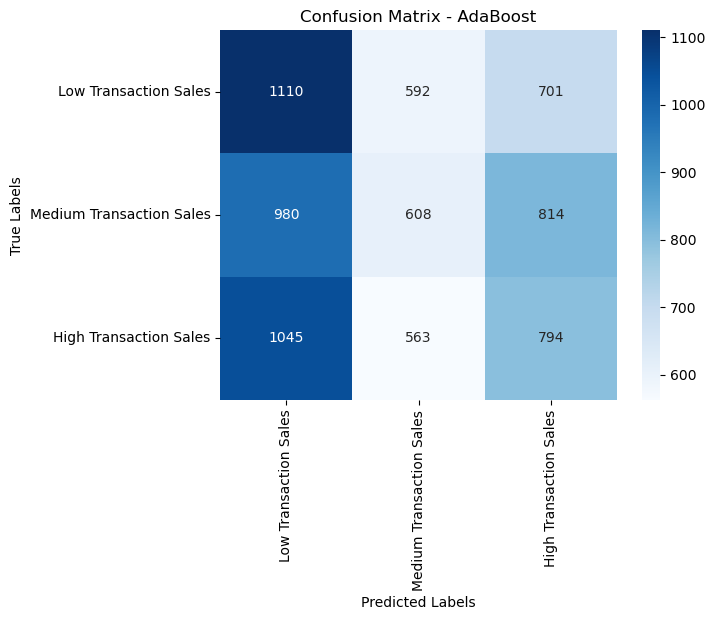


****Fold 5****
Performance metrics for AdaBoost model
Accuracy: 0.3530
Precision: 0.3501
Recall: 0.3530
F1 Score: 0.3400


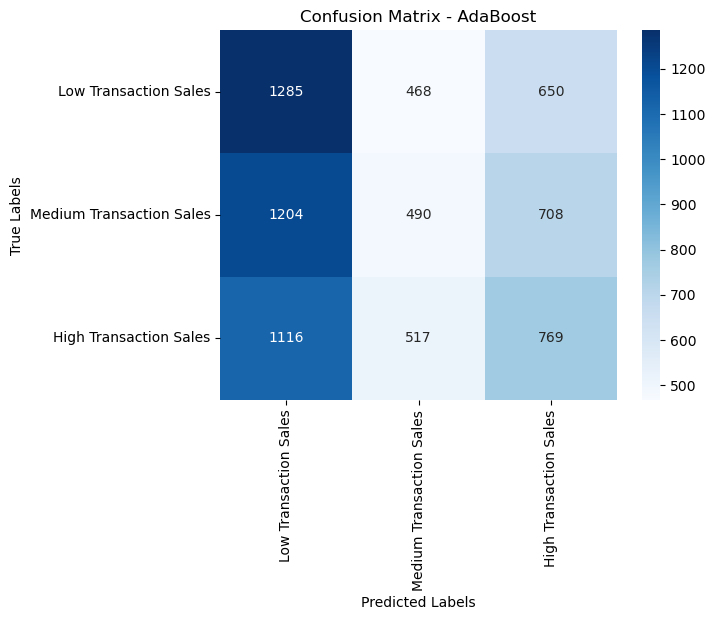


***** AdaBoost Final Cross-Validation Averages *****
Mean Accuracy:  0.3532
Mean Precision: 0.3527
Mean Recall:    0.3531
Mean F1-Score:  0.3426


In [ ]:
run_k_fold_for_model("AdaBoost")

# Model Comparison

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
 Naïve Bayes, K-Nearest Neighbour (KNN), and AdaBoost are thre three models that were investigaged to determine what is the transaction level (low, medium, and high) based on the weather and temporal conditions. The models are compared based on their average performance across all five folds. The three models produced a relatively similar result and a low classification performance. Naïve Bayes achieved an average accuracy of 35.05% and a macroF1 score of 31.05%. KNN had a slightly better performance where it achieved an average accuracy of 34.82% and a macro F1 score of 33.99%. AdaBoost demonstrated the best performance among the three models, achieving 35.32% average accuracy and 34.26% macro F1 score. However, the difference between AdaBoost and KNN was very small overall. Since we had three classes to predict, which were categorized by equal-frequency binning and therefore had approximately equal numbers of transactions, a simple baseline prediction would be expected to achieve about 33% accuracy at least. Even though AdaBoost performed the best among the three models, it is still just slightly above the baseline which shows that none of the three models were able to really classify reliably using the weather and temporal data.<br>
    <br>One possible reason for the weaker performance of Naïve Bayes is that is assumes that predictor variables are independent. The earlier correlation analysis however, showed a string relationship among several weather attributes, particularly the temperature-related variables, which means that its assumption is not well supported by the dataset. KNN performing a little better than Naïve Bayes means that there may be some local similarities between transactions occuring under similar weather conditions. AdaBoost produced the best overall performance, but it shows that even an ensemble method was not able to identify a string prediction pattern in these variables. <br> <br>Overall, this classification analysis demonstrated that weather and temporal conditions alone have limited ability to predict the sales value of an individual transaction. These values are probably influenced by other stronger factors that are not included in the datasets, factors such as promotions or even holidays. This result is also consistent with the earlier association rule analysis which found a relatively weak relationshop between weather conditions and purchases.

</div>

#  <center>               ******** Explanatory Analysis *********

## Insight 1: Wet, cloudy, and windy conditions are associated with larger purchases

While performing exploratory analysis, specifically cluster analysis, several useful findings were identified. K-medoid clustering found three distinct clusters with unique weather patterns. The reason k-medoid clustering results were selected over hierarchical cluster results is that the clusters were more balanced and had more distinguished weather and purchasing characteristics. The first cluster was found to be associated with cold conditions, specifically the lowest average temperature. The second cluster was found to be associated with warm, dry conditions, with the highest temperatures, lowest rainfall, and lowest humidity. The third cluster was associated with wet, cloudy, and windy conditions, with the highest average |rainfall, humidity, cloud cover, and wind speed. Since the goal of this analysis is to determine whether there is a relationship between weather patterns and retail purchases, we will compare retail patterns across the clusters.

In [ ]:
# Create meaningful cluster names for visualizations

cluster_names = {
    0: "Cold\nConditions",
    1: "Warm & Dry\nConditions",
    2: "Wet, Cloudy & Windy\nConditions"
}

# Add cluster names to the dataframe

kmedoid_profile["weather_pattern"] = (
    kmedoid_profile.index.map(cluster_names)
)

# Display the dataframe with the cluster names

kmedoid_profile

,quantity,unit_price,hour,day_type,avg_temp_c,temp_range_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh,weather_pattern
kmedoid_cluster,,,,,,,,,,,
0,6.74,3.61,14.13,0.15,4.24,4.74,1.15,88.74,53.71,14.87,Cold\nConditions
1,8.94,4.79,12.93,0.15,12.05,7.88,0.92,81.56,42.30,12.17,Warm & Dry\nConditions
2,12.19,3.62,12.67,0.11,10.05,4.73,3.95,89.11,69.09,19.05,"Wet, Cloudy & Windy\nConditions"


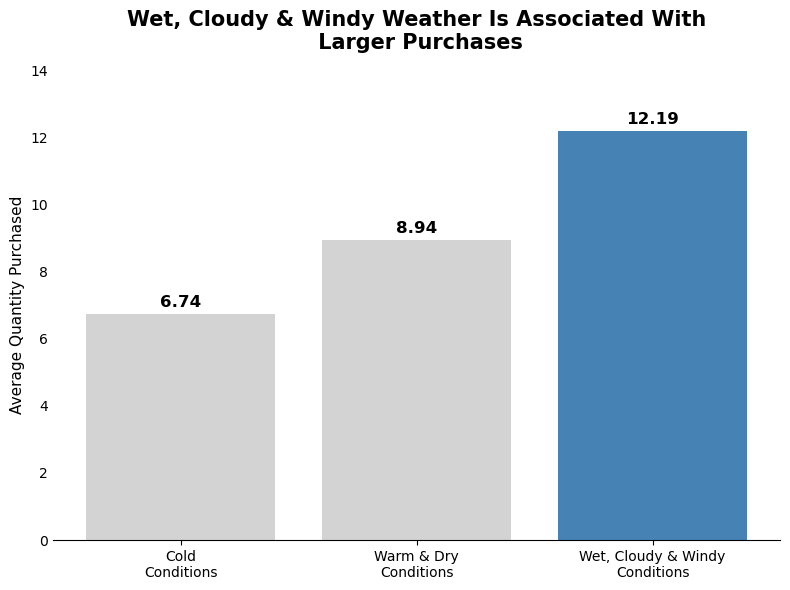

In [ ]:
# Create a figure that displays the weather conditions compared to the average quantity
plt.figure(figsize=(8, 6))

# Plot weather pattern by quantity with defined colours
bars = plt.bar(kmedoid_profile["weather_pattern"], kmedoid_profile["quantity"],
               color=["lightgray", "lightgray", "steelblue"])

# Add quantity values above bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.2,
             f"{bar.get_height():.2f}",ha="center",fontsize=12,fontweight="bold")

plt.title("Wet, Cloudy & Windy Weather Is Associated With\n Larger Purchases",
            fontsize=15, fontweight="bold", pad=15)
plt.ylabel("Average Quantity Purchased", fontsize=11)
plt.ylim(0, 14)

# Hide the axes lines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove the y-axis ticks
plt.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

The first insight shows a clear difference in the average quantity of items purchased under different weather conditions. The data show that purchase quantity is lowest in cold conditions, at an average of 6.74 units. Warm and dry conditions are associated with moderate-quantity purchases of 8.94 units.  In comparison, the wet, cloudy, windy conditions are associated with an average of 12.19 units purchased. These weather conditions include an average rainfall of 3.95 mm, an average humidity of 89.11%, an average cloud cover of 69.09%, and an average wind speed of 19.05 km/h. The quantity of items purchased during wet, cloudy, and windy conditions is 36% higher than during warm and dry conditions and 81% higher than during cold conditions. The store should use this insight and monitor short-term weather forecasts as an additional tool for short-term inventory planning to ensure that there are enough products available for shoppers. When similar conditions are forecast, stores could prepare for potentially larger quantities to be purchased by ensuring there are enough products available. Not using this information could lead to lost revenue for the store if customers are unable to purchase the amount of each product they would like because it is unavailable.

## Insight 2 — Warm and dry conditions are associated with higher-priced purchases

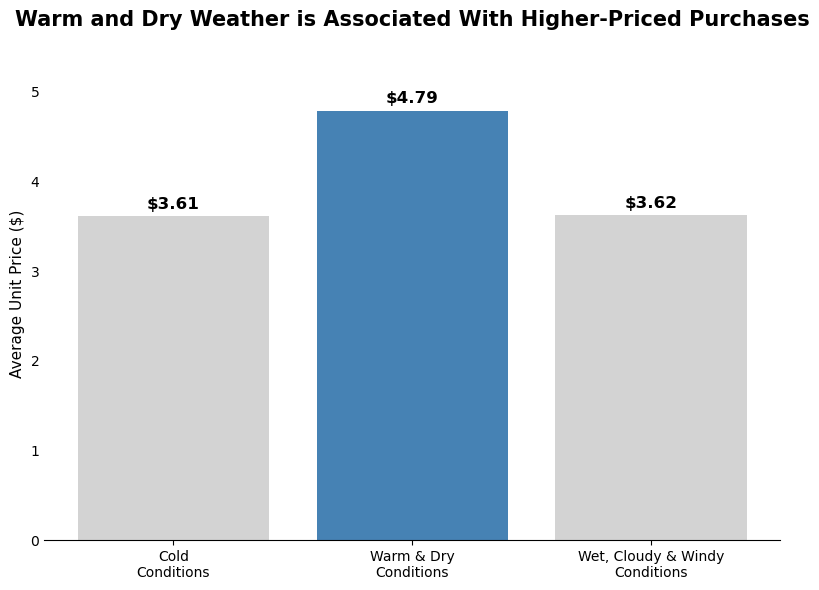

In [ ]:
# Create a figure that displays the weather conditions compared to the average unit price
plt.figure(figsize=(8, 6))

# Plot weather patter by unit price with defined colours
bars = plt.bar(kmedoid_profile["weather_pattern"], kmedoid_profile["unit_price"],
                color=["lightgray", "steelblue", "lightgray"])

# Add unit price values above bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.08,
             f"${bar.get_height():.2f}",ha="center",fontsize=12,fontweight="bold")

plt.title("Warm and Dry Weather is Associated With Higher-Priced Purchases",
            fontsize=15,fontweight="bold",pad=15)
plt.ylabel("Average Unit Price ($)", fontsize=11)
plt.ylim(0, 5.5)

# Hide the axes lines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Hide the y-axis ticks
plt.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

The second insight shows that weather conditions were also associated with differences in the average price of purchased products. Cold conditions had an average unit price of 3.61, closely followed by wet, cloudy, and windy conditions at 3.62.  In comparison, warm and dry conditions had a considerably higher average unit price of \$4.79. Warm and dry conditions have an average temperature of 12.05°C, the lowest rainfall at 0.92 mm, a humidity level of 81.56%, a low cloud cover percentage at 42.30%, and a very low wind speed of 12.17 km/h. The unit price of purchased products during warm, dry conditions is 33% higher than during cold conditions and 32% higher than during wet, cloudy, and windy conditions. Retailers could use this insight to monitor weather conditions so that, when similar warm, dry conditions are forecast, they can increase promotion and visibility for higher-priced products, since customers have purchased higher-priced items under those conditions in the past.

## Insight 3 — Weather conditions may be associated with changes in demand for particular products

This insight shows that weather conditions are also associated with purchasing specific products. The strongest relationship was found for low-temperature and low-rainfall where the product White Hanging Heart T-Light Holder purchase occurred 28% more often than expected if weather and product purchases were unrelated and independent. The second strongest relationships were found for the Regency Cakestand 3 Tier, which occurred 19% more often than expected when the average temperature and rainfall were high. Additionally high average temperature and low rainfall also demonstrated a strong relationship with purchasing  Jumbo Bad Red Retrospot. These findings show that different weather conditions may be associated with changes in demand for particular products, even though the relationships are weaker than product to product associations identified. Retailers could use weather forecasts as an additional tool to identify products that may have changes in demand based on the weather. However, these patterns should be tested more before being used to make direct stocking decisions.

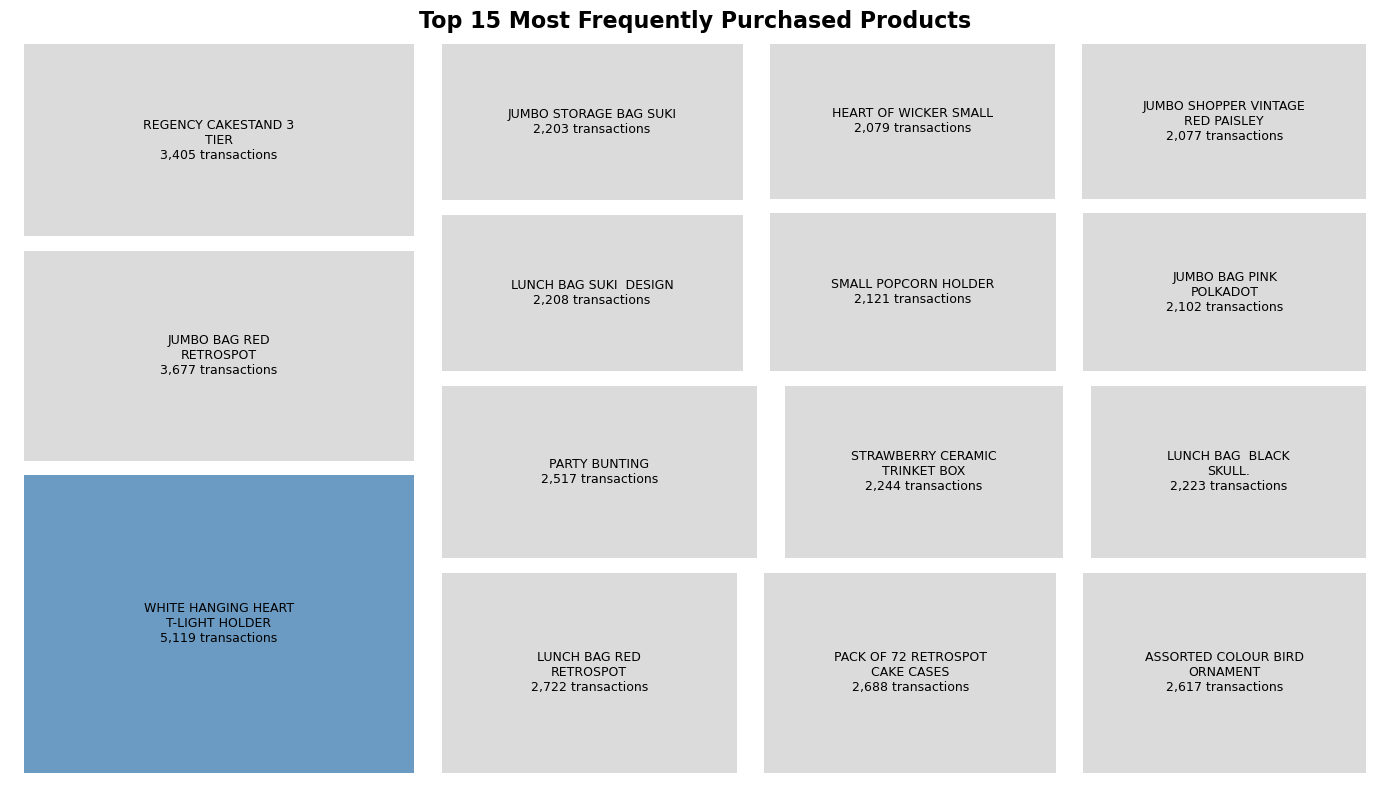

In [ ]:
# Creating tree map visualization:
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

# Calculate product frequency
product_frequency = (df_encoded.filter(regex="^PRODUCT_").sum().sort_values(ascending=False).head(15))

product_labels = []
for product, frequency in product_frequency.items():
    name = product.replace("PRODUCT_", "")
    name = textwrap.fill(name, width=22)
    product_labels.append(f"{name}\n{int(frequency):,} transactions")

# Create the treemap
plt.figure(figsize=(14, 8))

colors = ["steelblue"] + ["lightgray"] * (len(product_frequency) - 1)

squarify.plot(sizes=product_frequency.values, label=product_labels, color=colors, alpha=0.8, pad=True, text_kwargs={"fontsize": 9})


plt.title("Top 15 Most Frequently Purchased Products", fontsize=16,fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

The treemap shows the most frequently purchased products in the transaction dataset. The larger the rectangles, the more number of transactions that the product appears in. The White Hanging Heart T-Light Holder was the most frequently purchased product that appeared in 5,119 transactions. This was followed by the Jumbo Bag Red Retrospot with 3,677 transactions and the Regency Cakestand 3 Tier with 3,405 transactions.

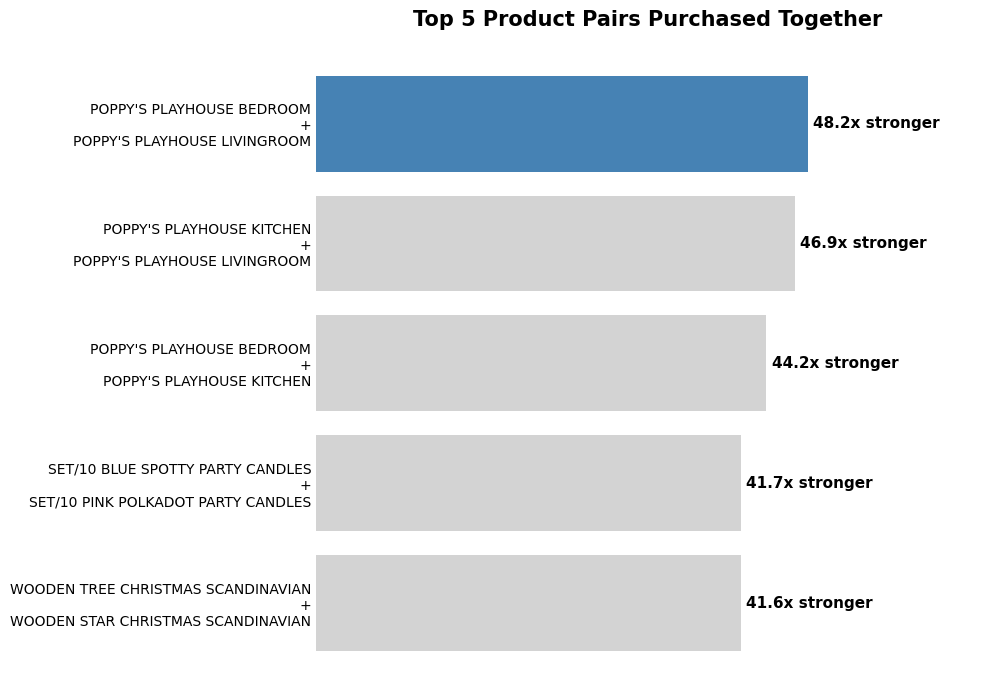

In [ ]:
# Creating additional visualization to show the insight in terms of Product → Product rules
product_pair_viz = interesting_product_rules.copy()

# Create readable product names (because we had added a prefix to read them more easily for association rule mining)
product_pair_viz["Product 1"] = product_pair_viz["antecedents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_", "") for item in x])))
product_pair_viz["Product 2"] = product_pair_viz["consequents"].apply(lambda x: " + ".join(sorted([str(item).replace("PRODUCT_", "") for item in x])))

# Treat reversed rules as the same product relationship and remove duplicates (ecause reversed rules represent the same product pair and have the same lift)
product_pair_viz["Pair"] = product_pair_viz.apply(lambda row: tuple(sorted([row["Product 1"], row["Product 2"]])), axis=1)
product_pair_viz = (product_pair_viz.sort_values(["lift", "confidence"], ascending=False).drop_duplicates(subset="Pair"))

product_pair_viz = product_pair_viz.head(5).copy()

# Create readable labels for bar
product_pair_viz["Label"] = (product_pair_viz["Product 1"] + "\n+\n" + product_pair_viz["Product 2"])

# Sort the product pairs by lift
product_pair_viz = (product_pair_viz.sort_values("lift", ascending=True).reset_index(drop=True))

# Highlight strongest relationship
max_value = product_pair_viz["lift"].max()
colors = ["steelblue" if value == max_value else "lightgray" for value in product_pair_viz["lift"]]

# Create horizontal barchart
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(product_pair_viz["Label"], product_pair_viz["lift"], color=colors)

# Add data labels for each of the bars
for bar, value in zip(bars, product_pair_viz["lift"]):
    ax.text(value + 0.5,bar.get_y() + bar.get_height()/2,f"{value:.1f}x stronger", va="center", fontsize=11, fontweight="bold")

# ax.set_xlabel("Times as Often as Expected", fontsize=11)
# Remove x-axis values
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.set_ylabel("")
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="y", length=0)

ax.set_title("Top 5 Product Pairs Purchased Together",fontsize=15,fontweight="bold",pad=15)

ax.set_xlim(0, max_value * 1.35)

plt.tight_layout()
plt.show()

The association rule analysis also identified strong relationships between products that were frequently purchases together. The strongest relationships were related to Poppy’s Playhouse products with Poppy’s Playhouse Bedroom and Livingroom being the strongest of them all occurring together about 48.2 times as often as expected if two products were being purchased independently. Other products from the Poppy’s Playhouse collection also showed strong relationships, with the Kitchen and Livingroom being bought together 46.9 times as often as expected and the Bedroom and Kitchen products 44.2 times as often as expected. Strong associations were also identified between Scandinavian Christmas decorations. These results show that products that belong to the same collection or those that serve a similar purpose are more likely to have a strong purchasing relationship. Retailers could use these patterns to bundle products, cross-promotion, give product recommendations based on customer’s other purchases, and place the related products together to make them more accessible and discoverable for the customers.


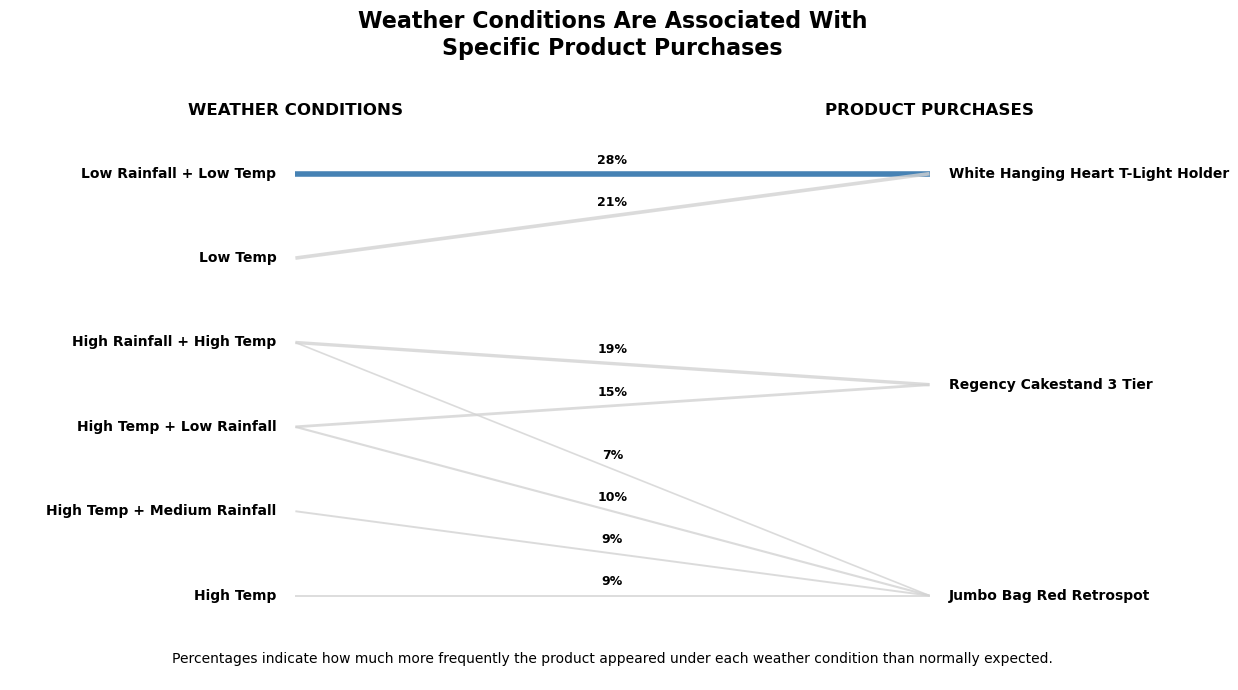

In [ ]:
# Creating visualization for Weather → Product association rules
network_rules = interesting_weather_product_rules.copy()

# Create readable weather condition and product names
network_rules["Weather"] = network_rules["antecedents"].apply(
    lambda x: " + ".join(sorted([
        str(item).replace("TEMP_", "").replace("RAIN_", "").replace("Avg Temp", "Temp")
        for item in x
    ]))
)

network_rules["Product"] = network_rules["consequents"].apply(
    lambda x: " + ".join(sorted([
        str(item).replace("PRODUCT_", "")
        for item in x
    ]))
)

# Keep the strongest rule
network_rules = (network_rules.sort_values(["lift", "confidence"], ascending=False).drop_duplicates(subset=["Weather", "Product"]).head(8).copy())

network_rules["Association (%)"] = (network_rules["lift"] - 1) * 100


# Create graph
G = nx.Graph()

for _, row in network_rules.iterrows():
    G.add_edge(
        row["Weather"],
        row["Product"],
        strength=row["Association (%)"]
    )


weather_nodes = list(network_rules["Weather"].unique())
product_nodes = list(network_rules["Product"].unique())

# Position weather conditions on the left and products on the right
weather_y = np.linspace(len(weather_nodes) - 1, 0, len(weather_nodes))
product_y = np.linspace(len(weather_nodes) - 1, 0, len(product_nodes))

pos = {
    **{node: (0, y) for node, y in zip(weather_nodes, weather_y)},
    **{node: (1, y) for node, y in zip(product_nodes, product_y)}
}


strongest_index = network_rules["Association (%)"].idxmax()

strongest_pair = {network_rules.loc[strongest_index, "Weather"],network_rules.loc[strongest_index, "Product"]}

# Create visualization
fig, ax = plt.subplots(figsize=(13, 7))

# Draw all connections
for u, v in G.edges():

    strength = G[u][v]["strength"]
    is_strongest = {u, v} == strongest_pair

    nx.draw_networkx_edges(G,pos, edgelist=[(u, v)], width=4 if is_strongest else 0.5 + strength / 10, edge_color="steelblue" if is_strongest else "lightgray", alpha=1 if is_strongest else 0.8, ax=ax )


# Add weather condition labels
for node in weather_nodes:
    x, y = pos[node]

    ax.text(x - 0.03, y, node,ha="right",va="center",fontsize=10,fontweight="bold")


# Add product labels
for node in product_nodes:
    x, y = pos[node]

    ax.text(x + 0.03, y, node.title(), ha="left", va="center", fontsize=10, fontweight="bold")


# Add percentage labels to each relationship
for _, row in network_rules.iterrows():
    x1, y1 = pos[row["Weather"]]
    x2, y2 = pos[row["Product"]]

    ax.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2 + 0.12,
        f'{row["Association (%)"]:.0f}%',
        ha="center",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=1
        )
    )


# Add headings and title
ax.text(0, max(weather_y) + 0.7,"WEATHER CONDITIONS", ha="center", fontsize=12, fontweight="bold")
ax.text( 1, max(weather_y) + 0.7, "PRODUCT PURCHASES", ha="center", fontsize=12, fontweight="bold")

ax.set_title( "Weather Conditions Are Associated With\nSpecific Product Purchases", fontsize=16, fontweight="bold", pad=25)

ax.text(0.5, -0.8, "Percentages indicate how much more frequently the product appeared under each weather condition than normally expected.", ha="center", fontsize=10)

# Remove axes and borders
ax.set_xlim(-0.45, 1.45)
ax.set_ylim(-1, max(weather_y) + 1)
ax.axis("off")

plt.tight_layout()
plt.show()

The third insight shows that weather conditions are also associated with purchasing specific products. The strongest relationship was found for low-temperature and low-rainfall where the product White Hanging Heart T-Light Holder purchase occurred 28% more often than expected if weather and product purchases were unrelated and independent. Another strong relationships was found for the Regency Cakestand 3 Tier, which occurred 19% more often than expected when the average temperature and rainfall were high. Additionally high average temperature and low rainfall also demonstrated a strong relationship with purchasing  Jumbo Bad Red Retrospot. These findings show that different weather conditions may be associated with changes in demand for particular products, even though the relationships are weaker than product to product associations identified. Retailers could use weather forecasts as an additional tool to identify products that may have changes in demand based on the weather. However, these patterns should be tested more before being used to make direct stocking decisions.

## Insight 4 — Weather & Timing Alone Do Not Reliably Predict Transaction Sales

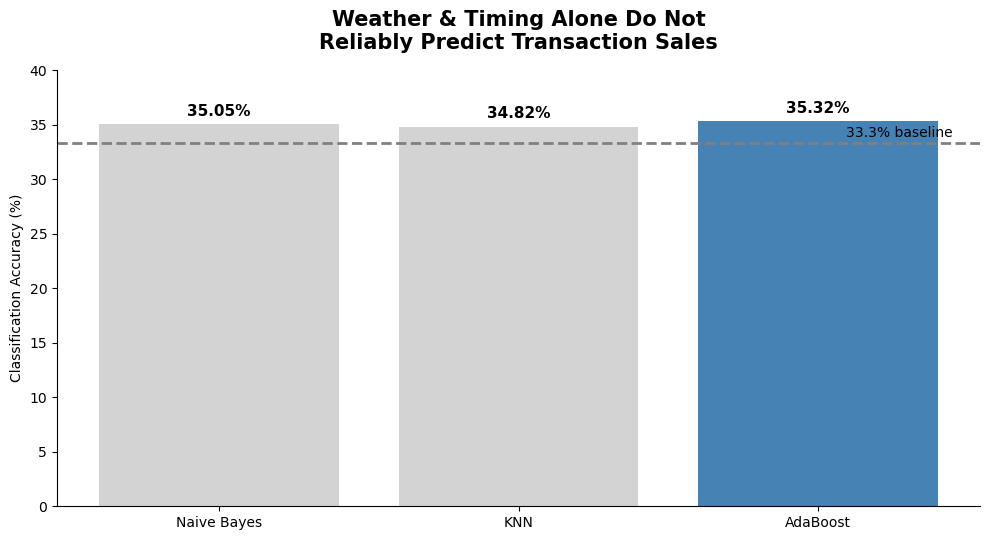

In [ ]:
# Create visualizations for the classification models

# Classification accuracies from the three models
models = ["Naive Bayes", "KNN", "AdaBoost"]
accuracies = [35.05, 34.82, 35.32]

# Baseline accuracy for three approximately balanced classes
baseline = 33.3

# Highlight the best-performing model
colors = ["lightgray","lightgray","steelblue"]

# Create baarchart
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(models,accuracies,color=colors)

for bar, value in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.axhline(baseline,linestyle="--",linewidth=2,color="gray")

ax.text(2.45,baseline + 0.3, "33.3% baseline",ha="right", va="bottom", fontsize=10)

ax.set_ylabel("Classification Accuracy (%)")
ax.set_xlabel("")
ax.set_title("Weather & Timing Alone Do Not\nReliably Predict Transaction Sales", fontsize=15, fontweight="bold", pad=15)
ax.set_ylim(0, 40)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

The fourth insight shows that weather and temporal characteristics alone are not enough to reliably predict whether a transaction will have low, medium or high sales. The three classification models, Naïve Baye, KNN, and AdaBoost, produced very close results. Naïve Baye achieved 35.05% accuracy, K-Nearest Neighbour 34.82% and AdaBoost 35.32%. Since the tree transactional sales categories contain approximately equal number of transactions, a simple baseline is about 33.33%. However, as can be seen, even the highest performing model, AdaBoost, only improved about two percent over the baseline in terms of accuracy. This shows that even though weather is associated with some aspects of purchasing patterns, it alone does not provide enough information to reliably predict transaction sales levels. Same as the previous insight, retailers should use weather as an additional information along with other more important information such as product characteristics, promotions, seasons, and holidays.

# Limitations & Next Steps

The findings of this analysis represent associations rather than causational relationships. This means that the results cannot show that weather directly caused the observed differences in purchasing behaviour. Customer purchasing decisions may be influenced by factors that are not represented and available in the datasets used in this analysis. These can be factors such as promotions, holidays, product availability, and customer characteristics. Additionally, the clustering results showed considerable overlap between clusters which means that there was some similarity between the weather and purchasing characteristics. However, the classification models achieved about 35% accuracy, which is just a little above the baseline. This indicates that weather and temporal characteristics alone are not enough to reliably predict transaction sales.
Future analysis could include additional variables such as promotions, holidays, seasonality, product categories, and customer features in order to determine whether combining these factors with weather improves predictive performance or not. Further analysis could also look into which product categories experience the highest demand under various weather conditions.  The inventory, promotional, and cross-selling strategies that were identified during this analysis should be tested on a small scale in the retail stores and get evaluated before a broader implementation.
